# TASS 2018: representación textual, rasgos léxicos y selección de clasificador

**Miguel Gerardo Moreno y Juan David Tejedor Medina · Procesamiento de Lenguaje Natural**

Este cuadernillo continúa `tass_Word2Vec_skipgrama_MiguelM_JuanT (1)(5).ipynb`, cuya ejecución archivada obtuvo **F1 macro 0,3022** y accuracy 0,4209 sobre 506 tuits. Sigue las cinco fases del enunciado, incorpora el módulo léxico documentado del grupo y conserva la comparación con Word2Vec Skip-gram. El código está preparado para ejecutarse de arriba abajo con los archivos reales de TASS; **las celdas nuevas no presentan métricas inventadas ni resultados de una ejecución que no se ha realizado**.

**Datos:** `data/tass/tass2018_es_train.csv` (1008) y `data/tass/tass2018_es_test.csv` (506). El segundo archivo corresponde al conjunto de *desarrollo* de InterTASS-ES; la prueba oficial del overview contiene 1899 tuits diferentes. Aquí llamamos `dev` al archivo de 506, y se evalúa una sola vez al final. Para comparar con una versión nueva sobre los mismos 506 tuits se puede usar 0,3022 como referencia histórica, con la salvedad de que el procedimiento antiguo fue transductivo y su validación cruzada filtraba información.

**Orden:** fase 0 auditoría → fase 1 características nuevas → fase 2 representaciones → fase 3 selección solo con train → fase 4 única evaluación en dev y análisis. No se crea corpus sintético ni se inspeccionan etiquetas de dev para ajustar hiperparámetros. El artículo oficial se discute como contexto, no como una comparación equivalente de conjuntos.

Fuentes del grupo: notebook Word2Vec `(1)(5)` y `01_Modulo_caracteristicas_documentado.ipynb` (se incorporan sus definiciones, incluidas las listas y ML-SentiCon). Fuente oficial: [Martínez-Cámara et al., Overview of TASS 2018, CEUR-WS 2172](https://ceur-ws.org/Vol-2172/p0_overview_tass2018.pdf), tablas 1 y 4.

## Configuración y carga del corpus

Dependencias: `numpy pandas scipy scikit-learn matplotlib nltk gensim`. Para instalar en el entorno del notebook: `python -m pip install numpy pandas scipy scikit-learn matplotlib nltk gensim`. No hace falta descargar recursos NLTK. El módulo léxico está incluido abajo para que el notebook sea autónomo. Ajuste `DATA_DIR` si sus CSV están en otro directorio. El código comprueba ambos archivos y las etiquetas, y se detiene con un mensaje claro si faltan. `gensim` se usa para conservar el experimento Word2Vec y debe estar instalado antes de ejecutar la fase 2.

In [3]:
from pathlib import Path
from collections import Counter
from IPython.display import display
import re, sys, unicodedata, warnings, platform, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
from scipy import sparse
from nltk import TweetTokenizer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
LABELS = ['N', 'NEU', 'NONE', 'P']
DATA_DIR = Path('data/tass')
COL_TEXT, COL_LABEL = 'content', 'sentiment/polarity/value'
np.random.seed(SEED)
print('Python', platform.python_version())

Python 3.12.14


In [4]:
train_path = DATA_DIR / 'tass2018_es_train.csv'
dev_path = DATA_DIR / 'tass2018_es_test.csv'
missing = [str(p) for p in (train_path, dev_path) if not p.is_file()]
if missing:
    raise FileNotFoundError(f'Faltan CSV reales: {missing}. Cambie DATA_DIR; no se generan datos ficticios.')
train_df = pd.read_csv(train_path)
dev_df = pd.read_csv(dev_path)
for name, frame in [('train', train_df), ('dev', dev_df)]:
    absent = {COL_TEXT, COL_LABEL} - set(frame.columns)
    if absent:
        raise ValueError(f'{name}: faltan columnas {absent}')
    if frame[[COL_TEXT, COL_LABEL]].isna().any().any():
        raise ValueError(f'{name}: hay textos o etiquetas nulos; revisar antes de modificar el corpus')
    invalid = set(frame[COL_LABEL].astype(str)) - set(LABELS)
    if invalid:
        raise ValueError(f'{name}: etiquetas no esperadas: {invalid}')
if 'tweetid' in train_df and 'tweetid' in dev_df:
    overlap = set(train_df.tweetid.astype(str)) & set(dev_df.tweetid.astype(str))
    if overlap:
        raise ValueError(f'IDs compartidos entre train y dev: {len(overlap)}')
X_train = train_df[COL_TEXT].astype(str).to_numpy()
y_train = train_df[COL_LABEL].astype(str).to_numpy()
# Mantener los 506 textos de desarrollo intactos hasta la evaluación final.
assert len(X_train) == 1008 and len(dev_df) == 506, 'Partición distinta a la línea base archivada'
print('Train:', len(train_df), 'Dev reservado:', len(dev_df))
display(train_df[COL_LABEL].value_counts().reindex(LABELS).to_frame('train'))

Train: 1008 Dev reservado: 506


,train
sentiment/polarity/value,
N,418
NEU,133
NONE,139
P,318


## Fase 0 — Auditoría de características existentes

Se reutilizan las **29 características históricas** de `get_features_lexical` y las **15 características añadidas** y documentadas por el grupo. Las marcas de emoji, URL, mención y hashtag deben extraerse del tuit crudo; si se calculan después de eliminar esas marcas, se vuelven cero. La auditoría mide constancia, correlación con la longitud y pérdida de activación al limpiar. Las cuatro columnas declaradas en `EXCLUDED_LEXICAL_FEATURES` se describen, pero se excluyen del clasificador por ser proxies de longitud o redundantes. Se mantienen valores con signo donde una polaridad negativa lleva información; nunca se usa `abs()` sobre ellos.

### Listas y expresiones del módulo léxico existente

In [7]:
lexical_es = {'first_person_singular': ['yo', 'mio', 'mi'],
              'second_person_singular': ['tú', 'tu', 'tuyo', 'usted', 'vos'],
              'third_person_singular': ['él', 'el', 'ella', 'ese', 'esa', 'aquel'],
              'first_person_plurar': ['nosotros', 'nuestros'],
              'second_person_plurar': ['tuyos', 'tuyas', 'ustedes', 'vosotros', 'vosotras'],
              'third_person_plurar': ['ellos', 'ellas', 'ese', 'esos', 'aquellas', 'aquellos'],
              'adverb_time': ['ya', 'aún', 'hoy', 'tarde', 'pronto', 'todavía', 'ayer', 'recién', 'nunca', 'siempre',
                              'jamás', 'ahora'],
              'adverb_neg': ['tampoco', 'no', 'en absoluto', 'nunca'],
              'adverb_place': ['ahí', 'allí', 'aquí', 'acá', 'delante', 'detrás', 'arriba', 'abajo', 'cerca', 'lejos',
                               'encima', 'fuera', 'dentro'],
              'adverb_mode': ['mal', 'bien', 'regular', 'despacio', 'así', 'mejor', 'peor', 'claro', 'similar',
                              'fácilmente'],
              'adverb_cant': ['muy', 'más', 'poco', 'bastante', 'bastante', 'menos', 'mucho', 'algo', 'casi'],
              'adjetives_neg': ['aburrido', 'ácido', 'amargo', 'ancho', 'atrevido', 'bajo', 'blando', 'caliente',
                                'común', 'conocido', 'corto', 'débil', 'delgado', 'diferente', 'difícil', 'duro',
                                'enfermo', 'estrecho', 'falso', 'feo', 'frío', 'húmedo', 'imposible', 'izquierdo',
                                'lento', 'malo', 'menor', 'muerto', 'negro', 'peor', 'pequeño', 'pobre', 'poco',
                                'popular', 'raro', 'rojo', 'salado', 'simple', 'sinvergüenza', 'solo', 'soso',
                                'tímido', 'tonto', 'triste', 'viejo'],
              'adjetives_pos': ['alegre', 'alto', 'azul', 'blanco', 'bonito', 'buen', 'bueno', 'caliente', 'capaz',
                                'central', 'contento', 'derecho', 'diferente', 'divertido', 'dulce', 'duro', 'exterior',
                                'famoso', 'final', 'fresco', 'fuerte', 'gran', 'grande', 'guapo', 'guay', 'igual',
                                'imposible', 'interesante', 'joven', 'largo', 'listo', 'mayor', 'mejor', 'mucho',
                                'musical', 'nacional', 'natural', 'nuevo', 'perfecto', 'popular', 'posible',
                                'primer', 'primero', 'principal', 'próximo', 'rápido', 'real', 'recto', 'rico',
                                'salado', 'sano', 'seco', 'útil', 'verdadero', 'verde', 'vivo'],
              'who_general': ['familia', 'familiar', 'familiares', 'acompañante', 'aprendices', 'aprendiz', 'artista',
                              'asistente', 'compinche', 'directiva', 'directivo', 'especialista', 'estudiante',
                              'estudiantes', 'joven', 'jovenes', 'lider', 'pareja', 'projimo'],
              'who_male': ['abuelo', 'alcalde', 'medico', 'alumno', 'alumnos', 'amigo', 'amigos', 'asesor', 'chiquillo',
                           'compa', 'compadre', 'compañero', 'compañeros', 'decano', 'director', 'doctor', 'empleado',
                           'empresario', 'entrenador', 'esposo', 'esposito', 'experto', 'expertos', 'funcionario',
                           'hermano', 'ingeniero', 'investigador', 'jefe', 'jugador', 'padre', 'marido', 'medico',
                           'muchacho', 'muchachos', 'niño', 'niños', 'novio', 'hijo', 'primo', 'papa', 'pequeños',
                           'profesor', 'pequeño', 'secretario', 'socio', 'tutor', 'papi', 'tio', 'nieto'],
              'who_female': ['alumna', 'alumnas', 'amiga', 'amigas', 'asesora', 'chiquilla', 'comadre', 'compañera',
                             'compañeras', 'dama', 'decana', 'directora', 'doctora', 'empleada', 'empresaria', 'esposa',
                             'esposita', 'experta', 'expertas', 'funcionaria', 'hermana', 'ingeniera', 'investigadora',
                             'jefa', 'jugadora', 'madre', 'mama', 'medica', 'muchacha', 'muchachas', 'mujer', 'niñas',
                             'novia', 'novicia', 'hija', 'prima', 'pequeña', 'pequeñas', 'profesora', 'secretaria',
                             'señora', 'socia', 'tutora', 'mami', 'tia', 'nieta'],
              'hate': ['animosidad', 'antagonismo', 'enemistad', 'odio', 'horror', 'hostilidad', 'aborrecimiento',
                       'dolor', 'rencor', 'resentimiento', 'venganza', 'veneno', 'aborrecimiento', 'abominación ',
                       'anatema', 'animus', 'antipatía', 'aversión', 'molestar', 'bugbear', 'detestación ', 'disgusto',
                       'execración', 'escarcha', 'agravio', 'queja', 'irritante', 'malevolencia', 'malignidad',
                       'molestia', 'objeción', 'odio', 'irritación', 'repugnancia', 'repulsión', 'repulsión',
                       'desprecio', 'despecho', 'problemas', 'bestia negra', 'mala voluntad', 'desagradable',
                       'mirada desagradable', 'ningún amor perdido'],
              # --- Caracteristicas nuevas (Sebastian Sarmiento) ---
              # emoji_pol: signo de polaridad del emoji segun Emoji Sentiment Ranking (Kralj Novak et al., 2015)
              'emoji_pos': ['😂', '🤣', '😀', '😃', '😄', '😁', '😊', '😍', '😘', '😙', '😜', '😉', '😎', '🥰',
                            '❤', '♥', '💚', '💙', '💜', '❣', '💞', '💕', '👍', '👌', '👏', '🙌', '🎉', '✨',
                            '🌟', '💪', '🙏', '💃'],
              'emoji_neg': ['😢', '😭', '😞', '😔', '😒', '😩', '😫', '😠', '😡', '🤬', '💔', '👎', '😱', '😤',
                            '😣', '😖', '🙄'],
              # laugh_count: risas escritas que no siguen el patron ja/je/ji
              'laugh': ['xd', 'lol', 'lmao', 'jsjs', 'jsjsjs', '🤣'],
              # lex_pol_neg: marcas que invierten la polaridad y conjunciones que cierran su alcance
              'negation': ['no', 'nunca', 'jamás', 'jamas', 'tampoco', 'ni', 'nada', 'nadie', 'sin'],
              'adversative': ['pero', 'aunque', 'sino'],
              # --- Caracteristicas nuevas (Miguel M. y Juan T.) ---
              # Se separan intensificadores y atenuadores: adverb_cant los mezclaba en un solo conteo.
              'intensifier': ['muy', 'muchísimo', 'muchisimo', 'demasiado', 'tan', 'súper', 'super',
                              'totalmente', 'extremadamente', 'realmente', 'bastante', 'mega'],
              'attenuator': ['algo', 'poco', 'apenas', 'casi', 'quizá', 'quizas', 'quizás', 'medio'],
              # Formas breves que expresan reacción o estado afectivo del hablante.
              'interjection': ['ay', 'uy', 'uf', 'uff', 'oh', 'eh', 'wow', 'buah', 'bah', 'hala', 'vaya', 'jo'],
              # Léxico informal frecuente en variedades peninsulares presentes en TASS.
              'colloquial': ['joder', 'tío', 'tio', 'hostia', 'puto', 'puta', 'mierda', 'coño', 'guay',
                             'chaval', 'chavala', 'currar', 'mola', 'molar', 'majo', 'maja', 'tronco']}

lexical_en = {'first_person_singular': ['i', 'me', 'my', 'mine', 'myself'],
              'second_person_singular': ['you', 'your', 'yours', 'yourself'],
              'third_person_singular': ['he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its',
                                        'itself'],
              'first_person_plurar': ['we', 'us', 'our', 'ours', 'ourselves'],
              'second_person_plurar': ['you', 'your', 'yours', 'yourself'],
              'third_person_plurar': ['they', 'them', 'their', 'theirs', 'themselves'],
              'adverb_time': ['now', 'then', 'today', 'tomorrow', 'tonight', 'yesterday', 'annually', 'daily',
                              'fortnightly', 'hourly', 'monthly', 'nightly', 'quarterly', 'weekly', 'yearly', 'always',
                              'constantly', 'ever', 'frequently', 'generally', 'infrequently', 'never', 'normally',
                              'occasionally', 'often', 'rarely', 'regularly', 'seldom', 'sometimes', 'regularly',
                              'usually', 'already', 'before', 'early', 'earlier', 'eventually', 'finally', 'first',
                              'formerly', 'just', 'last', 'late', 'later', 'lately', 'next', 'previously', 'recently',
                              'since', 'soon', 'still', 'yet'],
              'adverb_neg': ['no', 'not', 'angrily', 'anxiously', 'badly', 'boastfully', 'foolishly', 'hopelessly',
                             'irritably', 'jealously', 'lazily', 'obnoxiously', 'poorly', 'rudely', 'selfishly',
                             'wearily'],
              'adverb_place': ['about', 'above', 'abroad', 'anywhere', 'away', 'back', 'backwards', 'backward', 'behind',
                               'below', 'down', 'downstairs', 'east', 'elsewhere', 'far', 'here', 'in', 'indoors',
                               'inside', 'near', 'nearby', 'off', 'on', 'out', 'outside', 'over', 'there', 'towards',
                               'under', 'up', 'upstairs', 'where'],
              'adverb_mode': ['angrily', 'anxiously', 'awkwardly', 'badly', 'beautifully','calmly', 'carefully',
                              'carelessly', 'cautiously', 'cheerfully', 'clearly', 'closely', 'correctly',
                              'deliberately'],
              'adverb_cant': ['a few', 'a little', 'a lot of', 'almost', 'enough', 'entirely', 'even', 'failry',
                              'hardly', 'lots', 'less', 'many', 'much', 'partially', 'pretty', 'rather', 'quite',
                              'scarcely', 'so', 'too', 'very', 'way'],
              'adjetives_neg': ['aggressive', 'arrogant', 'boastful', 'bossy', 'boring', 'careless', 'clingy', 'cruel',
                                'cowardly', 'deceitful', 'dishonest', 'fussy', 'greedy', 'grumpy', 'harsh', 'impatient',
                                'impulsive', 'jealous', 'moody', 'narrow-minded', 'overcritical', 'rude', 'selfish',
                                'untrustworthy', 'unhappy', 'aloof', 'armchair', 'critic', 'big-headed', 'busy body',
                                'couch potato', 'cynical', 'full of hot air', 'goody-goody', 'goody two shoes',
                                'grumpy', 'impulsive', 'indecisive', 'know it all', 'materialistic', 'obnoxious',
                                'pain in the neck', 'picky', 'set in one’s ways', 'tactless', 'thoughtless',
                                'wet blanket', 'party pooper', 'spoilsport', 'killjoy','stick-in-the-mud'],
              'adjetives_pos': ['able', 'abundant', 'aboveboard', 'acceptable', 'accurate', 'achieving', 'affordable',
                                'adaptable', 'ambitious', 'calculated', 'captivated', 'careful', 'casual', 'calm',
                                'capable', 'certain', 'charming', 'cheerful', 'cheery', 'cherished', 'chic', 'civil',
                                'clean', 'comfortable', 'cooperative', 'cordial', 'crafty', 'cute', 'clever', 'natural',
                                'naturalistic', 'neutral', 'newborn', 'needed', 'neat', 'necessary', 'new', 'nifty',
                                'nice', 'nontoxic', 'notable', 'nourishing', 'novel', 'nurturant', 'tactful',
                                'talented', 'tasty', 'taxing', 'teachable', 'thankful', 'thoughtful', 'through',
                                'thrifty', 'thrilled', 'thriving', 'timeless', 'tolerant', 'top-notch', 'touching',
                                'twinkly', 'terrific', 'truthful', 'trusting', 'trustworthy', 'trusted', 'tremendous',
                                'treasured', 'tranquil', 'tidy', 'tantalizing', 'toned', 'tricky', 'tasteful',
                                'triumphant', 'perfect', 'reasonable', 'luxurious', 'kind-hearted', 'justified',
                                'wonderful', 'heroic', 'glamorous', 'forgiving', 'expressive', 'valuable', 'dapper',
                                'stunning', 'beloved', 'dazzled', 'excellent', 'flashy', 'healing', 'legit',
                                'optimistic', 'peaceful', 'romantic', 'loving', 'faithful', 'soothing'],
              'who_general': ['family', 'familiar', 'relatives', 'companion', 'apprentice', 'artist', 'assistant',
                              'buddy', 'director', 'manager', 'specialist', 'student', 'youth', 'young', 'leader',
                              'partner', 'neighbor', 'accountant', 'actor', 'actress', 'architect', 'astronomer',
                              'author', 'baker', 'bricklayer', 'bus driver', 'butcher', 'carpenter', 'chef', 'cook',
                              'cleaner', 'dentist', 'designer', 'doctor', 'dustman', 'refuse collector', 'electrician',
                              'engineer', 'factory', 'farmer', 'fireman', 'fire', 'fisherman', 'florist', 'gardener',
                              'hairdresser', 'journalist', 'judge', 'lawyer', 'lecturer', 'librarian', 'lifeguard',
                              'mechanic', 'model', 'newsreader', 'nurse', 'optician', 'painter', 'pharmacist',
                              'photographer', 'pilot', 'plumber', 'politician', 'policeman', 'policewoman', 'postman',
                              'real', 'receptionist', 'scientist', 'secretary', 'shop', 'soldier', 'tailor', 'taxi',
                              'teacher', 'translator', 'traffic warden', 'travel agent', 'veterinary doctor', 'waiter',
                              'waitress', 'window cleaner'],
              'who_male': ['grandfather', 'mayor', 'doctor', 'pupil', 'pupils', 'friend', 'friends', 'advisor', 'child',
                           'buddy', 'companion', 'colleagues', 'dean', 'director', 'doctor', 'employee', 'entrepreneur',
                           'coach', 'husband', 'expert', 'experts', 'officer', 'brother', 'engineer', 'researcher',
                           'boss', 'player', 'father', 'doctor', 'boy', 'boys', 'child', 'children', 'boyfriend', 'son',
                           'cousin', 'dad', 'kids', 'teacher', 'kid', 'secretary', 'partner', 'tutor', 'daddy', 'uncle',
                           'grandchild'],
              'who_female': ['advisor', 'child', 'mother', 'companion', 'companion', 'lady', 'dean', 'director',
                             'doctor', 'employee', 'entrepreneur', 'wife', 'expert', 'officer', 'sister', 'engineer',
                             'researcher', 'boss', 'player', 'mother', 'mother', 'doctor', 'girl', 'girls', 'woman',
                             'girls', 'bride', 'novice', 'daughter', 'cousin', 'little', 'little', 'teacher',
                             'secretary', 'lady', 'partner', 'tutor', 'mommy', 'aunt', 'granddaughter'],
              'hate': ['animosity', 'antagonism', 'enmity', 'hatred', 'horror', 'hostility', 'loathing', 'pain',
                       'rancor', 'resentment', 'revenge', 'venom', 'abhorrence', 'abomination', 'anathema', 'animus',
                       'antipathy', 'aversion', 'bother', 'bugbear', 'detestation', 'disgust', 'execration', 'frost',
                       'grievance', 'gripe', 'irritant', 'malevolence', 'malignity', 'nuisance', 'objection', 'odium',
                       'rankling', 'repugnance', 'repulsion','revulsion', 'scorn', 'spite', 'trouble', 'black beast',
                       'bête noire', 'ill will', 'mislike', 'nasty look', 'no love lost']}

### Recurso ML-SentiCon incorporado en el módulo

In [9]:
# ML-SentiCon completo utilizado en la extracción: lema -> polaridad.
SENTICON = {'abad': 0.375,
 'abadesa': 0.375,
 'abalanzar': -0.375,
 'abanderar': 0.375,
 'abandonado': 0.25,
 'abarrotado': 0.25,
 'abasia': -0.375,
 'abastecedor': 0.25,
 'abatible': 0.375,
 'abatida': 0.25,
 'abatido': -0.312,
 'abatimiento': -0.375,
 'abatir': -0.554,
 'abatis': 0.25,
 'abdicable': 0.375,
 'abducir': -0.25,
 'abejarrón': 0.25,
 'abejón': 0.25,
 'abenuz': -0.375,
 'aberrante': -0.25,
 'abetalipoproteinemia': -0.625,
 'abierta': -0.25,
 'abilidad': 0.313,
 'ablandabrevas': -0.5,
 'ablandado': 0.375,
 'ablandante': 0.25,
 'abochornado': -0.25,
 'abochornar': -0.5,
 'abogaducho': -0.25,
 'abombar': -0.5,
 'abominable': -0.375,
 'abominación': -0.425,
 'abominador': -0.375,
 'abominar': -0.375,
 'abonado': 0.375,
 'abonamiento': 0.375,
 'abordabilidad': -0.5,
 'abordable': 0.75,
 'aborrecedor': -0.375,
 'aborrecer': -0.625,
 'aborrecible': -0.25,
 'aborrecimiento': -0.425,
 'abortivo': 0.25,
 'abotonar': 0.375,
 'abracadabra': 0.25,
 'abrasador': -0.25,
 'abrasividad': -0.25,
 'abrevadero': 0.25,
 'abrigadero': -0.25,
 'abroncar': -0.5,
 'abrumar': -0.361,
 'absentista': -0.312,
 'absolutista': -0.25,
 'absolvedor': 0.25,
 'absolver': -0.25,
 'absorbible': 0.375,
 'absorto': 0.5,
 'abstemio': 0.375,
 'absuelto': 0.375,
 'abuchear': -0.458,
 'abucheo': -0.417,
 'abultar': -0.25,
 'abundante': 0.589,
 'abundoso': 0.5,
 'aburrido': -0.25,
 'aburrir': -0.5,
 'aburrirse': 0.25,
 'abusado': -0.25,
 'abusador': -0.375,
 'abusar': -0.333,
 'abusión': -0.5,
 'abuso': -0.417,
 'abusón': -0.375,
 'abyección': -0.25,
 'abásico': -0.25,
 'abúlico': -0.75,
 'acallamiento': 0.375,
 'acalorado': 0.25,
 'acalorar': -0.5,
 'acalorarse': -0.25,
 'acantión': 0.25,
 'acantonar': 0.25,
 'acaparador': 0.25,
 'acatar': 0.375,
 'acatexia': -0.25,
 'acaudalado': 0.5,
 'acaudalar': 1.0,
 'acaudillar': -0.375,
 'acceleración': 0.25,
 'accesibilidad': 0.417,
 'accesible': 0.607,
 'accesional': 0.25,
 'accidente': -0.25,
 'accionador': 0.25,
 'acecinado': 0.25,
 'aceite': -0.25,
 'aceitunado': 0.375,
 'acelerado': 0.5,
 'aceptabilidad': 0.688,
 'aceptable': 0.688,
 'aceptador': 0.5,
 'acertado': 0.708,
 'acetaminofeno': -0.25,
 'acetificar': 0.25,
 'acetoso': -0.562,
 'acherontia': -0.375,
 'achicarse': -0.375,
 'achicharrarse': -0.312,
 'achispado': 0.375,
 'aciago': -0.5,
 'acibarar': -0.375,
 'acicalado': 0.5,
 'acicalar': 0.25,
 'acidia': -0.375,
 'acidular': 0.25,
 'acierto': 0.375,
 'acinesia': -0.375,
 'acinesis': -0.375,
 'aclamación': 0.5,
 'aclamador': 0.25,
 'aclorhidria': -0.25,
 'aclorhídrico': -0.25,
 'acobardado': -0.25,
 'acogedor': 0.775,
 'acolchado': 0.25,
 'acolchamiento': 0.25,
 'acometer': -0.25,
 'acomodación': 0.292,
 'acomodado': 0.563,
 'acomodar': 0.469,
 'acomodaticio': 0.5,
 'acompasado': 0.625,
 'acompañante': 0.375,
 'acondrita': -0.25,
 'acondroplasia': -0.375,
 'acondroplástico': -0.25,
 'acongojado': -0.75,
 'acongojarse': -0.687,
 'aconsejable': 0.625,
 'aconsejado': 0.5,
 'acoplado': 0.375,
 'acoquinado': -0.5,
 'acorazado': 0.313,
 'acorazonado': 0.375,
 'acordado': 0.375,
 'acordarse': 0.438,
 'acorralado': -0.25,
 'acortarse': -0.25,
 'acosado': -0.25,
 'acosar': -0.304,
 'acoso': -0.5,
 'acostumbrado': 0.333,
 'acracia': -0.5,
 'acre': -0.3,
 'acreditado': 0.667,
 'acrilamida': -0.25,
 'acriminación': -0.625,
 'acriminador': -0.25,
 'acristalado': 0.375,
 'acroanestesia': -0.25,
 'acrobático': 0.25,
 'acrofobia': -0.25,
 'acrofóbico': -0.25,
 'acromatínico': 0.25,
 'acromegalia': -0.375,
 'acromático': -0.375,
 'acrídidos': 0.25,
 'actinomicótico': -0.25,
 'activa': 0.25,
 'activado': 0.292,
 'activador': 0.25,
 'actividad': 0.25,
 'activista': 0.375,
 'activo': 0.26,
 'actuado': 0.375,
 'actualizado': 0.5,
 'acuafobia': -0.375,
 'acuartelar': 0.25,
 'acufeno': -0.25,
 'acullá': 0.375,
 'acuminado': 0.25,
 'acumulativo': 0.375,
 'acusación': -0.25,
 'acusador': -0.25,
 'acústicamente': 0.375,
 'adamantino': -0.375,
 'adaptabilidad': 0.313,
 'adaptable': 0.313,
 'adaptado': 0.5,
 'adaptador': 0.25,
 'adaptar': 0.3,
 'adecuación': 0.5,
 'adecuada': 0.75,
 'adecuadamente': 0.25,
 'adecuado': 0.656,
 'adecuar': 0.281,
 'adefesio': -0.312,
 'adelanto': 0.25,
 'adenomiosis': -0.375,
 'adenopatía': -0.375,
 'aderezar': 0.313,
 'adherente': 0.375,
 'adhesivo': 0.25,
 'adiestrado': 0.375,
 'adiestrador': 0.25,
 'adiestrar': 0.375,
 'adinamia': -0.875,
 'adinerado': 0.5,
 'adiposo': -0.5,
 'aditivo': 0.25,
 'adivinanza': -0.375,
 'administrable': 0.625,
 'admirabilidad': 0.625,
 'admirable': 0.906,
 'admirablemente': 0.625,
 'admiración': 0.45,
 'admirar': 0.75,
 'admisibilidad': 0.5,
 'admisible': 0.625,
 'admisivo': 0.5,
 'admitido': 0.25,
 'adopción': 0.25,
 'adoptable': 0.75,
 'adorable': 0.5,
 'adorado': 0.5,
 'adorador': 0.5,
 'adormecimiento': 0.25,
 'adormilarse': -0.25,
 'adormitarse': -0.25,
 'adornado': 0.625,
 'adoxografía': 0.375,
 'adquirible': 0.375,
 'adquirido': -0.25,
 'adrenalina': 0.25,
 'adrenocorticotrópico': 0.5,
 'adsorbato': 0.25,
 'adsorbible': 0.25,
 'adulterar': -0.562,
 'adulterino': -1.0,
 'adulto': 0.375,
 'adustez': -0.5,
 'adusto': -0.312,
 'adversidad': -0.475,
 'adverso': -0.375,
 'advertencia': -0.344,
 'advice': 0.25,
 'adyacente': 0.25,
 'aerobio': 0.313,
 'aeroembolismo': -0.25,
 'aerotransportado': 0.375,
 'aerófilo': 0.25,
 'aestesis': -0.25,
 'aethusa': -0.25,
 'afabilidad': 0.583,
 'afable': 1.0,
 'afanar': -0.687,
 'afear': -0.333,
 'afectividad': 0.625,
 'afectivo': 0.375,
 'afecto': 0.321,
 'afectuosamente': 0.625,
 'afectuosidad': 0.375,
 'afectuoso': 0.563,
 'afeminado': 0.313,
 'aferente': -0.25,
 'affenpinscher': -0.25,
 'afianzarse': 0.25,
 'aficionado': -0.25,
 'aficionarse': 0.375,
 'afición': 0.5,
 'afilado': 0.375,
 'afiladora': 0.25,
 'afiliado': 0.25,
 'afinación': 0.25,
 'afinamiento': 0.25,
 'afinar': 0.304,
 'afirmativo': 0.75,
 'aflautado': 0.25,
 'aflicción': -0.606,
 'afligido': -0.396,
 'afligir': -0.675,
 'afligirse': -0.687,
 'afluencia': 0.375,
 'afonía': -0.292,
 'afortunadamente': 0.875,
 'afortunado': 0.813,
 'aforístico': 0.25,
 'afrenta': -0.25,
 'afrentar': -0.437,
 'africada': 0.25,
 'afrontar': -0.406,
 'afrutado': 0.25,
 'afta': -0.25,
 'afótico': -0.375,
 'agarico': -0.25,
 'agarrado': -0.875,
 'agasajar': 0.333,
 'agentes': -0.5,
 'agil': 0.375,
 'agilidad': 0.25,
 'agitprop': -0.25,
 'agobiante': -0.312,
 'agobiar': -0.594,
 'agobio': -0.625,
 'agonizar': -0.75,
 'agonía': -0.625,
 'agorafobia': -0.25,
 'agorafóbico': -0.25,
 'agorero': -0.687,
 'agotable': 0.375,
 'agradable': 0.75,
 'agradado': 0.75,
 'agradar': 0.708,
 'agradecido': 0.5,
 'agrado': 0.625,
 'agrandado': -0.312,
 'agrandar': 0.25,
 'agranulocítico': -0.5,
 'agravado': -0.375,
 'agravamiento': -0.417,
 'agravar': -0.281,
 'agravarse': -0.375,
 'agrazón': -0.292,
 'agreder': -0.375,
 'agregado': 0.458,
 'agresividad': -0.35,
 'agresivo': -0.375,
 'agresión': -0.312,
 'agreste': -0.25,
 'agridulce': -0.562,
 'agrio': -0.425,
 'agrisado': -0.25,
 'agrisar': -0.25,
 'aguafiestas': 0.375,
 'agudizar': 0.3,
 'aguijoneo': -0.25,
 'agujereado': 0.25,
 'agárico': -0.25,
 'agónico': -0.75,
 'aherrumbrar': -0.25,
 'ahogadero': -0.25,
 'ahogado': -0.375,
 'ahorquillado': 0.25,
 'ahorrador': 0.5,
 'ahorrativo': 0.5,
 'ahuecamiento': -0.75,
 'ahumado': 0.25,
 'ahusado': 0.25,
 'ahusar': 0.375,
 'ailurofobia': -0.25,
 'airado': -0.5,
 'aireado': 0.25,
 'airosidad': 0.5,
 'ajustable': 0.5,
 'ajustado': 0.375,
 'ajustar': 0.292,
 'ajusticiar': -0.25,
 'al-hakim': 0.25,
 'alabanza': 0.5,
 'alabar': 1.0,
 'alacridad': 0.25,
 'alado': 0.313,
 'alambre': 0.25,
 'alar': -0.375,
 'alarmado': -0.25,
 'alarmante': -0.333,
 'alarmar': -0.25,
 'alarmismo': -0.5,
 'alazán': 0.25,
 'albayalde': -0.25,
 'albinismo': -0.25,
 'alborada': 0.25,
 'alborotado': -0.375,
 'alborotador': -0.417,
 'alboroto': -0.25,
 'alborotoso': -0.25,
 'alborozar': 1.0,
 'alborozo': 0.25,
 'albuminuria': -0.5,
 'alcalescente': 0.25,
 'alcalótico': 0.25,
 'alcanforado': 0.25,
 'alcanforar': 0.25,
 'alcanzado': 0.375,
 'alcista': 0.75,
 'alcoholismo': -0.25,
 'alcoholizado': 0.25,
 'alcohólico': 0.25,
 'alcotana': 0.25,
 'aleatoriedad': -0.25,
 'aleatorizar': -0.25,
 'alegrar': 0.458,
 'alegrarse': 1.0,
 'alegre': 0.661,
 'alentador': 0.594,
 'alentar': 0.275,
 'alero': -0.375,
 'alerta': 0.375,
 'alexia': -0.375,
 'alfabetismo': 0.375,
 'alfil': -0.375,
 'alfiler': 0.25,
 'alfilerazo': -0.437,
 'algarabía': -0.437,
 'algarada': -0.375,
 'algofóbico': -0.75,
 'algolágnico': -0.25,
 'algoritmo': 0.25,
 'alguacil': -0.312,
 'alguien': 0.25,
 'alguno': 0.25,
 'algómetro': -0.5,
 'aliado': 0.25,
 'aliciente': 0.438,
 'aliento': 0.313,
 'alifafe': -0.375,
 'aliforme': 0.25,
 'alifático': 0.25,
 'aligerar': 0.5,
 'aligerarse': -0.25,
 'alimenticio': 0.625,
 'alineado': 0.275,
 'alistado': 0.25,
 'aliviado': -0.333,
 'aljófar': -0.375,
 'allegro': 0.375,
 'allunyat': 0.375,
 'allá': 0.375,
 'almohada': 0.25,
 'almorranas': -0.375,
 'alocado': -0.333,
 'alopécico': -0.5,
 'alpende': -0.375,
 'alpenstock': 0.25,
 'alquilable': 0.5,
 'altanero': -0.375,
 'alterado': -0.375,
 'alterar': -0.321,
 'altercado': -0.531,
 'alteridad': -0.25,
 'alternado': 0.25,
 'alternante': 0.25,
 'alterne': 0.25,
 'alterno': 0.25,
 'alteza': 0.25,
 'altilocuente': 0.5,
 'altivez': 0.25,
 'altiveza': 0.25,
 'altruista': 0.25,
 'altruísta': 0.375,
 'alucinación': -0.375,
 'alucinado': 0.25,
 'alucinante': 0.375,
 'alucinógeno': 0.25,
 'alzado': 0.25,
 'alzaválvulas': -0.25,
 'amabilidad': 0.547,
 'amable': 0.688,
 'amado': 0.5,
 'amaestrado': 0.375,
 'amaestrar': 0.375,
 'amalgamado': 0.5,
 'amalgamativo': 0.25,
 'amamantar': 0.375,
 'amanecida': 0.25,
 'amar': 1.0,
 'amargado': -0.375,
 'amargo': -0.375,
 'amargor': -0.25,
 'amargura': -0.5,
 'amarillento': 0.25,
 'amarillo': 0.375,
 'amateur': 0.25,
 'amatista': 0.375,
 'amativo': 0.25,
 'amaurosis': -0.25,
 'amaurótico': -0.25,
 'amañar': -0.3,
 'ambidiestro': 0.5,
 'ambientalista': -0.25,
 'ambiguo': -0.312,
 'ambivalencia': 0.375,
 'ambivalente': 0.375,
 'ambliopía': -0.375,
 'ambrosiaco': 0.375,
 'ambrosíaco': 0.375,
 'ameliorar': 0.5,
 'amenaza': -0.437,
 'amenazado': -0.25,
 'amenazador': -1.0,
 'amenazadoramente': -0.312,
 'amenazar': -0.275,
 'amencia': -0.75,
 'amenidad': 1.0,
 'ameno': 0.75,
 'amenorreico': -0.25,
 'amentífero': 0.5,
 'ametista': 0.375,
 'amigabilidad': -0.25,
 'amigable': 0.542,
 'amigdalina': -0.25,
 'amilanamiento': -0.375,
 'amiloidosis': -0.375,
 'aminoración': -0.25,
 'aminorado': -0.5,
 'amiodarona': -0.25,
 'amistoso': 0.708,
 'amnesia': -0.25,
 'amniocentesis': 0.25,
 'amnésico': -0.625,
 'amnéstico': -0.25,
 'amoblar': 0.25,
 'amonestaciones': 0.25,
 'amonestar': -0.3,
 'amonítico': -0.25,
 'amor': 0.278,
 'amorfo': -0.25,
 'amoroso': 0.625,
 'amortecerse': -0.625,
 'amortecimiento': -0.25,
 'amotinado': 0.25,
 'amotinador': 0.375,
 'amotinamiento': -0.25,
 'amotinarse': -0.375,
 'amovible': 0.5,
 'ampliamente': 0.313,
 'amplio': 0.393,
 'ampollar': -0.875,
 'ampulosidad': -0.437,
 'ampuloso': -0.375,
 'amueblado': 0.25,
 'amárico': 0.25,
 'amétrope': -0.25,
 'anabaptismo': 0.25,
 'anabolismo': 0.25,
 'anacantos': -0.25,
 'anaclisis': 0.25,
 'anacoreta': 0.375,
 'anacorítico': 0.5,
 'anadeo': -0.25,
 'anaerobio': 0.375,
 'anaeróbico': 0.375,
 'anafrodisia': -0.25,
 'anagógico': 0.25,
 'analfabetismo': -0.5,
 'analfabeto': -0.417,
 'analgesia': -0.375,
 'analgia': -0.375,
 'analgésico': 0.25,
 'analgético': 0.25,
 'analizable': 0.25,
 'analizado': 0.25,
 'analéptico': 0.375,
 'anamorfismo': 0.25,
 'anaplasia': -0.25,
 'anaplásico': -0.25,
 'anaplástico': -0.25,
 'anaranjado': 0.375,
 'anarquía': -0.5,
 'anasarcoso': 0.25,
 'anastomus': -0.25,
 'anatematizar': -0.5,
 'anatomista': 0.25,
 'anatómicamente': 0.25,
 'anatómico': -0.25,
 'anchura': 0.292,
 'andanada': -0.437,
 'andante': 0.25,
 'andesita': -0.375,
 'andrajo': -0.25,
 'androfobia': -0.25,
 'anejo': 0.438,
 'anemia': -0.375,
 'anestesia': -0.5,
 'anestésico': -0.375,
 'anexo': 0.344,
 'anfipróstilo': 0.375,
 'anfiprótico': 0.375,
 'anfípodo': 0.375,
 'anfótero': 0.375,
 'angelical': 0.583,
 'anginal': -0.5,
 'anginas': -0.375,
 'anginoso': -0.5,
 'angiopatía': -0.25,
 'angioplastia': -0.25,
 'anglofilia': 0.625,
 'anglofobia': -0.625,
 'anglohablante': 0.25,
 'angloparlante': 0.25,
 'anglófobo': -0.25,
 'angurria': -0.25,
 'angustia': -0.589,
 'angustiado': -0.65,
 'angustiar': -1.0,
 'angustiosamente': -0.75,
 'angustioso': -0.5,
 'angélicamente': 0.25,
 'angélico': 0.375,
 'anhidrosis': -0.25,
 'anieblarse': -0.25,
 'animación': 0.25,
 'animadamente': 0.25,
 'animado': 0.494,
 'animadversión': -0.5,
 'animal': 0.25,
 'animales': -0.25,
 'animar': 0.289,
 'animarse': 0.25,
 'aniquilación': -0.5,
 'aniquilado': -0.375,
 'aniquilador': -0.375,
 'aniquilamiento': -0.5,
 'aniñado': 0.375,
 'anión': -0.25,
 'aniónico': -0.25,
 'anodino': -0.5,
 'anonadar': -0.312,
 'anopía': -0.25,
 'anorexia': -0.25,
 'anosmia': -0.333,
 'anosmático': -0.25,
 'anotador': 0.25,
 'anovulación': -0.25,
 'anoxemia': -0.25,
 'anoxia': -0.25,
 'anquilosis': -0.5,
 'ansiosamente': -0.5,
 'antagonista': -0.312,
 'antagonizar': -0.5,
 'ante-mortem': -0.5,
 'antebrazo': 0.25,
 'antecocina': -0.375,
 'antender': 0.375,
 'anteojos': -0.25,
 'antheraea': 0.375,
 'anthonomus': -0.25,
 'antiadherente': 0.375,
 'antiautoritario': 0.25,
 'antiaéreo': 0.375,
 'anticipador': -0.375,
 'anticiparse': 0.25,
 'anticlimático': 0.25,
 'anticuario': 0.25,
 'antideportivo': -0.25,
 'antiestético': -1.0,
 'antifonal': 0.25,
 'antifonario': 0.25,
 'antihelmíntico': 0.625,
 'antihigiene': -0.25,
 'antihigiénico': -0.375,
 'antiintelectual': -0.312,
 'antimacasar': -0.25,
 'antimicrobiano': 0.625,
 'antimonopolio': 0.5,
 'antipatriótico': -0.75,
 'antipatía': -0.542,
 'antipirético': -0.25,
 'antiprotón': -0.375,
 'antipático': -0.333,
 'antisemitismo': -0.25,
 'antisocial': -0.25,
 'antisubmarino': -0.25,
 'antiséptico': 0.5,
 'antitanque': 0.25,
 'antitóxico': 0.375,
 'antiácido': 0.375,
 'antiápex': 0.25,
 'antracita': -0.375,
 'antracosis': -0.375,
 'antracítico': -0.25,
 'antro': -0.25,
 'antropofagia': 0.375,
 'antropomórfico': 0.25,
 'antroposofía': 0.25,
 'antílope': 0.25,
 'antípoda': 0.25,
 'antítesis': 0.25,
 'anual': 0.25,
 'anuencia': 0.313,
 'anuresis': -0.25,
 'anuria': -0.25,
 'anurético': -0.375,
 'anverso': 0.25,
 'análogo': 0.292,
 'anómalo': -0.25,
 'anósmico': -0.312,
 'anóxico': -0.25,
 'aojar': -0.25,
 'aojo': -0.25,
 'apacible': 0.313,
 'apaciguable': 0.625,
 'apaciguador': 0.5,
 'apaciguarse': 0.375,
 'apadrinamiento': 0.25,
 'apagado': -0.25,
 'apalear': -0.312,
 'aparatosidad': -0.75,
 'apareado': 0.5,
 'aparentar': -0.375,
 'aparente': 0.25,
 'apartadero': -0.25,
 'aparte': -0.25,
 'apasionado': 0.469,
 'apasionamiento': 0.25,
 'apasionante': 0.5,
 'apatía': -0.469,
 'apechar': -0.625,
 'apegado': 0.75,
 'apego': 0.375,
 'apelable': 0.25,
 'apelante': -0.5,
 'apenado': -0.458,
 'apenar': -0.281,
 'apenarse': -0.875,
 'apenas': -0.312,
 'apesadumbrado': -0.5,
 'apestar': -0.375,
 'apestoso': -0.917,
 'apetecido': -0.25,
 'apetencia': -0.25,
 'apetitivo': -0.25,
 'apetitoso': 0.292,
 'apical': 0.375,
 'aplacable': 0.375,
 'aplacamiento': 0.469,
 'aplanético': 0.5,
 'aplastarse': -0.375,
 'aplaudir': 0.625,
 'aplauso': 0.458,
 'aplicabilidad': 0.375,
 'aplicable': 0.5,
 'aplicado': 0.5,
 'aplicarse': 0.25,
 'aplomar': 0.25,
 'apocado': -0.292,
 'apocalipsis': -0.5,
 'apocalíptico': -0.437,
 'apocamiento': -0.406,
 'apocar': -0.687,
 'apocarse': -0.375,
 'apocromático': 0.25,
 'apocárpico': 0.375,
 'apodar': 0.25,
 'apoderamiento': 0.25,
 'apodíctico': 0.5,
 'apogámico': -0.25,
 'apolar': -0.25,
 'apología': 0.333,
 'apoplejía': -0.375,
 'apoptosis': -0.25,
 'aporreo': -0.25,
 'apostatar': -0.25,
 'apoyabrazos': 0.25,
 'apoyado': 0.5,
 'apreciable': 0.25,
 'apreciado': 0.875,
 'apreciar': 0.375,
 'aprecio': 0.344,
 'aprehensión': -0.312,
 'aprendido': 0.5,
 'aprensivo': -0.5,
 'aprensión': -0.312,
 'apresamiento': -0.25,
 'aprestar': 0.25,
 'aprestarse': 0.25,
 'apresurado': 0.25,
 'apretura': -0.625,
 'aprieto': -0.625,
 'aprisionamiento': -0.375,
 'aprisionar': -0.25,
 'aprobación': 0.359,
 'aprobado': 0.5,
 'aprobar': 0.375,
 'aprobativo': 1.0,
 'aprobatorio': 1.0,
 'apropiado': 0.656,
 'aprovechable': 0.375,
 'aprovechar': 0.417,
 'aprovisionador': 0.25,
 'aproximado': 0.25,
 'apráctico': -0.375,
 'apráxico': -0.375,
 'aptitud': 0.542,
 'apto': 0.557,
 'apuesto': 0.688,
 'apurar': -0.375,
 'apurarse': -0.35,
 'apuro': -0.25,
 'apuñear': -0.375,
 'apuñetear': -0.375,
 'apático': -0.281,
 'apátrida': 0.25,
 'apócope': 0.25,
 'apócrifo': 0.25,
 'aquafobia': -0.375,
 'aquiescencia': -0.25,
 'arable': 0.5,
 'aracnofobia': -0.25,
 'arador': -0.25,
 'arar': -0.25,
 'arbitrable': 0.375,
 'arbitrario': 0.313,
 'arbitrio': 0.25,
 'arbusto': -0.25,
 'arcadiano': 0.25,
 'arcano': 0.375,
 'arcaísta': 0.25,
 'archimandita': 0.375,
 'archimandrita': 0.375,
 'arcoiris': -0.25,
 'ardentía': -0.5,
 'ardiente': 0.313,
 'ardores': -0.5,
 'arduidad': -0.375,
 'argentífero': 0.25,
 'arginina': -0.25,
 'argot': 0.375,
 'argucia': -0.458,
 'argénteo': 0.375,
 'aridad': 0.25,
 'ariete': 0.25,
 'arisco': -0.675,
 'aristocrático': 0.438,
 'aristoloquiales': -0.25,
 'aristotelismo': 0.375,
 'aritmética': 0.25,
 'aritméticamente': 0.375,
 'arlequinada': 0.375,
 'armado': 0.333,
 'armerol': -0.25,
 'arminianismo': 0.25,
 'armonioso': 0.792,
 'armonía': 0.3,
 'arponear': 0.25,
 'arqueado': 0.25,
 'arracimado': 0.25,
 'arrapiezo': -0.25,
 'arrasamiento': -0.5,
 'arrebatador': 0.875,
 'arreflexia': -0.375,
 'arrellanarse': -0.25,
 'arremeter': -0.25,
 'arrepentido': -0.5,
 'arrepentimiento': -0.375,
 'arrestar': -0.25,
 'arriana': -0.25,
 'arriano': -0.25,
 'arriar': -0.25,
 'arriba': 0.25,
 'arriesgado': -0.25,
 'arrizar': -0.625,
 'arrobamiento': 0.25,
 'arrobar': -0.375,
 'arrogancia': -0.25,
 'arrogante': -0.375,
 'arrojado': 0.75,
 'arrollador': 0.375,
 'arruinamiento': -0.5,
 'arruinar': -0.319,
 'arruinarse': -0.625,
 'arrullo': 0.25,
 'arsina': -0.375,
 'artefacto': 0.375,
 'artería': -0.25,
 'artes': 0.375,
 'artesanal': 0.375,
 'artesanía': 0.417,
 'artificio': -0.375,
 'artificiosa': -0.25,
 'artralgia': -0.5,
 'artritis': -0.25,
 'artroscopia': -0.25,
 'artrálgico': -0.375,
 'artístico': 0.417,
 'arácnido': 0.25,
 'asafétida': -0.25,
 'asaltador': -0.25,
 'asaltante': -0.5,
 'asalto': -0.25,
 'asarum': -0.375,
 'asbestosis': -0.375,
 'ascendente': 0.375,
 'ascendible': 0.5,
 'ascendiente': 0.417,
 'ascidias': -0.25,
 'asco': -0.357,
 'ascítico': -0.25,
 'aseado': 0.313,
 'asediar': -0.25,
 'asedio': -0.25,
 'asegurado': 0.375,
 'asentista': 0.25,
 'aseo': 0.25,
 'aserrar': 0.375,
 'asertividad': -0.375,
 'asesina': -0.25,
 'asesinar': -0.625,
 'asesinato': -0.625,
 'asesino': -0.875,
 'asesor': 0.375,
 'asesora': 0.375,
 'asesoramiento': 0.25,
 'asexualidad': -0.25,
 'asibilación': 0.375,
 'asignado': 0.25,
 'asignatura': 0.25,
 'asimetría': -0.875,
 'asimilable': 0.375,
 'asimilador': 0.375,
 'asindético': -0.25,
 'asintomático': 0.375,
 'asirse': -0.25,
 'asistido': 0.375,
 'asistolia': -0.375,
 'asma': -0.25,
 'asno': -0.25,
 'asociable': 0.5,
 'asociado': 0.313,
 'asolador': -0.625,
 'asolar': -0.5,
 'asombrado': 0.25,
 'asombro': 0.375,
 'asombroso': 0.333,
 'asonada': -0.375,
 'asonante': 0.25,
 'asordar': 0.25,
 'aspereza': -0.25,
 'aspergilosis': -0.312,
 'aspirante': 0.25,
 'asqueadamente': -0.5,
 'asqueado': -0.25,
 'asquear': -0.437,
 'asquerosidad': -0.312,
 'asqueroso': -0.575,
 'astado': 0.375,
 'astenia': -0.375,
 'asterión': 0.25,
 'astilar': -0.375,
 'astracanada': -0.375,
 'astrafobia': -0.5,
 'astronave': 0.25,
 'astuta': -0.5,
 'astuto': -0.5,
 'asténico': -0.25,
 'asurarse': -0.375,
 'asustadizo': 0.375,
 'aséptico': 0.5,
 'asíduo': 0.625,
 'atacante': -0.5,
 'atacar': -0.3,
 'atado': 0.271,
 'ataque': -0.307,
 'ataráxico': 0.375,
 'ataviado': 0.25,
 'ataviarse': 0.417,
 'ataxia': -0.375,
 'atañer': -0.25,
 'atelectasia': -0.25,
 'atemperación': -0.25,
 'atemperar': 0.25,
 'atencional': -0.25,
 'atendido': 0.25,
 'atento': 0.341,
 'atenuante': 0.25,
 'aterrador': -0.5,
 'aterrorizado': -0.25,
 'atesarse': -0.25,
 'atestado': 0.375,
 'atezado': -0.625,
 'atildar': 0.25,
 'atirantarse': -0.25,
 'atisbadero': -0.25,
 'atlético': 0.25,
 'atolladero': -0.5,
 'atonal': 0.25,
 'atonía': -0.625,
 'atorar': 0.25,
 'atormentado': -0.437,
 'atormentador': -0.25,
 'atormentar': -0.391,
 'atormentarse': -0.5,
 'atorvastatina': 0.25,
 'atosigador': -0.312,
 'atraco': -0.292,
 'atractividad': 0.625,
 'atractivo': 0.844,
 'atractor': 0.25,
 'atrapado': -0.25,
 'atrapamoscas': -0.375,
 'atrapar': -0.341,
 'atrasarse': -0.5,
 'atrayente': 0.583,
 'atraíble': 0.25,
 'atreverse': -0.25,
 'atrevimiento': -0.297,
 'atribuible': 0.375,
 'atribuirse': 0.25,
 'atribulación': -0.25,
 'atrocidad': -0.328,
 'atrofia': -1.0,
 'atrofiarse': -0.625,
 'atronador': -0.25,
 'atropellar': -0.25,
 'atroz': -0.672,
 'atuendo': 0.375,
 'atufamiento': -0.437,
 'atufo': -0.437,
 'aturdimento': -0.625,
 'aturrullar': -0.375,
 'aturullar': -0.375,
 'atávico': 0.375,
 'atípico': -0.312,
 'atónito': 0.25,
 'audacia': -0.25,
 'audaz': -0.333,
 'audibilidad': 0.375,
 'audiovisual': 0.25,
 'audífono': -0.375,
 'augusto': 0.375,
 'ausentismo': -0.25,
 'auspicio': 0.25,
 'autenticidad': 0.25,
 'autentificar': 0.292,
 'autería': -0.375,
 'autillo': 0.25,
 'autismo': -0.25,
 'auto-gratificación': 0.25,
 'autoadulación': 0.25,
 'autobombo': 0.25,
 'autocastigo': -0.375,
 'autocine': 0.25,
 'autocompasión': -0.25,
 'autocomplacencia': 0.625,
 'autoconservación': -0.25,
 'autodegradación': -0.25,
 'autodestructivo': -0.875,
 'autodidacta': 0.625,
 'autodisciplinado': -0.25,
 'autoengaño': 0.25,
 'autofecundado': 0.375,
 'autoflagelación': -0.437,
 'autogénesis': 0.375,
 'autoimpuesto': 0.625,
 'autoincriminación': -0.75,
 'autoinculpación': -0.75,
 'automatizado': 0.375,
 'automortificación': -0.25,
 'autopolinizado': 0.375,
 'autopreservación': -0.25,
 'autopsia': -0.375,
 'autorizado': 0.437,
 'autosuficiente': 0.5,
 'autotomía': -0.25,
 'autotormento': -0.75,
 'autotortura': -0.75,
 'autotrófica': 0.25,
 'autovolquete': 0.25,
 'auténtico': 0.268,
 'autócrata': -0.25,
 'auxiliar': 0.542,
 'auxilio': 0.375,
 'avanzado': 0.281,
 'avanzarse': 0.375,
 'avançat': 0.375,
 'avaricia': -0.333,
 'avaricioso': -0.583,
 'avaro': -0.5,
 'avasallar': -0.375,
 'ave': 0.25,
 'avenencia': 0.25,
 'avenirse': 0.25,
 'aventar': -0.5,
 'aventurado': -0.75,
 'aventurismo': -0.25,
 'avergonzado': -0.25,
 'avergonzante': -0.5,
 'avergonzar': -0.375,
 'avergonzarse': -0.25,
 'averiguable': 0.5,
 'averno': -0.875,
 'aversión': -0.359,
 'aviejarse': 0.5,
 'avinagrado': -0.562,
 'avinagrar': 0.25,
 'aviso': -0.271,
 'avispado': 0.458,
 'avistamiento': 0.25,
 'avitaminosis': -0.25,
 'avivado': 0.5,
 'axiología': 0.25,
 'axénico': 0.625,
 'ay': -0.5,
 'ayuda': 0.375,
 'ayudado': 0.375,
 'ayudar': 0.275,
 'azabache': -0.375,
 'azarosamente': -0.5,
 'azidotimidina': -0.25,
 'azitromicina': 0.25,
 'azoramiento': -0.312,
 'azotar': -0.271,
 'aztreonam': -0.5,
 'azucarar': 0.25,
 'azul': 0.25,
 'azul-púrpura': -0.25,
 'azulado': 0.25,
 'aéreo': 0.25,
 'añadible': 0.375,
 'añorar': -0.25,
 'babel': -0.25,
 'babera': -0.375,
 'babirusa': -0.25,
 'babucha': -0.375,
 'bacanales': 0.25,
 'bactericida': 0.375,
 'bacteriología': -0.375,
 'bacteriológico': -0.25,
 'bacteriólisis': -0.375,
 'badulaque': -0.458,
 'bagel': -0.25,
 'bajeza': -0.375,
 'bajista': -0.375,
 'bajura': -0.375,
 'bajá': -0.25,
 'baldado': -0.5,
 'baldío': -0.25,
 'baldón': -0.375,
 'balido': 0.25,
 'balizar': -0.375,
 'balonvolea': 0.375,
 'balístico': -0.25,
 'bamboleo': -0.25,
 'banas': 0.25,
 'bandido': -0.292,
 'banshee': -0.375,
 'banteng': -0.375,
 'barahunda': -0.375,
 'barato': 0.292,
 'barbarie': -0.344,
 'barbarismo': -0.375,
 'barbote': -0.375,
 'barbulla': -0.375,
 'barrado': 0.25,
 'barrenar': 0.25,
 'barrera': -0.292,
 'barrigudo': 0.292,
 'barrigón': 0.375,
 'barrila': -0.292,
 'barrillo': -0.25,
 'basa': 0.25,
 'basalto': -0.25,
 'basamento': 0.25,
 'basca': -0.25,
 'base': -0.25,
 'basofílico': 0.25,
 'bastante': 0.5,
 'bastar': 0.375,
 'bastardo': -0.719,
 'bastardía': -0.312,
 'bastedad': -0.75,
 'basto': -0.518,
 'basáltico': -0.25,
 'batahola': -0.292,
 'batea': 0.25,
 'bateo': 0.25,
 'batiborrillo': -0.25,
 'batida': -0.25,
 'batracomiomaquia': -0.5,
 'batín': -0.25,
 'bauhinia': -0.25,
 'bañador': -0.25,
 'beatificación': 0.25,
 'beatificado': 0.5,
 'beatitud': 0.375,
 'beato': 0.75,
 'beatífico': 0.5,
 'bebido': 0.5,
 'befa': -0.5,
 'befar': -0.625,
 'befarse': -0.375,
 'behaviorista': -0.25,
 'beige': 0.25,
 'beldad': 0.25,
 'belicosidad': -0.25,
 'beligerancia': -0.312,
 'beligerante': -0.458,
 'belitre': -0.25,
 'bella': 0.25,
 'bellacamente': -0.5,
 'bellaco': 0.625,
 'bellaquería': -0.25,
 'bello': 0.708,
 'bemol': -0.375,
 'benchmark': 0.375,
 'bendecido': 0.75,
 'bendecir': 0.25,
 'bendito': 0.792,
 'benefactor': 0.938,
 'beneficencia': 0.688,
 'beneficiar': 0.417,
 'beneficiarse': 0.75,
 'beneficio': 0.396,
 'beneficios': 0.375,
 'beneficioso': 0.917,
 'beneplácito': 0.313,
 'benevolencia': 0.438,
 'benevolente': 0.313,
 'benignidad': 0.375,
 'benigno': 0.469,
 'bentos': 0.25,
 'benéfico': 0.625,
 'benévolo': 0.438,
 'berberecho': 0.25,
 'berenjenal': -0.5,
 'beriberi': -0.5,
 'berilio': -0.25,
 'bermejo': 0.375,
 'berrinche': -0.625,
 'bestializar': 0.25,
 'biblioteconomía': 0.25,
 'bibos': -0.5,
 'bicoca': -0.25,
 'bicromatado': 0.25,
 'bien': 0.833,
 'bienal': 0.25,
 'bienaventurado': 0.625,
 'bienaventuranza': 0.75,
 'bienestar': 0.531,
 'bienhablado': 0.375,
 'bienintencionado': 0.5,
 'bienvenido': 0.75,
 'bies': 0.25,
 'bifurcado': 0.25,
 'bigardía': -0.375,
 'bigenérico': 0.25,
 'bigémino': 0.25,
 'bilabial': 0.25,
 'bilateral': 0.25,
 'bilineal': 0.25,
 'bilioso': -0.75,
 'bimestral': 0.313,
 'biodegradable': 0.25,
 'bioensayo': 0.25,
 'biologismo': 0.375,
 'bioluminiscente': 0.375,
 'biológicamente': 0.25,
 'bioquímico': 0.375,
 'biorremediación': -0.25,
 'bioscopio': 0.25,
 'bioterio': 0.25,
 'bioterrorismo': -0.25,
 'biotita': -0.25,
 'biotítico': -0.25,
 'bioética': 0.25,
 'bipartido': 0.375,
 'birlar': -0.542,
 'bisbiseo': -0.25,
 'biserrado': -0.5,
 'bisílabo': 0.25,
 'bizantinismo': 0.25,
 'bizarro': 0.75,
 'bizquera': -0.25,
 'blandengue': -0.25,
 'blanducho': 0.25,
 'blanquito': -0.5,
 'blasfemador': 0.25,
 'blasfemo': 0.25,
 'blasonado': 0.375,
 'blocao': -0.375,
 'blooper': -0.375,
 'bloqueante': 0.25,
 'bluff': -0.5,
 'blusa': -0.25,
 'bobadas': -0.25,
 'bobales': -0.375,
 'bobalicón': -0.425,
 'bobo': -0.312,
 'bocanada': -0.375,
 'bocón': 0.375,
 'bodhisatwa': 0.25,
 'bodijo': 0.25,
 'body': -0.25,
 'bofetón': 0.25,
 'bofia': -0.25,
 'bogeyman': -0.25,
 'bolchevizar': 0.25,
 'bollo': 0.25,
 'bolonio': -0.25,
 'bombardeo': -0.25,
 'bombín': -0.25,
 'bonachón': 1.0,
 'bonanza': 0.417,
 'bondad': 0.25,
 'bondadoso': 0.357,
 'bonito': 0.75,
 'boom': 0.25,
 'boquiabierto': 0.438,
 'bordeado': 0.5,
 'borrable': 0.375,
 'borrasca': -0.312,
 'borrascoso': -0.375,
 'borrelia': -0.25,
 'borrico': -0.375,
 'borriquete': 0.25,
 'bos': -0.25,
 'boscaje': -0.25,
 'botarate': -0.375,
 'bote-vivienda': 0.25,
 'botija': -0.25,
 'botulismo': -0.25,
 'boxear': -0.25,
 'boxeo': -0.25,
 'bracamante': 0.25,
 'brachystegia': -0.25,
 'braco': 0.375,
 'bradicardia': -0.25,
 'bragas': -0.5,
 'brahmanismo': 0.25,
 'bramar': -0.375,
 'braquial': -0.25,
 'braquidactil': -0.375,
 'braquidactilia': -0.375,
 'braquiuros': -0.25,
 'bravuconada': -0.25,
 'brazal': -0.292,
 'brea': -0.25,
 'brega': -0.375,
 'bregante': -0.25,
 'brete': -0.625,
 'breve': 0.25,
 'breviario': 0.25,
 'brezo': -0.25,
 'breña': -0.25,
 'bribonería': -0.25,
 'bribón': -0.469,
 'brillante': 0.49,
 'brillantez': 0.594,
 'brillo': -0.25,
 'brindis': 0.25,
 'brisa': -0.25,
 'bromista': 0.5,
 'bronca': -0.417,
 'bronco': -0.25,
 'broncoespasmo': -0.5,
 'bronquedad': -0.25,
 'bronquítico': -0.5,
 'brote': -0.375,
 'broza': -0.25,
 'brujería': -0.25,
 'bruno': 0.375,
 'brusquedad': -0.375,
 'brut': 0.25,
 'brutal': 0.264,
 'brutalidad': -0.344,
 'bruto': -0.437,
 'bruxismo': -0.25,
 'bruza': -0.25,
 'bruñido': 0.625,
 'brámidos': 0.25,
 'brío': 0.313,
 'bubónico': -0.25,
 'buen': 0.734,
 'buenaventura': 0.438,
 'bueno': 0.833,
 'bufar': -0.625,
 'bufete': -0.25,
 'bufónidos': 0.25,
 'bujarra': -0.375,
 'bujarrón': -0.375,
 'bulbar': -0.25,
 'bullanguero': -0.312,
 'bulo': -0.375,
 'bumerang': -0.25,
 'burdo': -0.25,
 'burguesía': -0.375,
 'buril': 0.25,
 'burka': -0.25,
 'burlón': -0.75,
 'buro': -0.25,
 'buscapleitos': -0.25,
 'buscavidas': -0.25,
 'bustier': -0.25,
 'butaca': 0.25,
 'butacón': 0.25,
 'butiráceo': 0.375,
 'butterscotch': -0.375,
 'butírico': -0.25,
 'bífido': 0.25,
 'bíparo': 0.25,
 'búmeran': -0.25,
 'caballero': 0.625,
 'caballerosidad': 0.375,
 'caballeroso': 0.625,
 'cabalístico': 0.375,
 'cabeceo': -0.375,
 'cabestrar': -0.375,
 'cabezadilla': -0.25,
 'cabezudo': -0.5,
 'cabezón': -0.5,
 'cableado': 0.25,
 'cabreado': -0.75,
 'cabrón': -0.446,
 'cacao': -0.325,
 'cacería': -0.312,
 'cacharro': -0.25,
 'cachet': 0.375,
 'cachete': -0.312,
 'cachivache': 0.25,
 'cachondearse': -0.25,
 'cachondo': 0.625,
 'caco': -0.25,
 'cacodemónico': -0.375,
 'cacofonía': -0.5,
 'cacofónico': -0.5,
 'cadaverina': -0.5,
 'cadencioso': 0.5,
 'cadente': 0.5,
 'cadenza': 0.25,
 'cadáver': -0.25,
 'cafeinomanía': -0.25,
 'cafeína': -0.25,
 'cafeínico': -0.25,
 'cafre': -0.5,
 'caftán': -0.25,
 'cagada': -0.375,
 'cagarla': -0.5,
 'cagón': -0.5,
 'cajón': -0.25,
 'calaba': 0.25,
 'calambrazo': -0.5,
 'calambre': -0.5,
 'calamidad': -0.469,
 'calamina': 0.25,
 'calamitoso': -0.5,
 'calavera': -0.333,
 'calce': 0.25,
 'calcitonina': -0.375,
 'calculable': 0.25,
 'calculado': 0.375,
 'calculador': 0.25,
 'calculista': 0.25,
 'cale': -0.25,
 'calefacción': 0.25,
 'calentado': 0.313,
 'calentarse': 0.25,
 'calidad': 0.25,
 'caliente': 0.406,
 'caligrafía': 0.375,
 'callado': 0.25,
 'callarse': 0.25,
 'callista': 0.25,
 'callosidad': -0.375,
 'calloso': 0.438,
 'calmante': 0.375,
 'calorífero': 0.25,
 'calumia': -0.25,
 'calumnia': -0.5,
 'calumniador': -1.0,
 'calumnioso': -1.0,
 'calvario': -0.375,
 'calvatrueno': -0.375,
 'calzoncillo': -0.375,
 'calígrafo': 0.25,
 'camandulero': -0.375,
 'camandulería': -0.25,
 'cambalache': 0.25,
 'cambiable': 0.313,
 'cambiante': 0.333,
 'camilla': -0.25,
 'camisa': -0.25,
 'camisola': -0.25,
 'camión': 0.25,
 'camorra': -0.281,
 'camorrero': -0.625,
 'camorrista': -0.312,
 'campanilleo': 0.375,
 'campechanería': 0.25,
 'camperas': -0.25,
 'campeón': 0.625,
 'campilotropo': -0.25,
 'camuesa': 0.25,
 'canalla': -0.312,
 'canallada': -0.75,
 'canallesco': -0.75,
 'cancelar': 0.25,
 'canela': 0.25,
 'canibalismo': 0.375,
 'canijo': -0.25,
 'canillera': -0.25,
 'canje': 0.25,
 'canjeable': 0.75,
 'canon': 0.281,
 'canonista': 0.25,
 'canonización': 0.25,
 'canonizado': 0.375,
 'canotier': -0.5,
 'canotié': -0.5,
 'cansancio': -0.625,
 'cansar': -0.281,
 'cansarse': 0.25,
 'cantable': 0.5,
 'cantada': -0.375,
 'cantata': 0.25,
 'cantillos': 0.25,
 'cantonero': -0.5,
 'caos': -0.25,
 'capacidad': 0.307,
 'capacitar': 0.438,
 'capado': 0.375,
 'capataz': -0.375,
 'capaz': 0.634,
 'capero': -0.25,
 'capital': 0.281,
 'caquético': -0.25,
 'característico': 0.5,
 'caradura': -0.75,
 'carales': 0.25,
 'carambolear': 0.25,
 'carapacho': -0.25,
 'carbonilla': -0.312,
 'carbunco': -0.25,
 'carbón': -0.344,
 'carcelero': -0.25,
 'carcinoide': -0.25,
 'carcomer': -0.25,
 'carcomido': -0.75,
 'cardamine': -0.25,
 'cardiomegalia': -0.375,
 'cardiomiopatía': -0.375,
 'carecer': -0.375,
 'carencia': -0.25,
 'carente': -0.625,
 'careta': -0.25,
 'cargante': -0.562,
 'cargarse': -0.625,
 'cariado': -0.375,
 'cariadura': -0.5,
 'cariat': -0.375,
 'caridad': 0.25,
 'caries': -0.437,
 'carioca': 0.375,
 'carisma': 0.375,
 'carismático': 0.75,
 'caritativo': 0.5,
 'cariñosamente': 0.375,
 'cariñoso': 0.438,
 'carlanca': -0.437,
 'carmelita': -0.25,
 'carmesí': 0.375,
 'carminativo': 0.375,
 'carnear': -0.25,
 'carnezuelo': -0.25,
 'carnicería': -0.312,
 'carraspera': -0.25,
 'carretón': -0.25,
 'carroza': -0.25,
 'carroña': -0.375,
 'cartilaginoso': -0.25,
 'cartujo': -0.25,
 'cartón': 0.25,
 'carvedilol': -0.375,
 'casa-bote': 0.25,
 'casadero': 0.5,
 'casado': 0.438,
 'casanova': -0.25,
 'casarse': 0.25,
 'cascar': -0.25,
 'cascarrabias': -0.625,
 'cascote': -0.375,
 'caseoso': -0.375,
 'casiterita': -0.375,
 'casquivano': -0.25,
 'cassiope': -0.25,
 'castaño': 0.25,
 'castigable': -0.5,
 'castigado': -0.25,
 'castigador': 0.375,
 'castigar': -0.562,
 'castigo': -0.375,
 'castillo': 0.25,
 'casto': 0.563,
 'castrado': 0.313,
 'casulla': -0.25,
 'casuística': 0.375,
 'casuístico': 0.375,
 'cata': 0.375,
 'catacaldos': -0.25,
 'cataclismo': -0.312,
 'cataclísmico': -0.5,
 'catacréstico': 0.25,
 'catalepsia': -0.375,
 'catamita': 0.25,
 'catastro': 0.25,
 'catastrofismo': -0.5,
 'catastróficamente': -0.375,
 'catastrófico': -0.375,
 'catatónico': 0.25,
 'catequesis': 0.313,
 'catequizar': 0.375,
 'catetismo': -0.25,
 'cateto': -0.25,
 'cattleya': 0.25,
 'catártico': 0.688,
 'catástrofe': -0.437,
 'causativo': 0.25,
 'cauteloso': 0.521,
 'cautivado': 0.438,
 'cautivador': 0.594,
 'cauto': 0.531,
 'cazabombardero': -0.25,
 'cazatorpedero': -0.25,
 'caído': -0.25,
 'caótico': -0.333,
 'cebolleta': 0.25,
 'ceborrincha': -0.25,
 'cefalalgia': -0.375,
 'cefalea': -0.375,
 'cefalópodo': 0.25,
 'cefotaxima': -0.25,
 'ceftriaxona': -0.25,
 'cegador': 0.25,
 'ceguedad': -0.75,
 'ceguera': -0.75,
 'celebración': 0.458,
 'celebrado': 0.625,
 'celebridad': 0.375,
 'celecoxib': -0.375,
 'celeste': 0.25,
 'celinda': -0.25,
 'celos': -0.25,
 'celosamente': -0.25,
 'celoso': -0.25,
 'cementita': -0.375,
 'cencerro': 0.25,
 'ceniciento': -0.312,
 'cenizas': -0.25,
 'cenizo': -0.375,
 'cenizoso': -0.375,
 'cenotafio': 0.25,
 'censor': -0.25,
 'censura': -0.337,
 'censurable': -0.917,
 'censurado': 0.25,
 'censurador': -0.625,
 'centelleante': 0.375,
 'centralizador': 0.5,
 'centralizar': 0.375,
 'centrista': 0.313,
 'centrospermo': -0.25,
 'centrífugo': 0.25,
 'centrípeto': 0.375,
 'cenáculo': 0.25,
 'cephalopoda': 0.25,
 'cepillado': 0.313,
 'ceporro': -0.333,
 'cerapteryx': -0.25,
 'cercano': 0.354,
 'cerco': -0.25,
 'cercosporella': -0.25,
 'cerdo': -0.304,
 'ceremonial': 0.375,
 'ceremoniero': 0.25,
 'ceremoniosidad': 0.25,
 'ceremonioso': 0.25,
 'cereza': 0.375,
 'cerrilismo': -0.875,
 'certero': -0.375,
 'certificable': 0.25,
 'certificado': 0.313,
 'certificativo': 0.625,
 'certificatorio': 0.625,
 'certitud': 0.25,
 'cerúleo': 0.25,
 'cespitoso': 0.25,
 'cestero': 0.25,
 'cetonuria': -0.375,
 'cetosis': -0.375,
 'cetrería': 0.25,
 'ceñido': 0.438,
 'ceño': -0.875,
 'ceñudo': -0.75,
 'chabacanería': -0.562,
 'chabón': -0.375,
 'chachi': 0.688,
 'chacota': -0.25,
 'chacoteo': -0.625,
 'chacó': -0.25,
 'chafarrinón': -0.625,
 'chalado': -0.437,
 'chaladura': -0.25,
 'chalaneo': 0.25,
 'chaleco': -0.312,
 'chamarasca': -0.25,
 'chancearse': -0.375,
 'chanchullero': 0.375,
 'chancla': -0.375,
 'chancroso': -0.25,
 'changarro': -0.25,
 'chantajear': 0.25,
 'chaparral': -0.25,
 'chaparro': -0.312,
 'chapucear': -0.375,
 'chapucero': -0.312,
 'chapucería': -0.333,
 'chapurreado': -0.375,
 'chapuza': -0.5,
 'chapuzas': 0.25,
 'chaqueta': -0.375,
 'chaquetero': -0.625,
 'charlatanismo': -0.25,
 'charlotada': 0.375,
 'charola': 0.25,
 'charrada': -0.375,
 'charro': -0.5,
 'chateau': 0.25,
 'chauvinista': 0.375,
 'chavalongo': 0.25,
 'chen': -0.375,
 'cheposo': -0.5,
 'cheque': -0.25,
 'cheviot': -0.25,
 'chevió': -0.25,
 'chic': 0.625,
 'chichón': -0.25,
 'chicoleo': 0.25,
 'chicoria': -0.25,
 'chiflado': -0.417,
 'chifladura': -0.25,
 'chifonier': 0.25,
 'chilaba': -0.25,
 'chilindrina': -0.25,
 'chimichurri': 0.25,
 'chinela': -0.375,
 'chiquilicuatro': -0.5,
 'chiquitín': 0.25,
 'chirona': -0.375,
 'chirriante': -0.5,
 'chismerío': 0.25,
 'chismosa': -0.5,
 'chistoso': 0.75,
 'chocar': -0.275,
 'choquear': -0.625,
 'chorizada': -0.25,
 'chorreces': -0.25,
 'chotearse': -0.375,
 'chovinista': 0.25,
 'chucho': -0.5,
 'chulería': -0.375,
 'chungearse': -0.375,
 'chupa-chups': -0.375,
 'chupachups': -0.375,
 'chuparla': 0.25,
 'chupóptero': -0.25,
 'churra': 0.25,
 'churrete': -0.375,
 'chusco': 0.625,
 'chámara': -0.25,
 'cicadófitos': -0.25,
 'cicatero': -1.0,
 'cicatería': -0.25,
 'cicatrizado': 0.375,
 'ciclotimia': -0.375,
 'ciclón': -0.312,
 'ciclónico': -0.25,
 'ciego': -0.25,
 'ciencia-ficción': 0.25,
 'cieno': -0.25,
 'científico': 0.25,
 'cigomorfo': 0.375,
 'cilicio': -0.375,
 'cimarra': -0.25,
 'cimbel': -0.437,
 'cimbreo': -0.25,
 'cinemática': -0.25,
 'cintilar': 0.375,
 'cinéreo': -0.375,
 'circulativo': -0.25,
 'circunflejo': 0.25,
 'circunscrito': 0.25,
 'circunspecto': 0.625,
 'circunstancial': 0.313,
 'circunstanciar': 0.375,
 'circunstante': -0.25,
 'cirrosis': -0.25,
 'ciruela': 0.25,
 'cistoplejía': -0.25,
 'citable': 0.813,
 'citólisis': -0.375,
 'civil': 0.275,
 'civilidad': 0.5,
 'civilizado': 0.25,
 'cizañar': -0.5,
 'clamor': -0.312,
 'clamoreo': -0.25,
 'clamoroso': 1.0,
 'clandestino': 0.375,
 'claramente': -0.25,
 'clarificativo': 0.375,
 'claristorio': 0.25,
 'claro': 0.306,
 'clasista': 0.375,
 'claudicar': 0.375,
 'claustrofobia': -0.25,
 'clavado': 0.875,
 'clemente': 0.438,
 'cleptomanía': -0.25,
 'cleptómano': -0.5,
 'climáticamente': 0.25,
 'clinch': -0.25,
 'clinodactilia': -0.25,
 'clinopodium': -0.375,
 'clo': 0.375,
 'clueca': 0.25,
 'clueco': 0.25,
 'clámide': -0.375,
 'clásico': 0.313,
 'cnidiosporidios': -0.5,
 'coactivo': 0.375,
 'coadyuvar': -0.437,
 'coaxial': 0.25,
 'cobalto': -0.25,
 'cobarde': -0.333,
 'cobardía': -0.375,
 'cobijar': 0.25,
 'cobrado': 0.375,
 'coccidioidomicosis': -0.25,
 'coccidioidosis': -0.25,
 'cocculus': -0.25,
 'cocear': -0.25,
 'cochino': 0.25,
 'cocido': -0.25,
 'codiciado': 0.375,
 'codiciar': -0.5,
 'codorniz': 0.25,
 'coenzima': -0.25,
 'coercitivo': 0.375,
 'coexistente': 0.375,
 'coexistir': 0.25,
 'coextensivo': 0.375,
 'cognado': 0.25,
 'cognitivamente': 0.375,
 'cognoscible': 0.75,
 'cogotazo': -0.25,
 'coherencia': 0.313,
 'coherente': 0.406,
 'cohesivo': 0.25,
 'cohesión': 0.25,
 'cohibido': 0.25,
 'coincidente': 0.292,
 'cojear': -0.375,
 'cojinete': 0.375,
 'colaboracionista': -0.25,
 'colchoneta': -0.5,
 'colectivo': 0.313,
 'colgamiento': -0.375,
 'colifato': -0.25,
 'colimación': 0.25,
 'colindante': 0.25,
 'collada': 0.25,
 'colmado': 0.5,
 'colonización': -0.25,
 'colorado': 0.375,
 'coloreado': 0.375,
 'colorido': 0.25,
 'colosal': 0.375,
 'columbiforme': -0.375,
 'columnario': 0.313,
 'columpio': 0.25,
 'coléricamente': -0.75,
 'colérico': -0.458,
 'comadreja': -0.312,
 'combarse': -0.25,
 'combatiente': -0.25,
 'combatir': -0.625,
 'combatividad': -0.25,
 'combinable': 0.438,
 'combinador': 0.375,
 'combinatorio': 0.375,
 'comburente': 0.375,
 'combustible': 0.5,
 'combustión': -0.25,
 'comedia': 0.5,
 'comedia-ballet': 0.25,
 'comedido': 0.563,
 'comerciable': 0.375,
 'comercializado': 0.25,
 'comestibilidad': 0.25,
 'comestible': 0.625,
 'comic': 0.25,
 'cominero': -0.5,
 'comisar': -0.5,
 'commutar': -0.25,
 'comoda': 0.25,
 'comodidad': 0.406,
 'comodidades': 0.375,
 'compadecer': -0.625,
 'compadecerse': -0.75,
 'compaginación': 0.25,
 'comparativo': -0.25,
 'comparecencia': 0.25,
 'comparendo': -0.625,
 'compartimentado': 0.313,
 'compatibilidad': 0.313,
 'compatible': 0.531,
 'compatiblemente': 0.5,
 'compañerismo': 0.25,
 'compenetrarse': 0.25,
 'compensado': 0.25,
 'competencia': 0.344,
 'competente': 0.589,
 'competidor': -0.25,
 'competidora': -0.25,
 'competir': 0.25,
 'complacencia': 0.688,
 'complacer': 0.475,
 'complacido': 0.438,
 'complaciente': 0.643,
 'complejidad': -0.344,
 'completado': 0.375,
 'completo': 0.469,
 'complicar': -0.5,
 'comprador': 0.25,
 'comprensibilidad': 0.375,
 'comprensible': 0.375,
 'compresibilidad': 0.25,
 'compresible': 0.375,
 'comprimible': 0.5,
 'comprobable': 0.5,
 'comprobado': 0.333,
 'comprometedor': -0.5,
 'comprometido': 0.417,
 'compunción': -0.625,
 'computador': 0.25,
 'computar': -0.25,
 'comunicativo': 0.313,
 'concebible': 0.25,
 'concentrado': 0.268,
 'conceptivo': 0.625,
 'concepto': 0.375,
 'concernir': -0.25,
 'concertación': 0.375,
 'concertar': 0.25,
 'concertarse': 0.25,
 'concertina': -0.25,
 'concienciable': 0.5,
 'concienciar': 0.25,
 'concienzudo': 0.292,
 'conciliación': 0.708,
 'conciliado': 0.625,
 'conciliador': 0.5,
 'conciso': 0.375,
 'conclave': 0.25,
 'concluido': 0.25,
 'concluirse': 0.25,
 'concluyentemente': -0.25,
 'concomerse': -0.25,
 'concomitante': 0.375,
 'concusión': -0.25,
 'concéntrico': 0.25,
 'condecorar': 0.375,
 'condena': -0.375,
 'condenable': -1.0,
 'condenación': -0.344,
 'condenado': -0.375,
 'condenar': -0.286,
 'condenatorio': -1.0,
 'condensado': 0.25,
 'condicionado': 0.5,
 'condicional': 0.25,
 'condilion': 0.25,
 'condolencia': -0.875,
 'condolencias': -0.875,
 'condolerse': -0.5,
 'conducido': 0.375,
 'conductivo': 0.5,
 'conductor': 0.5,
 'conector': 0.375,
 'conejal': -0.25,
 'conejar': -0.25,
 'confederado': 0.25,
 'confesado': 0.25,
 'confiabilidad': 0.375,
 'confiadamente': 0.5,
 'confiado': 0.375,
 'confianza': 0.375,
 'confidencial': 0.313,
 'confidente': 0.75,
 'confinado': 0.375,
 'confirmación': 0.25,
 'confirmado': 0.25,
 'confirmador': 0.75,
 'confirmante': 0.75,
 'confirmar': 0.313,
 'conflagración': -0.25,
 'conflictivo': -0.375,
 'conflicto': -0.625,
 'confluente': 0.375,
 'conformar': 0.5,
 'conforme': 0.375,
 'conformista': 0.375,
 'confort': 0.5,
 'confortable': 0.625,
 'confortablemente': 0.25,
 'confortar': 0.375,
 'confraternización': 0.25,
 'confrontacional': -0.25,
 'confrontación': -0.375,
 'confrontar': -0.5,
 'confucionismo': 0.375,
 'confundido': 0.375,
 'confundir': -0.333,
 'confutación': -0.25,
 'congelamiento': -0.25,
 'congeniar': 0.25,
 'congestivo': -0.375,
 'conglomerado': 0.25,
 'congoja': -0.75,
 'congraciador': 0.563,
 'congratulación': 0.417,
 'congruencia': 0.75,
 'congruente': 0.625,
 'conjeturable': 0.375,
 'conjetural': 0.375,
 'conjuntivo': 0.25,
 'conmemoración': 0.375,
 'conmemorativo': 0.375,
 'conmensurable': 0.375,
 'conminación': -0.375,
 'conminatorio': -0.25,
 'conmiseración': -0.375,
 'conmoción': -0.354,
 'conmovedor': 0.344,
 'conmovido': 0.875,
 'conmutable': 0.292,
 'conmutación': -0.375,
 'conmutar': -0.312,
 'conmutativo': 0.375,
 'connatural': 0.25,
 'connivencia': 0.281,
 'connotativo': 0.25,
 'conocedor': 0.375,
 'conocerse': -0.25,
 'conocible': 0.75,
 'conocida': 0.25,
 'conocido': 0.438,
 'conquistable': 0.313,
 'conquistar': -0.25,
 'consagrado': 0.688,
 'consagrar': 0.438,
 'consagrarse': 0.292,
 'consciencia': 0.375,
 'consciente': 0.275,
 'conscripción': 0.25,
 'consecuente': 0.458,
 'conseja': -0.25,
 'consejera': 0.25,
 'consenso': 0.292,
 'consensuado': 0.625,
 'conservacionista': -0.25,
 'conservatorio': 0.25,
 'considerable': 0.25,
 'consideración': 0.341,
 'considerado': 0.425,
 'consistencia': 0.25,
 'consolable': -0.5,
 'consolación': -0.25,
 'consolador': 0.25,
 'consolar': 0.375,
 'consolidado': 0.438,
 'consolidador': 0.25,
 'consonante': 0.333,
 'conspiración': -0.25,
 'constante': 0.344,
 'constatar': 0.375,
 'consternación': -0.375,
 'consternado': -0.375,
 'consternar': -0.344,
 'constitucional': 0.5,
 'constitutivo': 0.375,
 'constreñirse': 0.25,
 'constrictivo': 0.375,
 'constringente': 0.25,
 'constructividad': 0.5,
 'constructivo': 0.75,
 'consuelda': 0.25,
 'consultivo': 0.25,
 'consultor': 0.375,
 'consultora': 0.375,
 'consumado': 0.5,
 'consumar': 0.5,
 'consumible': 0.375,
 'consumidor': 0.25,
 'consumirse': -0.271,
 'contagioso': 0.313,
 'contaminante': -0.375,
 'contemplativo': 0.375,
 'contemporizador': 0.313,
 'contenidamente': -0.312,
 'contentamiento': 0.5,
 'contentarse': 0.375,
 'contento': 0.778,
 'contestable': 0.5,
 'contornar': 0.25,
 'contraalmirante': -0.25,
 'contrabajo': -0.375,
 'contrabandear': -0.5,
 'contrabandista': -1.0,
 'contradecible': 0.375,
 'contradecir': -0.25,
 'contraejemplo': 0.25,
 'contraerse': -0.312,
 'contrafirmar': 0.25,
 'contrahacimiento': -0.5,
 'contrahecho': -0.5,
 'contrainteligencia': -0.25,
 'contralmirante': -0.25,
 'contraproducente': -0.25,
 'contrariado': -0.375,
 'contrariedad': -0.656,
 'contrarréplica': 0.25,
 'contrasentido': -0.562,
 'contrastivo': 0.25,
 'contrasubversión': 0.25,
 'contratiempo': -0.425,
 'contraído': 0.25,
 'contrición': -0.25,
 'contrincante': -0.25,
 'contrito': -0.5,
 'controlable': 0.625,
 'controlado': 0.25,
 'controversia': -0.25,
 'controvertido': 0.25,
 'contráctil': 0.25,
 'contumaz': 0.375,
 'contumelia': -0.75,
 'contundente': 0.333,
 'conturbar': -0.25,
 'contusión': -0.375,
 'convalecer': 0.25,
 'convalidar': 0.625,
 'convencido': 0.25,
 'convencionalismo': 0.313,
 'convenido': 0.313,
 'conveniencia': 0.25,
 'conveniente': 0.659,
 'convenio': 0.25,
 'convenir': 0.375,
 'conversador': 0.25,
 'converso': 0.25,
 'convertibilidad': 0.25,
 'convertible': 0.333,
 'convicto': -0.375,
 'convidar': 0.375,
 'convincente': 0.281,
 'cookie': -0.25,
 'cooperador': 0.25,
 'cooperar': -0.437,
 'cooperativo': 0.875,
 'coordinación': 0.25,
 'coordinante': 0.25,
 'copetudo': 0.5,
 'copiado': -0.25,
 'copiosamente': 0.25,
 'copioso': 0.583,
 'coptis': -0.25,
 'copérnico': 0.25,
 'coqueteo': 0.25,
 'corajoso': -0.25,
 'corazonada': -0.25,
 'corbata': -0.25,
 'corcovado': -0.5,
 'cordial': 0.646,
 'cordura': 0.625,
 'coreido': 0.25,
 'corindón': -0.25,
 'cornudo': 0.313,
 'coronión': 0.25,
 'corpacho': -0.25,
 'corporativismo': 0.25,
 'corporativo': 0.25,
 'corpóreo': 0.25,
 'correccional': 0.25,
 'corrección': 0.25,
 'correctamente': 0.375,
 'correctitud': 0.5,
 'correctivo': 0.563,
 'correcto': 0.806,
 'corredero': 0.375,
 'corregible': 0.625,
 'corregir': 0.25,
 'correlativo': 0.25,
 'correría': -0.625,
 'correspondiente': 0.292,
 'corroboración': 0.313,
 'corroborante': 0.75,
 'corroborar': 0.275,
 'corromperse': -0.25,
 'corroído': -0.25,
 'corruptivo': 0.375,
 'corrupto': -0.542,
 'corruptor': 0.375,
 'cortapisa': 0.25,
 'cortavientos': -0.25,
 'cortejar': 0.333,
 'cortejo': 0.375,
 'cortesía': 0.271,
 'corticalmente': 0.25,
 'cortés': 0.667,
 'corvo': 0.25,
 'corán': 0.25,
 'cosido': 0.25,
 'cosificación': 0.25,
 'cosmonave': 0.25,
 'cosmético': 0.438,
 'cotarro': -0.25,
 'covarianza': 0.25,
 'crapuloso': 0.25,
 'craso': -0.437,
 'crearse': 0.25,
 'creatividad': 0.625,
 'creativo': 0.625,
 'credencial': 0.375,
 'credibilidad': 0.313,
 'creencia': 0.25,
 'cremación': -0.375,
 'crepado': 0.25,
 'crepitación': 0.25,
 'crepuscular': -0.5,
 'cresa': -0.25,
 'crescentia': -0.25,
 'cretinismo': -0.25,
 'cretino': -0.75,
 'creíble': 0.438,
 'criestesia': -0.375,
 'criminal': -0.25,
 'criminalmente': -0.5,
 'criminológico': -0.25,
 'criofobia': -0.25,
 'criogenia': -0.25,
 'criopatía': -0.25,
 'criptograma': -0.25,
 'criptográfico': 0.25,
 'criptófito': 0.25,
 'cristalino': 0.25,
 'cristiano': 0.313,
 'criticable': -1.0,
 'criticar': -0.286,
 'criticón': -0.5,
 'croar': 0.25,
 'cromatográfico': -0.25,
 'cromoestesia': -0.25,
 'cronológicamente': 0.25,
 'cronógrafo': 0.25,
 'croquet': 0.25,
 'crucialidad': -0.25,
 'crucificar': -0.312,
 'crucifixión': -0.312,
 'cruciforme': 0.25,
 'crudeza': -0.458,
 'crudo': -0.396,
 'crueldad': -0.525,
 'crujiente': 0.375,
 'cruzado': 0.25,
 'cruzarse': 0.313,
 'crédulo': -0.5,
 'crónico': 0.333,
 'cuadrado': 0.375,
 'cuadriculado': 0.375,
 'cualificado': 0.667,
 'cualificar': 0.375,
 'cualitativo': 0.375,
 'cuarcita': -0.25,
 'cuaresmal': 0.375,
 'cuark': 0.25,
 'cuartazos': -0.25,
 'cuartearse': -0.25,
 'cubierto': 0.25,
 'cubil': -0.5,
 'cuca': 0.25,
 'cucamonas': 0.25,
 'cuchichear': -0.25,
 'cuchufleta': 0.25,
 'cucufato': 0.375,
 'cucú': 0.25,
 'cuelgacapas': -0.25,
 'cuerdo': 0.375,
 'cuidado': 0.375,
 'cuidados': 0.25,
 'cuidadoso': 0.521,
 'cuita': -0.312,
 'culpa': -0.75,
 'culpabilidad': -1.0,
 'culpable': -0.312,
 'cultista': 0.25,
 'cultivable': 0.5,
 'cultivado': 0.375,
 'culto': 0.525,
 'culturalmente': 0.375,
 'culturista': 0.375,
 'culí': -0.25,
 'cumplido': 0.333,
 'cumplidor': 0.438,
 'cumplir': 0.266,
 'cumulativo': 0.375,
 'cuneado': 0.375,
 'cuon': -0.375,
 'cura': 0.25,
 'curabilidad': 0.375,
 'curable': 0.5,
 'curación': 0.25,
 'curar': 0.35,
 'curarse': 0.25,
 'curativa': 0.625,
 'curativo': 0.75,
 'curco': -0.5,
 'curculiónidos': 0.25,
 'curiosamente': -0.25,
 'curioseo': -0.5,
 'curiosidad': 0.375,
 'currar': -0.25,
 'curruscar': -0.25,
 'cursi': 0.5,
 'cursiva': 0.25,
 'cursor': 0.25,
 'curvado': 0.25,
 'curvilíneo': 0.458,
 'custodiar': -0.25,
 'custodio': 0.25,
 'cutrería': -0.375,
 'cuñado': 0.25,
 'cuón': -0.375,
 'cyberpunk': -0.375,
 'cyon': -0.375,
 'cálido': 0.411,
 'cándido': 0.35,
 'cártel': 0.25,
 'céfiro': -0.25,
 'célebre': 1.0,
 'célibe': 0.625,
 'cíclopes': 0.25,
 'cínico': -0.667,
 'cívico': 0.313,
 'cólico': -0.25,
 'cómic': 0.25,
 'cómico': 0.375,
 'cómodo': 0.469,
 'cóncavamente': 0.375,
 'cónclave': 0.25,
 'córner': 0.375,
 'dacrón': 0.375,
 'dadaísmo': 0.25,
 'dadivoso': 0.5,
 'daltoniano': 0.25,
 'daltónico': 0.25,
 'datable': 0.25,
 'dañar': -0.4,
 'dañino': -0.437,
 'dañoso': -0.531,
 'debacle': -0.312,
 'debido': 0.313,
 'debilitado': -0.304,
 'decadente': 0.25,
 'decaer': -0.25,
 'decantación': 0.25,
 'decaído': -0.375,
 'decencia': 0.542,
 'decente': 0.571,
 'decepcionante': -0.375,
 'decepción': -0.25,
 'deceso': -0.25,
 'dechado': 0.25,
 'decible': 0.625,
 'decidido': 0.411,
 'decimal': 0.25,
 'decisivamente': 0.313,
 'decisivo': 0.25,
 'declarado': 0.417,
 'decoloración': -0.5,
 'decorado': 0.625,
 'decorativo': 0.25,
 'decoro': 0.625,
 'decoroso': 0.708,
 'decrescendo': 0.25,
 'decretado': 0.25,
 'decrépito': -0.312,
 'dedil': -0.375,
 'deducible': 0.625,
 'deducirse': 0.25,
 'defecto': -0.667,
 'defector': -0.25,
 'defectuoso': -0.431,
 'defender': -0.25,
 'defensividad': -0.375,
 'defensor': 0.25,
 'deferencia': 0.25,
 'deferente': 0.625,
 'defervescente': -0.25,
 'deficiencia': -0.575,
 'deficiente': -0.25,
 'definible': 0.5,
 'definido': 0.438,
 'definitivo': 0.333,
 'deforestación': 0.25,
 'deforme': -0.25,
 'deformidad': -0.333,
 'defraudado': -0.5,
 'degenerado': 0.375,
 'degenerarse': -0.292,
 'degollador': -0.25,
 'degradante': -0.375,
 'degradar': -0.375,
 'degradarse': -0.75,
 'dejado': -0.25,
 'delación': -0.375,
 'delantera': 0.313,
 'delatar': -0.375,
 'delectable': 0.5,
 'delectación': 0.375,
 'deleitación': 0.375,
 'deleitar': 0.281,
 'deleitarse': 0.475,
 'deleite': 0.375,
 'deleitoso': 0.875,
 'deletereo': -0.5,
 'delgadamente': -0.25,
 'deliberado': 0.458,
 'deliberativo': 0.375,
 'delicioso': 0.458,
 'delicuescente': 0.25,
 'delimitado': 0.25,
 'delincuente': -0.312,
 'delineado': 0.375,
 'delinear': 0.375,
 'deliquio': -0.375,
 'delirantemente': -0.375,
 'delito': -0.687,
 'deltoide': 0.375,
 'demagogo': 0.375,
 'demandar': -0.3,
 'demasiado': 0.375,
 'demente': -0.5,
 'democrático': 0.375,
 'demoledor': -0.406,
 'demolidor': -0.375,
 'demoniaco': -0.375,
 'demonio': -0.25,
 'demonización': -0.375,
 'demoníaco': -0.437,
 'demostrable': 0.313,
 'demostrativo': 0.625,
 'demulcente': 0.25,
 'demérito': -0.25,
 'demótico': 0.25,
 'dendrita': -0.25,
 'dendroctonus': -0.25,
 'denigración': -0.292,
 'denigrador': -1.0,
 'denigratorio': -1.0,
 'denominacionalmente': 0.375,
 'densificar': 0.375,
 'dentudo': 0.25,
 'dentón': 0.25,
 'denunciable': -0.75,
 'denunciador': -0.25,
 'denunciante': -0.25,
 'denunciatorio': -0.25,
 'dependiente': 0.375,
 'depilado': 0.25,
 'deplorar': -0.406,
 'deportivo': -0.25,
 'depravado': 0.375,
 'depravar': 0.25,
 'depre': -0.625,
 'deprecación': -0.5,
 'deprecar': -0.25,
 'depreciar': -0.437,
 'depresivo': 0.375,
 'deprimente': -1.0,
 'deprimido': -0.5,
 'deprimir': -0.687,
 'derechos': 0.25,
 'derechoso': 0.25,
 'derivacional': 0.25,
 'derivado': 0.375,
 'derivativo': 0.375,
 'deriverse': 0.25,
 'dermatofitosis': -0.25,
 'dermatomiositis': -0.25,
 'derogar': -0.375,
 'derrisión': -0.375,
 'derrochador': -0.25,
 'derrotado': -0.375,
 'derrotamiento': -0.25,
 'derruir': -0.25,
 'derruirse': -0.25,
 'derrumbar': -0.25,
 'derrumbarse': -0.333,
 'desaborido': -0.25,
 'desabotonado': -0.25,
 'desabrido': -0.5,
 'desabrigo': -0.312,
 'desabrimiento': -0.25,
 'desacato': -0.375,
 'desaclopar': 0.25,
 'desaconsejable': -0.375,
 'desaconsejado': -0.562,
 'desacorde': -0.25,
 'desacostumbrado': -0.375,
 'desacreditado': -0.375,
 'desacreditador': -1.0,
 'desacreditar': -0.406,
 'desafectado': 0.5,
 'desafecto': -0.25,
 'desafiante': -0.25,
 'desafiar': -0.321,
 'desaforado': -0.25,
 'desafortunadamente': -0.75,
 'desafío': -0.275,
 'desagradable': -0.65,
 'desagradablemente': -0.375,
 'desagradar': -0.625,
 'desagradecido': -0.625,
 'desagradecimiento': -1.0,
 'desagrado': -0.667,
 'desagraviar': 0.375,
 'desagrupado': -0.375,
 'desahogado': 0.375,
 'desahucio': -0.25,
 'desalentador': -0.333,
 'desalentar': -0.589,
 'desaliento': -0.325,
 'desaliñado': -0.25,
 'desaliño': -0.458,
 'desalmado': -0.25,
 'desambiguedad': 0.5,
 'desamparado': -0.25,
 'desamparar': -1.0,
 'desamparo': -0.275,
 'desangrarse': -0.25,
 'desanimadamente': -0.5,
 'desanimar': -0.687,
 'desapacible': -0.5,
 'desaparecer': -0.281,
 'desaprensión': -0.5,
 'desaprobación': -0.375,
 'desaprobar': -0.292,
 'desaprovechado': -0.375,
 'desaprovechamiento': -1.0,
 'desarmonía': -0.875,
 'desarreglado': -0.25,
 'desarrollado': 0.438,
 'desarticular': 0.25,
 'desaseado': -0.375,
 'desaseo': -0.375,
 'desasimiento': -0.625,
 'desasistido': -0.625,
 'desasistir': -1.0,
 'desasosegadamente': -0.5,
 'desasosegado': -0.562,
 'desasosiego': -0.344,
 'desastrado': -0.375,
 'desastre': -0.3,
 'desastroso': -0.375,
 'desatención': -0.5,
 'desatento': -0.292,
 'desatinado': -0.25,
 'desatrancado': 0.25,
 'desautorizar': -0.625,
 'desazonado': -0.312,
 'desazón': -0.25,
 'desbalance': 0.25,
 'desbarajuste': -0.375,
 'desbastado': 0.375,
 'desbocado': -0.25,
 'desbordado': 0.25,
 'desbridamiento': -0.25,
 'descabellado': -0.25,
 'descalificado': -0.625,
 'descalificar': -0.25,
 'descalzo': -0.25,
 'descambio': 0.25,
 'descamisado': -0.292,
 'descansadamente': -0.25,
 'descansado': 0.5,
 'descaramiento': -0.625,
 'descararse': -0.25,
 'descargarse': 0.25,
 'descariñado': -0.5,
 'descaro': -0.25,
 'descartado': 0.25,
 'descendente': -0.25,
 'descentralizador': 0.375,
 'descerebrar': -0.25,
 'descerrajar': -0.25,
 'desclasificar': 0.375,
 'descoco': -0.25,
 'descodificar': 0.25,
 'descolado': -0.25,
 'descollar': 0.375,
 'descolonizar': 0.25,
 'descoloración': -0.437,
 'descolorarse': -0.25,
 'descolorido': -0.5,
 'descomponer': -0.333,
 'descompostura': -0.25,
 'descomprimir': 0.25,
 'descompuesto': -0.437,
 'descomunal': 0.25,
 'desconcertado': -0.275,
 'desconectar': 0.271,
 'desconfiadamente': 0.5,
 'desconfiar': -0.25,
 'descongelar': 0.25,
 'desconocer': -1.0,
 'desconocido': -0.328,
 'desconocimiento': -0.417,
 'desconsideración': -0.417,
 'desconsoladamente': -0.25,
 'desconsolado': -0.875,
 'desconsuelo': -0.75,
 'descontaminar': -0.375,
 'descontento': -0.312,
 'descontrol': 0.25,
 'descontrolar': -0.25,
 'descoordinado': -0.375,
 'descorazonar': -1.0,
 'descorchar': 0.25,
 'descordar': -0.25,
 'descortesía': -0.521,
 'descortés': -0.525,
 'descortésmente': -0.375,
 'describible': 0.625,
 'descriptible': 0.625,
 'descruzado': -0.25,
 'descubrible': 0.5,
 'descuello': 0.25,
 'descuidadamente': -0.375,
 'descuidarse': 0.25,
 'descuido': -0.281,
 'desdeñable': -0.5,
 'desdeñar': -1.0,
 'desdeñoso': -0.475,
 'desdicha': -0.547,
 'desdichado': -0.35,
 'desdén': -0.363,
 'deseabilidad': 0.375,
 'deseable': 0.75,
 'desecado': 0.25,
 'desechado': 0.25,
 'desecho': -0.5,
 'desegregación': 0.5,
 'desempañar': 0.375,
 'desencaminado': 0.375,
 'desencantado': 0.375,
 'desencantar': 0.5,
 'desencorvar': 0.438,
 'desenganchado': 0.625,
 'desengancharse': 0.25,
 'desenmadejar': -0.625,
 'desenmarañado': -0.5,
 'desenredado': -0.25,
 'desenterrado': 0.625,
 'desenvolverse': 0.25,
 'desenvueltamente': -0.25,
 'desequilibrio': -0.812,
 'desertar': -0.312,
 'desertificación': -0.375,
 'desescalada': -0.25,
 'desesclarecedor': -0.75,
 'desesperadamente': -0.5,
 'desesperado': -0.625,
 'desesperanzado': -0.5,
 'desesperanzar': -1.0,
 'desespero': 0.25,
 'desestabilizar': -0.375,
 'desestima': 0.375,
 'desfachatez': -0.292,
 'desfallecer': -0.25,
 'desfallecimiento': -0.5,
 'desfavorable': -0.594,
 'desfavorecer': -0.5,
 'desfavorecido': 0.375,
 'desfigurar': -0.325,
 'desforestación': 0.25,
 'desgajar': -0.25,
 'desgana': -0.375,
 'desgarrado': -0.375,
 'desgarrador': -0.333,
 'desgarrar': -0.375,
 'desgastarse': -0.25,
 'desglosar': 0.25,
 'desgobierno': -0.437,
 'desgracia': -0.409,
 'desgraciadamente': -0.5,
 'desgraciados': -1.0,
 'desgrapar': -0.25,
 'desgravable': 0.5,
 'desgreñado': -0.25,
 'deshabituado': -0.375,
 'deshaucio': -0.25,
 'deshechos': -0.375,
 'deshelar': 0.375,
 'desheredar': 0.25,
 'deshielado': 0.25,
 'deshonestamente': -0.5,
 'deshonesto': -0.5,
 'deshonor': -0.875,
 'deshonra': -0.719,
 'deshonrado': -0.75,
 'deshonrar': -0.708,
 'deshonrarse': -0.75,
 'deshonrosamente': -0.75,
 'deshonroso': -0.3,
 'deshumanización': 0.375,
 'deshumano': 0.375,
 'desiderátum': -0.25,
 'desierto': -0.417,
 'desigual': -0.273,
 'desigualdad': -0.292,
 'desigualmente': -0.625,
 'desinclinado': -0.5,
 'desindustrializado': -0.375,
 'desinfectante': 0.375,
 'desinflación': 0.5,
 'desinformación': -0.375,
 'desintegrador': 0.375,
 'desintegrar': -0.375,
 'desligado': 0.375,
 'deslizante': 0.313,
 'deslucimiento': -0.562,
 'deslustrar': -0.25,
 'desmadejamiento': -0.375,
 'desmayarse': -0.375,
 'desmayo': -0.375,
 'desmaña': -0.333,
 'desmaño': -0.25,
 'desmedido': 0.25,
 'desmejora': -0.25,
 'desmejorar': -0.5,
 'desmelenado': -0.25,
 'desmemoriado': -0.25,
 'desmentir': -0.25,
 'desmerecimiento': -0.25,
 'desmesura': -0.5,
 'desmitificar': 0.375,
 'desmontable': 0.5,
 'desmoralizador': -0.312,
 'desmoralizar': -0.375,
 'desmotivado': -0.25,
 'desmovilización': 0.25,
 'desnaturalizar': 0.25,
 'desnutrido': -0.375,
 'desobedecer': -0.625,
 'desobediente': -0.292,
 'desobligar': -0.375,
 'desobstruido': 0.375,
 'desodorante': -0.25,
 'desolación': -0.417,
 'desoladamente': -0.25,
 'desolado': -0.562,
 'desordenado': -0.422,
 'desordenar': -0.437,
 'desorganización': -0.375,
 'desorganizado': -0.458,
 'desorientación': -0.312,
 'desorientamiento': -0.5,
 'despabilado': 0.375,
 'despavilado': 0.5,
 'despavorido': -0.25,
 'despecho': -0.375,
 'despectivo': -0.475,
 'despedido': -0.375,
 'despegado': 0.25,
 'despeinado': -0.25,
 'despeinar': -0.25,
 'despejado': 0.5,
 'despellejarse': -0.25,
 'despenalización': 0.25,
 'despenalizar': 0.292,
 'desperdiciado': -0.375,
 'desperdiciar': -0.375,
 'despeño': 0.25,
 'despierto': 0.375,
 'despilfarrador': -0.281,
 'desplazado': 0.25,
 'despojaron': -0.25,
 'despojarse': -0.25,
 'despojo': -0.25,
 'despolarizar': -0.375,
 'desposar': 0.313,
 'desposorios': 0.375,
 'despreciable': -0.406,
 'despreciado': -0.75,
 'despreciar': -0.396,
 'despreciativo': -0.437,
 'desprecio': -0.406,
 'desprender': 0.281,
 'desprendido': 0.375,
 'desprestigiador': -1.0,
 'desprestigiar': -0.437,
 'desprestigio': -0.406,
 'desprevenido': -0.417,
 'desproporcionado': -0.667,
 'desproporción': -0.25,
 'desprotección': -0.5,
 'desprotegido': -0.25,
 'desproveído': -0.5,
 'desquitarse': -0.375,
 'destacable': 1.0,
 'destacado': 0.389,
 'destacarse': 0.375,
 'destapar': -0.25,
 'destechado': -0.375,
 'destetado': 0.375,
 'destinado': 0.25,
 'destituible': 0.375,
 'destreza': 0.525,
 'destrozar': -0.452,
 'destrozarse': -0.437,
 'destrozo': -0.292,
 'destructibilidad': -0.5,
 'destructivamente': -0.25,
 'destructividad': -0.75,
 'destructivo': -0.583,
 'destructor': -0.687,
 'destruir': -0.26,
 'destruirse': -0.625,
 'destruído': -0.25,
 'desunión': -0.292,
 'desvaloración': 0.25,
 'desvalorizar': -0.25,
 'desvancerse': -0.75,
 'desvelado': 0.333,
 'desventajoso': -0.875,
 'desventura': -0.417,
 'desventurado': -0.25,
 'desvergüenza': -0.25,
 'desvincular': 0.25,
 'desvitalización': 0.375,
 'desvitalizar': -0.25,
 'desánimo': -0.312,
 'desértico': -0.562,
 'detallado': 0.563,
 'detallar': 0.25,
 'detalles': 0.25,
 'detectable': 0.438,
 'detectado': 0.25,
 'detenido': 0.625,
 'deteriorable': -0.875,
 'deteriorado': -0.375,
 'deteriorarse': -0.25,
 'deterioro': -0.287,
 'determinable': 0.5,
 'determinado': 0.375,
 'determinante': 0.375,
 'determinismo': 0.375,
 'detestación': -0.625,
 'detestado': -0.75,
 'detestar': -0.667,
 'detrimento': -0.625,
 'detrito': -0.312,
 'detritus': -0.375,
 'deuteranopía': 0.25,
 'devastación': -0.446,
 'devastador': -0.45,
 'devastar': -0.437,
 'devoto': 0.5,
 'dextrocardia': -0.375,
 'dhoti': -0.25,
 'diablillo': -0.25,
 'diablo': -0.271,
 'diabático': 0.375,
 'diabético': -0.375,
 'diacrítico': 0.25,
 'diacrónico': 0.375,
 'diagnosticable': 0.5,
 'diagonalizable': 0.375,
 'dialéctico': 0.25,
 'diapiro': 0.25,
 'diario': 0.313,
 'diarrea': -0.25,
 'dicha': 0.75,
 'dicho': 0.25,
 'dicranales': -0.25,
 'dicynodontia': 0.375,
 'dicótomo': 0.25,
 'didanosina': -0.375,
 'didáctico': 0.25,
 'diestro': 0.625,
 'dietista': 0.25,
 'difamación': -0.375,
 'difamador': -1.0,
 'difamatorio': -1.0,
 'diferenciable': 0.25,
 'diferenciado': 0.375,
 'dificultad': -0.5,
 'dificultoso': -0.75,
 'diflunisal': 0.25,
 'difracción': -0.25,
 'difteria': -0.375,
 'difusor': 0.25,
 'difícil': -0.667,
 'digestibilidad': 0.5,
 'digestible': 0.5,
 'dignarse': 0.375,
 'digno': 0.667,
 'dilapidación': -0.375,
 'dilatado': 0.25,
 'diligente': 0.438,
 'diltiazem': -0.25,
 'diluído': -0.25,
 'diminuendo': 0.25,
 'diminuir': 0.375,
 'dinamitar': -0.25,
 'dingo': -0.25,
 'dinámico': 0.286,
 'diploma': 0.25,
 'diplomatura': 0.25,
 'diplomático': 0.458,
 'dipsnea': -0.25,
 'dipsomanía': -0.25,
 'dipsosaurus': -0.25,
 'diptongo': 0.25,
 'diputado': -0.312,
 'directo': 0.26,
 'dirigente': 0.25,
 'dirk': 0.25,
 'discapacitar': -0.25,
 'discernible': 0.5,
 'discernidor': 0.375,
 'disciplinado': 0.438,
 'disciplinal': 0.5,
 'disconforme': -0.25,
 'disconformidad': -0.875,
 'discontinuidad': -0.875,
 'discordancia': -0.312,
 'discordia': -0.542,
 'discrecional': 0.25,
 'discriminador': 0.375,
 'discriminatorio': 0.313,
 'disculpable': 0.375,
 'discutible': 0.275,
 'discutirse': -0.375,
 'disensión': -0.344,
 'disentería': -0.25,
 'disentimiento': -0.437,
 'diserto': 0.5,
 'disfagia': -0.375,
 'disfemismo': -0.25,
 'disfonía': -0.375,
 'disforia': -0.75,
 'disfrutar': 0.536,
 'disfrute': 0.25,
 'disfuerzo': -0.25,
 'disgustado': -0.437,
 'disgustar': -0.5,
 'disgustoso': -0.75,
 'disimulación': -0.5,
 'disimulado': 0.25,
 'disimulador': -1.0,
 'disiparse': -0.333,
 'disjunto': 0.25,
 'dislocación': -0.25,
 'disléxico': -0.25,
 'dismenorrea': -0.625,
 'disminuido': -0.312,
 'disnea': -0.25,
 'disociar': 0.625,
 'disoluble': 0.375,
 'disolutamente': -0.25,
 'disonancia': -0.5,
 'disosmia': -0.312,
 'dispar': 0.25,
 'disparates': -0.437,
 'disparejo': -0.5,
 'dispendio': -0.375,
 'dispendioso': -0.375,
 'dispepsia': -0.25,
 'dispersor': 0.25,
 'displasia': -0.25,
 'dispnea': -0.25,
 'disponerse': 0.25,
 'disponible': 0.292,
 'dispuesto': 0.563,
 'disputa': -0.375,
 'disputable': 0.5,
 'disputador': 0.375,
 'disputar': -0.417,
 'dispéptico': -0.75,
 'distanciado': 0.25,
 'distendido': -0.25,
 'distimia': -0.25,
 'distinguible': 0.5,
 'distinguido': 0.55,
 'distintividad': 0.25,
 'distorsionado': -0.25,
 'distribuidor': 0.25,
 'disturbar': -0.687,
 'disturbio': -0.3,
 'disuadir': -0.25,
 'disuasión': -0.292,
 'disuria': -0.5,
 'disyuntivo': 0.375,
 'disyunto': 0.25,
 'divergente': 0.313,
 'diversión': 0.292,
 'diverticulitis': -0.25,
 'divertido': 0.653,
 'divertidísimo': 0.625,
 'divertir': 0.281,
 'divertirse': 0.542,
 'divino': 0.438,
 'divisivo': -0.625,
 'divisorio': 0.25,
 'divorciado': 0.375,
 'divorcio': 0.25,
 'divulgado': 0.375,
 'divulgativo': 0.375,
 'diálisis': 0.375,
 'docto': 0.563,
 'doctrina': 0.313,
 'doctrinario': 0.25,
 'documentación': 0.25,
 'documentado': 0.375,
 'documentar': 0.25,
 'dogfight': -0.375,
 'dolencia': -0.375,
 'doler': -0.525,
 'dolido': -0.625,
 'doliente': -0.375,
 'dolo': -0.375,
 'dolor': -0.488,
 'dolorido': -0.719,
 'dolorosamente': -0.375,
 'doloroso': -0.625,
 'domador': -0.25,
 'domesticable': 0.625,
 'domesticación': 0.25,
 'domesticado': 0.333,
 'domesticar': 0.375,
 'domiciliar': 0.25,
 'doméstico': 0.292,
 'doparse': 0.25,
 'dorado': 0.5,
 'dormán': -0.25,
 'dotado': 0.875,
 'dotar': 0.25,
 'doula': 0.375,
 'doxología': 0.25,
 'draconiano': -0.375,
 'dracunculiasis': -0.375,
 'dracunculoideos': 0.25,
 'dramático': 0.275,
 'dramón': -0.625,
 'drenaje': 0.25,
 'driblar': -0.25,
 'drive-in': 0.25,
 'drogadicto': -0.375,
 'drogado': 0.25,
 'drogodependiente': -0.375,
 'dubitativo': -0.25,
 'dulce': 0.518,
 'dulzaino': 0.375,
 'dulzarrón': 0.375,
 'dulzón': 0.438,
 'duodecimal': 0.25,
 'duplicidad': -0.292,
 'duque': 0.25,
 'durabilidad': -0.375,
 'dureza': -0.287,
 'débil': -0.298,
 'délfico': -0.25,
 'dócil': 0.396,
 'dúctil': 0.5,
 'dúmper': 0.25,
 'ebonita': -0.25,
 'ebrio': 0.438,
 'eclecticismo': 0.25,
 'ecléctico': 0.5,
 'ecoico': 0.25,
 'ecologista': -0.25,
 'ecológicamente': 0.25,
 'económico': 0.339,
 'ecosistema': 0.25,
 'ecrina': 0.375,
 'ectopia': -0.375,
 'ectrodactilia': -0.25,
 'ecuanimidad': 0.375,
 'ecuménico': 0.375,
 'edema': -0.375,
 'edentados': -0.25,
 'edificante': 0.625,
 'editar': 0.292,
 'educable': 0.625,
 'educación': 0.25,
 'educado': 0.609,
 'educativo': 0.563,
 'edulcorar': 0.25,
 'edén': 0.375,
 'efectismo': -0.25,
 'efectividad': 0.563,
 'eferente': 0.25,
 'eficacia': 0.375,
 'eficaz': 0.583,
 'eficiencia': 0.625,
 'eficiente': 0.375,
 'ejecutivo': 0.25,
 'ejemplar': 0.458,
 'ejercitado': 0.375,
 'elaborado': 0.313,
 'elación': 0.25,
 'elasticidad': 0.313,
 'electivo': 0.25,
 'electrificación': 0.25,
 'electrizante': 0.25,
 'electrocutar': -0.25,
 'electrocutarse': -0.375,
 'electrodoméstico': 0.25,
 'electroforesis': 0.25,
 'elegancia': 0.333,
 'elegante': 0.438,
 'elegiaco': -0.5,
 'elegible': 0.75,
 'elegido': 0.375,
 'elegía': -0.625,
 'elegíaco': -0.312,
 'elevado': 0.375,
 'eligibilidad': 0.25,
 'eliminable': 0.25,
 'elisio': -0.25,
 'elisión': 0.375,
 'elite': 0.25,
 'elitismo': 0.25,
 'elitista': 0.375,
 'elocuente': 0.5,
 'elogiador': 0.375,
 'elogiar': 0.438,
 'elogio': 0.417,
 'elucidar': 0.25,
 'elucidativo': 0.375,
 'elucubración': -0.312,
 'elástico': 0.6,
 'elíseo': 0.375,
 'elísio': -0.25,
 'emancipado': 0.375,
 'emancipador': 0.5,
 'emancipar': 0.25,
 'emasculado': 0.375,
 'embabucar': -0.625,
 'embalsamar': -0.375,
 'embarazoso': -0.5,
 'embarullar': -0.333,
 'embastecido': -0.5,
 'embaucamiento': -0.375,
 'embaucar': -0.594,
 'embaír': -0.625,
 'embebecimiento': 0.5,
 'embelesado': 0.563,
 'embelesamiento': 0.25,
 'embelesar': -0.375,
 'embeleso': 0.375,
 'embelezar': -0.375,
 'embergadura': 0.5,
 'emboscada': -0.625,
 'emboscar': -0.25,
 'embotado': -0.25,
 'embravecido': -0.5,
 'embriagado': 0.375,
 'embriagador': 0.5,
 'embriagar': 0.5,
 'embrocación': -0.375,
 'embrollar': -0.312,
 'embrujado': 0.25,
 'embullo': -0.375,
 'embuste': -0.275,
 'embustero': -0.292,
 'embólico': -0.25,
 'eminente': 0.417,
 'emir': 0.25,
 'emocionado': 0.458,
 'emocional': 0.333,
 'emocionalmente': 0.375,
 'emocionante': 0.5,
 'emoliente': 0.25,
 'emotividad': 0.25,
 'emotivo': 0.313,
 'empacado': 0.375,
 'empacho': -0.25,
 'empalagar': 0.25,
 'empalidecer': -0.5,
 'empantanar': 0.25,
 'empaquetado': 0.375,
 'emparentado': 0.313,
 'empatado': 0.25,
 'empatizar': 0.25,
 'empatía': 0.375,
 'empenachado': 0.25,
 'empeorado': -0.25,
 'empeoramiento': -0.375,
 'empeorar': -0.281,
 'empeorarse': -0.5,
 'empequeñecido': 0.25,
 'emperejilar': 0.25,
 'empetrum': -0.312,
 'empeñado': 0.25,
 'empiricismo': 0.25,
 'emplumado': 0.5,
 'empollado': 0.25,
 'empático': 0.5,
 'empírico': 0.25,
 'emulgente': 0.25,
 'enaguas': -0.375,
 'enaltecer': 0.344,
 'enamorado': 0.25,
 'enanez': 0.25,
 'enanismo': -0.25,
 'enano': 0.25,
 'enardecedor': 0.563,
 'encabezado': -0.375,
 'encabritarse': -0.375,
 'encadenado': 0.5,
 'encame': -0.5,
 'encamisar': -0.25,
 'encamisarse': -0.25,
 'encandilamiento': 0.313,
 'encandilar': -0.625,
 'encanecer': -0.25,
 'encantado': 0.417,
 'encantador': 0.833,
 'encantarse': 0.375,
 'encanto': 0.35,
 'encarecimiento': 0.313,
 'encarnado': 0.25,
 'encasquillar': 0.25,
 'encefalitis': -0.375,
 'encefalopatía': -0.375,
 'encender(se)': -0.25,
 'encerado': 0.25,
 'encerrado': 0.281,
 'enchaquetar': -0.25,
 'enchaquetarse': -0.25,
 'enciclopedia': 0.25,
 'enciclopedista': 0.25,
 'enciclopédico': 0.625,
 'encogido': 0.25,
 'encojinado': 0.375,
 'encolerizar': -0.437,
 'encolerizarse': -0.625,
 'encomendar': 0.25,
 'encomiable': 1.0,
 'encomiasta': 0.375,
 'encomio': 0.375,
 'encono': -0.375,
 'encontrado': -0.25,
 'encontronazo': -0.45,
 'encontrón': -0.75,
 'encortinado': 0.25,
 'encortinar': 0.25,
 'encostrarse': -0.25,
 'encriptado': 0.375,
 'encuadernar': 0.25,
 'encumbramiento': 0.25,
 'endeble': -0.437,
 'endeblez': -0.25,
 'endecha': -0.5,
 'endemoniado': -0.25,
 'endiablado': -0.625,
 'endiosamiento': -0.25,
 'endocarpio': -0.25,
 'endocarpo': -0.25,
 'endoenergético': 0.25,
 'endogamia': 0.25,
 'endometriosis': -0.375,
 'endorsement': 0.25,
 'endorso': 0.25,
 'endosante': 0.25,
 'endoso': 0.25,
 'endulzado': 0.25,
 'endulzar': 0.25,
 'endógamo': 0.313,
 'enemigo': -0.333,
 'enemistad': -0.281,
 'enemistar': -0.5,
 'energizante': 0.5,
 'energético': 0.5,
 'energía': 0.275,
 'enervación': -0.437,
 'enervado': -0.5,
 'enervador': -0.25,
 'enfadadizo': 0.25,
 'enfadado': -0.625,
 'enfadar': -0.25,
 'enfadarse': -0.75,
 'enfado': -0.437,
 'enfadoso': -1.0,
 'enfermedad': -0.333,
 'enfermo': -0.25,
 'enfisema': -0.375,
 'enfocado': 0.375,
 'enfortalecimiento': 0.25,
 'enfrentamiento': -0.5,
 'enfrentar': -0.5,
 'enfundado': 0.5,
 'enfurecer': -0.375,
 'enfurecerse': -0.5,
 'enfurecido': -0.5,
 'enfurecimiento': -0.25,
 'enfurruñarse': -0.375,
 'enfático': 0.313,
 'engatusamiento': -0.25,
 'engañado': -0.375,
 'engañar': -0.422,
 'engaño': -0.261,
 'engañosamente': -0.625,
 'engañoso': -0.333,
 'engomar': -0.25,
 'engordado': 0.375,
 'engorroso': -0.75,
 'engrandecimiento': 0.375,
 'engravecer': -0.75,
 'engreimiento': -0.562,
 'engrilletar': 0.375,
 'engrisecer': -0.25,
 'engrosar': 0.25,
 'engruesar': 0.25,
 'engualdrapado': 0.25,
 'enhollinar': -0.25,
 'enhorabuena': 0.417,
 'enjoyado': 0.5,
 'enlazable': 0.375,
 'enlazado': 0.375,
 'enlazarse': 0.25,
 'enloquecido': -0.25,
 'enmaderado': 0.25,
 'enmarañar': -0.312,
 'enmendable': 0.75,
 'enmoquetado': 0.375,
 'ennegrecer': -0.5,
 'ennegrecerse': -0.5,
 'ennoblecedor': 0.5,
 'ennoblecer': 0.375,
 'enojadizo': -0.25,
 'enojado': -0.5,
 'enojar': -0.437,
 'enojarse': -0.75,
 'enojo': -0.333,
 'enojoso': -0.875,
 'enología': 0.25,
 'enorme': 0.325,
 'enrarecido': -0.5,
 'enredar': -0.344,
 'enrevesado': -0.437,
 'enrevesar': -0.25,
 'enrielar': 0.25,
 'enriquecer': 0.313,
 'enrojecido': 0.375,
 'enronquecimiento': -0.25,
 'ensalzar': 0.458,
 'ensanchador': 0.25,
 'ensañamiento': -0.375,
 'enseguida': -0.25,
 'enseñanza': 0.25,
 'ensimismado': 0.375,
 'ensordecedor': -0.25,
 'ensordecido': -0.25,
 'ensuciamiento': -0.375,
 'entallado': 0.25,
 'entendido': 0.375,
 'enterar': 0.25,
 'enterizo': -0.25,
 'enternecido': 0.375,
 'entero': 0.271,
 'enterrado': -0.625,
 'enterramiento': -0.25,
 'entiznarse': -0.375,
 'entoloma': -0.25,
 'entomofobia': -0.25,
 'entono': 0.25,
 'entorpecedor': 0.25,
 'entorpecer': -0.5,
 'entrampar': -0.458,
 'entrañable': 0.75,
 'entreabierto': 0.25,
 'entrecot': -0.25,
 'entrecó': -0.25,
 'entredicho': -0.292,
 'entregado': 0.625,
 'entremetido': -0.25,
 'entrenado': 0.375,
 'entrenador': 0.25,
 'entrenadora': 0.25,
 'entretener': 0.25,
 'entretenido': 0.667,
 'entretenimiento': 0.531,
 'entristecer': -0.375,
 'entristecerse': -0.708,
 'entristecido': -0.5,
 'entrometida': -0.5,
 'entumecido': -0.5,
 'enturbiado': -0.25,
 'enturbiarse': -0.25,
 'entusiasmado': 0.417,
 'entusiasmo': 0.661,
 'entusiasta': 0.6,
 'envainado': 0.5,
 'envalentonado': -0.25,
 'envalentonamiento': 0.25,
 'envanecimiento': -0.75,
 'envasado': 0.375,
 'envejecerse': 0.5,
 'envenenamiento': -0.25,
 'enverdecer': 0.25,
 'enverdecerse': 0.25,
 'envigar': 0.25,
 'envilecedor': -0.25,
 'envilecer': -0.25,
 'envilecido': -0.5,
 'envilecimiento': -0.875,
 'envolvente': 0.375,
 'envuelto': 0.375,
 'enérgico': 0.342,
 'eosinofilia': -0.25,
 'eosinófilo': 0.25,
 'epicondialgia': -0.375,
 'epicondilitis': -0.375,
 'epicúreo': 0.5,
 'epidemia': -0.375,
 'epidemiología': -0.25,
 'epidemiológico': -0.25,
 'epididimitis': -0.375,
 'epiglotitis': -0.375,
 'epigrama': 0.25,
 'epigramático': 0.5,
 'epilepsia': -0.375,
 'epiléptico': -0.25,
 'epimórfico': 0.25,
 'epinefrina': 0.25,
 'epistemología': 0.25,
 'epizoótico': 0.375,
 'equidad': 0.375,
 'equidistante': 0.375,
 'equilibrado': 0.275,
 'equipado': 0.268,
 'equipar': 0.281,
 'equipotencial': 0.25,
 'equisetales': -0.375,
 'equitativo': 0.625,
 'equivalencia': 0.292,
 'equivalente': 0.292,
 'equivocación': -0.268,
 'equívoco': -0.292,
 'eremitíco': 0.5,
 'eremítico': 0.313,
 'ergotismo': -0.375,
 'ergotropismo': 0.25,
 'erinaceidos': 0.25,
 'eritema': -0.5,
 'eritrodermia': -0.625,
 'erizar': -0.375,
 'erizarse': -0.375,
 'erogación': 0.25,
 'erosionado': -0.312,
 'erradicable': 0.25,
 'erudito': 0.542,
 'eréctil': 0.313,
 'esbelto': 0.313,
 'escabrosidad': -0.25,
 'escabroso': -0.275,
 'escafandra': -0.25,
 'escalable': 0.75,
 'escalar': -0.25,
 'escalofriante': -0.333,
 'escalofrío': -0.25,
 'escanciador': 0.25,
 'escanciano': 0.25,
 'escandalizar': -0.25,
 'escaparsse': -0.25,
 'escapatoria': -0.625,
 'escapismo': -0.25,
 'escapulario': -0.25,
 'escaqueado': -0.375,
 'escarabajo': -0.25,
 'escaramuza': -0.417,
 'escaramuzar': -0.25,
 'escarceo': 0.25,
 'escarchar': -0.312,
 'escarcharse': -0.5,
 'escarlata': 0.375,
 'escarmentar': -0.375,
 'escarnecedor': -0.5,
 'escarnecer': -0.25,
 'escarnio': -0.275,
 'escasamente': -0.312,
 'escasez': -0.417,
 'escatología': -0.25,
 'escenotecnia': 0.375,
 'escocedura': -0.625,
 'escogido': 0.5,
 'escoliosis': -0.375,
 'escombros': -0.375,
 'escoria': -0.25,
 'escorial': -0.25,
 'escorpiones': 0.25,
 'escozor': -0.625,
 'escrofuloso': -1.0,
 'escrupulosamente': 0.25,
 'escrupulosidad': 0.438,
 'escrupuloso': 0.344,
 'escuadrón': -0.25,
 'escudar': -0.25,
 'esculpido': 0.25,
 'escultural': 0.313,
 'escurridera': 0.25,
 'escurridero': 0.25,
 'escurridizo': 0.25,
 'escándalo': -0.25,
 'escénicamente': 0.25,
 'esferocarpales': -0.25,
 'esgrima': 0.25,
 'esgrimista': 0.25,
 'esguince': -0.5,
 'esmaltado': 0.5,
 'esmerado': 0.375,
 'esmerarse': -0.5,
 'esmeril': -0.25,
 'esnob': -0.25,
 'esnobismo': -0.25,
 'esotérico': 0.25,
 'espabilado': 0.406,
 'espacial': 0.25,
 'espacioso': 0.375,
 'espadachín': 0.25,
 'espaldar': 0.25,
 'espaldarazo': 0.5,
 'espaldarón': -0.25,
 'espaldera': 0.25,
 'espaldudo': 0.25,
 'espantado': -0.25,
 'espantajo': -0.375,
 'espantar': -0.286,
 'espantoso': -0.643,
 'esparadrapo': -0.25,
 'esparcido': 0.25,
 'espasmo': -0.5,
 'espasmódicamente': -0.375,
 'espatulado': 0.25,
 'espavilado': 0.5,
 'especial': 0.411,
 'especialidad': 0.406,
 'especialista': 0.281,
 'especialización': 0.5,
 'especializado': 0.708,
 'especializar': 0.25,
 'especializarse': 0.375,
 'especiero': 0.25,
 'especificable': 0.625,
 'especiosidad': -0.5,
 'especioso': -0.292,
 'espectacular': 0.375,
 'espectrofotómetro': 0.25,
 'específico': 0.292,
 'espejito': 0.25,
 'espeluznante': -0.446,
 'espeluzno': -0.25,
 'esperanzador': 1.0,
 'espermicida': -0.5,
 'espesado': 0.25,
 'espina': -0.325,
 'espinillera': -0.25,
 'espirar': -0.25,
 'espiritismo': -0.25,
 'espiritista': -0.25,
 'espiritualidad': 0.5,
 'espiritualista': -0.25,
 'esplendor': 0.438,
 'esplendoroso': 1.0,
 'esplenomegalia': -0.375,
 'espléndido': 0.771,
 'espondilitis': -0.5,
 'esponjoso': 0.25,
 'espontaneidad': -0.25,
 'esporádico': -0.5,
 'esposar': 0.25,
 'esprint': 0.375,
 'esprue': -0.25,
 'espurio': -1.0,
 'espástico': -0.375,
 'espúreo': -0.75,
 'esquibob': -0.25,
 'esquirol': -0.25,
 'esquirolaje': -0.25,
 'esquivez': -0.25,
 'esquivo': -0.437,
 'esquizofrénico': -0.75,
 'esquizoide': -0.25,
 'estabilidad': 0.5,
 'estabilizado': 0.25,
 'estabilizador': 0.5,
 'estabilizarse': 0.281,
 'estable': 0.25,
 'estabular': 0.25,
 'estacionario': -0.25,
 'estadísticamente': 0.25,
 'estafermo': -0.375,
 'estafilococo': -0.25,
 'estampida': -0.375,
 'estampido': 0.25,
 'estampilla': 0.25,
 'estancado': -0.375,
 'estandarizado': 0.75,
 'estandarizar': 0.25,
 'estandarte': 0.25,
 'estante': 0.25,
 'estatal': 0.375,
 'estatuario': 0.25,
 'esteatopigia': -0.375,
 'estelar': 0.25,
 'estenosis': -0.375,
 'estentóreo': 0.25,
 'estepa': 0.25,
 'estereofónico': 0.375,
 'estereotipado': -0.5,
 'estertoroso': 0.375,
 'esteticién': 0.25,
 'esthéticienne': 0.25,
 'estigmatizar': -0.25,
 'estilizado': 0.25,
 'estima': 0.521,
 'estimable': 0.563,
 'estimado': 0.75,
 'estimador': 0.25,
 'estimulador': 0.75,
 'estimulante': 0.5,
 'estimular': 0.262,
 'estipulado': 0.25,
 'estola': -0.25,
 'estomatópodo': 0.25,
 'estornudar': -0.375,
 'estornudo': -0.25,
 'estrabismo': -0.25,
 'estrago': -0.625,
 'estranguladores': -0.5,
 'estratégicamente': 0.375,
 'estregar': -0.25,
 'estrellar': -0.271,
 'estrellarse': -0.312,
 'estremecedor': -0.562,
 'estremecido': -0.5,
 'estresado': -0.437,
 'estresante': -0.5,
 'estreñimiento': -0.25,
 'estribación': -0.5,
 'estribera': 0.25,
 'estridencia': -0.281,
 'estridente': -0.25,
 'estropear': -0.35,
 'estropeo': -0.375,
 'estroso': 0.375,
 'estrucioniformes': -0.25,
 'estructurar': 0.25,
 'estudios': 0.375,
 'estudioso': 0.5,
 'estupefacto': 0.25,
 'estupideces': -0.25,
 'estupidez': -0.25,
 'estándar': 0.469,
 'estática': -0.625,
 'estéreo': 0.375,
 'estético': 0.5,
 'estúpidamente': -0.5,
 'estúpido': -0.375,
 'etiolación': -0.375,
 'etiquetado': 0.25,
 'etnocentrismo': 0.25,
 'etnología': 0.25,
 'etosuximida': 0.25,
 'eucariótico': 0.375,
 'eudemónico': 0.625,
 'eufonía': 0.5,
 'euforia': 0.531,
 'eufónico': 0.5,
 'eufórico': 0.344,
 'eugenesia': 0.5,
 'eugenismo': 0.5,
 'eugénico': 0.25,
 'eulogio': 0.375,
 'eunuco': -0.375,
 'euritmia': 0.25,
 'eurylaimidae': -0.25,
 'eutanasia': -0.25,
 'eutrofización': -0.25,
 'evacuación': -0.25,
 'evacuado': -0.25,
 'evadir': 0.25,
 'evaporable': 0.25,
 'evasionismo': -0.25,
 'evasivo': -0.5,
 'evidencial': 0.5,
 'evidente': 0.431,
 'evidentemente': -0.25,
 'evitable': 0.5,
 'evitación': 0.25,
 'evocador': 0.375,
 'evocativo': 0.375,
 'exacerbación': -0.375,
 'exacerbar': -0.437,
 'exactitud': 0.3,
 'exacto': 0.625,
 'exaltado': 0.25,
 'exaltante': 0.375,
 'exaltar': 0.375,
 'exantema': -0.25,
 'exasperación': -0.312,
 'exasperado': -0.5,
 'exasperante': -0.312,
 'exasperar': -0.525,
 'excelente': 0.75,
 'excepcional': 0.271,
 'excesivamente': -0.5,
 'excitable': 0.438,
 'excitado': 0.3,
 'excitante': 0.425,
 'exclamativo': 0.25,
 'exclamatorio': 0.25,
 'exclusividad': 0.25,
 'exclusivo': 0.313,
 'excoriación': -0.875,
 'excrecencia': -0.5,
 'exculpado': 0.375,
 'exculpar': 0.875,
 'exculpatorio': -0.25,
 'excurso': -0.375,
 'excusable': 0.25,
 'execración': -0.417,
 'execrar': -0.375,
 'exhaustivo': 0.5,
 'exhausto': 0.5,
 'exhortatorio': 0.5,
 'exhorto': -0.25,
 'exhuberancia': 0.75,
 'exigüidad': -0.375,
 'exiliado': 0.25,
 'existencialismo': 0.25,
 'existente': 0.35,
 'existir': 0.25,
 'exitoso': 0.75,
 'exoenergético': 0.25,
 'exoneración': -0.333,
 'exonerado': 0.375,
 'exonerar': 0.406,
 'exorcismo': -0.25,
 'exotérico': 0.5,
 'expandido': 0.25,
 'expandirse': -0.25,
 'expansible': 0.25,
 'expansivo': 0.6,
 'expansión': 0.25,
 'expectante': 0.375,
 'expeditivo': 0.5,
 'expensas': -1.0,
 'experiencia': 0.333,
 'experiencial': 0.25,
 'experimentado': 0.75,
 'experto': 0.833,
 'expiable': 0.375,
 'expiar': 0.25,
 'expiatorio': -0.25,
 'explicable': 0.625,
 'explicativo': 0.375,
 'explicitación': 0.5,
 'explicitar': 0.375,
 'explicitud': 0.5,
 'explosionar': -0.312,
 'explotado': 0.375,
 'explícit': 0.625,
 'expoliación': -0.312,
 'expolio': -0.312,
 'expositivo': 0.375,
 'exposímetro': 0.25,
 'expresable': 0.625,
 'expresivo': 0.375,
 'expreso': 0.292,
 'express': 0.25,
 'expurgado': 0.25,
 'expósito': -0.437,
 'exquisitez': 0.281,
 'exquisito': 0.375,
 'extensible': 0.375,
 'extensivo': 0.25,
 'extenso': 0.406,
 'extensísimo': 0.5,
 'extenuado': 0.5,
 'exterminable': -0.25,
 'exterminado': -0.375,
 'exterminador': -0.375,
 'externalidad': 0.25,
 'externar': 0.25,
 'extinguible': 0.25,
 'extra': 0.25,
 'extrafino': 0.438,
 'extragrande': 0.375,
 'extralargo': 0.375,
 'extralegal': -0.375,
 'extralingüístico': -0.25,
 'extramatrimonial': 0.25,
 'extraordinario': 0.389,
 'extravertido': 0.375,
 'extrañar': -0.25,
 'extremado': -0.5,
 'extremismo': -0.25,
 'extremista': -0.5,
 'extrovertido': 0.35,
 'exuberancia': 0.625,
 'exuberante': 0.3,
 'exultación': 0.375,
 'f': 0.25,
 'fabuloso': 0.333,
 'faccioso': -0.625,
 'faceta': 0.25,
 'facilidad': -0.25,
 'facineroso': -0.25,
 'facochero': -0.25,
 'factibilidad': 0.25,
 'factible': 0.625,
 'factual': 0.25,
 'facultades': 0.25,
 'facultativo': 0.25,
 'fado': -0.25,
 'faetón': 0.25,
 'faisandé': -0.5,
 'fajina': 0.25,
 'fake': -0.5,
 'falacia': -0.25,
 'falazmente': -0.625,
 'falce': 0.25,
 'falciforme': 0.25,
 'falconiforme': -0.25,
 'fallecimiento': -0.25,
 'faloplastia': -0.375,
 'falsa': -0.25,
 'falsar': -0.25,
 'falsario': -1.0,
 'falseado': 0.25,
 'falsear': -0.5,
 'falsedad': -0.266,
 'falsificar': -0.521,
 'falso': -0.257,
 'falta': -0.5,
 'falócrata': 0.25,
 'fama': 0.5,
 'familiarización': 0.25,
 'familiarizado': 0.375,
 'famoso': 1.0,
 'fanafarronada': -0.5,
 'fangal': -0.312,
 'fantaseador': -0.5,
 'fantasioso': 0.313,
 'fantasma': 0.25,
 'fantasmada': -0.25,
 'fantasmagórico': -0.25,
 'farde': 0.25,
 'farfolla': -0.625,
 'farfulla': -0.312,
 'farmacocinética': 0.25,
 'farmacológicamente': 0.25,
 'farsante': -0.25,
 'fascinación': 0.438,
 'fascinado': 0.5,
 'fascinador': 0.5,
 'fascinante': 0.5,
 'fascioliasis': -0.375,
 'fasiánido': 0.25,
 'fastidiado': -0.75,
 'fastidiar': -0.359,
 'fastidioso': -0.75,
 'fastuoso': 0.75,
 'fatal': -0.275,
 'fatalidad': -0.5,
 'fatigado': 0.5,
 'fatigar': -0.25,
 'fatuidad': -0.375,
 'fatídico': -0.5,
 'favor': 0.25,
 'favorable': 0.844,
 'favorecedor': 0.875,
 'favorecer': 0.268,
 'favorito': 0.417,
 'febrífugo': -0.25,
 'fechable': 0.25,
 'fechoría': -1.0,
 'fecundo': 0.563,
 'fedelline': 0.25,
 'federado': 0.375,
 'fehaciente': 0.75,
 'felicidad': 0.708,
 'felicitaciones': 0.417,
 'felicitación': 0.417,
 'felicitar': 0.375,
 'feliz': 0.719,
 'fenecimiento': -0.375,
 'fenestral': -0.25,
 'fenilcetonuria': -0.375,
 'fenomenal': 0.563,
 'fenómeno': 0.313,
 'feo': -0.833,
 'fermento': 0.25,
 'ferocidad': -0.5,
 'fertilidad': 0.5,
 'ferviente': 0.5,
 'fervientemente': -0.25,
 'fervor': 0.25,
 'fervoroso': 0.75,
 'festejar': 0.25,
 'festejo': 0.5,
 'festivo': 0.458,
 'fetidez': -0.458,
 'feudalismo': 0.25,
 'feúcho': -0.5,
 'fiabilidad': 0.313,
 'fiable': 0.75,
 'fibrinólisis': -0.25,
 'fidedigno': 0.75,
 'fiducial': 0.5,
 'fiel': 0.7,
 'fieramente': -0.25,
 'fiereza': -0.5,
 'fiero': -0.25,
 'fiesta': 0.25,
 'figurado': 0.25,
 'fijarse': -0.25,
 'fijeza': 0.25,
 'filariasis': -0.375,
 'filatélico': 0.375,
 'filetear': 0.375,
 'filfa': -0.625,
 'filial': 0.25,
 'filicidio': -0.25,
 'filisteo': -0.312,
 'filmable': 0.5,
 'filogenéticamente': 0.375,
 'filohelénico': 0.375,
 'filosofía': 0.313,
 'filosóficamente': 0.375,
 'filántropo': 1.0,
 'fimosis': -0.25,
 'finalizado': 0.313,
 'financiado': 0.25,
 'financiar': 0.25,
 'fingimiento': -0.5,
 'fingir': -0.792,
 'finitud': 0.25,
 'fino': 0.384,
 'finta': -0.375,
 'finura': 0.313,
 'finísimo': 0.875,
 'firmante': 0.25,
 'firmeza': 0.278,
 'fisgoneo': -0.5,
 'fisgón': -0.25,
 'fisicalismo': -0.25,
 'fisionable': 0.5,
 'fisostigma': -0.25,
 'flaccidez': -0.375,
 'flacidez': -0.375,
 'flacura': -0.375,
 'flagrante': 0.25,
 'flamante': 0.625,
 'flecar': -0.25,
 'flema': -0.292,
 'flexible': 0.341,
 'flexionado': 0.5,
 'flexional': 0.375,
 'flexuoso': 0.25,
 'flipado': 0.25,
 'flirt': 0.25,
 'flirteo': 0.25,
 'flojear': -0.25,
 'flojedad': -0.25,
 'flora': -0.25,
 'floreado': 0.25,
 'florecer': 0.281,
 'floreciente': 0.417,
 'floresta': -0.25,
 'fluctuante': -0.25,
 'fluido': 0.333,
 'fluorescente': 0.281,
 'fobofobia': -0.375,
 'focalizado': 0.5,
 'fogata': 0.25,
 'fogosidad': 0.563,
 'folclor': -0.25,
 'folclore': -0.25,
 'folklore': -0.25,
 'follonero': -0.25,
 'follón': -0.375,
 'fomentar': 0.281,
 'fonación': 0.25,
 'forajido': -0.312,
 'forcejear': -0.312,
 'forense': 0.313,
 'formal': 0.398,
 'formaldehido': -0.375,
 'formaldehído': -0.375,
 'formalidad': 0.35,
 'formalidades': 0.375,
 'formalizado': 0.625,
 'formalizar': 0.25,
 'formativo': 0.625,
 'formidable': 0.542,
 'formulado': 0.25,
 'fornido': 0.3,
 'forrado': 0.5,
 'fortalecedor': 0.5,
 'fortalecido': 0.625,
 'fortificado': 0.313,
 'forzudo': 0.375,
 'forúnculo': -0.375,
 'fosforescente': 0.375,
 'fosforo': -0.25,
 'fosgeno': -0.375,
 'fosilizado': -0.5,
 'fotofobia': -0.375,
 'fotogénico': 0.75,
 'fotoquímica': 0.25,
 'fotosfera': 0.25,
 'fotómetro': 0.25,
 'foulard': 0.25,
 'fox-trot': -0.25,
 'foxterrier': 0.25,
 'foxtrot': -0.25,
 'fracasar': -0.625,
 'fracturar': -0.375,
 'fragante': 0.25,
 'fragilidad': -0.5,
 'fragor': -0.5,
 'fraguar': 0.25,
 'frambesia': -0.375,
 'franciscano': -0.25,
 'franco': 0.321,
 'francófono': 0.25,
 'franela': 0.25,
 'frangollar': -0.25,
 'frangollón': -0.25,
 'franja': -0.25,
 'franqueza': 0.25,
 'franquicia': 0.25,
 'fraseología': 0.25,
 'fraternal': 0.375,
 'fraternización': 0.25,
 'fraterno': 0.375,
 'fraudulencia': -0.312,
 'fraudulento': -0.75,
 'frazada': 0.25,
 'frecuente': 0.25,
 'frenesí': -0.25,
 'frenéticamente': -0.25,
 'frescor': -0.25,
 'frialdad': -0.268,
 'frigidez': -0.417,
 'frigorífico': -0.25,
 'fringillidae': -0.25,
 'frivolidad': -0.25,
 'fructífero': 0.375,
 'frufrú': -0.25,
 'frugal': 0.292,
 'frunción': -0.875,
 'frustrado': -0.5,
 'frustrante': -0.5,
 'frustrarse': -0.375,
 'frutal': 0.625,
 'fríamente': -0.875,
 'frígido': -0.25,
 'frío': -0.292,
 'fuera': -0.25,
 'fugacidad': -0.25,
 'fulgor': 0.625,
 'fulgurar': 0.25,
 'fullería': -0.625,
 'fulminación': -0.437,
 'fulminante': -0.25,
 'fulminar': -0.375,
 'funcional': 0.406,
 'fundamentos': 0.25,
 'funeral': -0.25,
 'funerario': -0.25,
 'funesto': -0.375,
 'furia': -0.4,
 'furibundo': -0.5,
 'furiosamente': -0.437,
 'furioso': -0.3,
 'fusiforme': 0.25,
 'fusilar': -0.625,
 'fustigar': -0.292,
 'futilidad': -0.25,
 'fácil': 0.25,
 'fácilmente': 0.25,
 'fárrago': -0.25,
 'fé': 0.375,
 'fértil': 0.563,
 'fétido': -0.875,
 'fíat': 0.313,
 'físico': 0.286,
 'físicoterapeuta': -0.25,
 'fóbico': -1.0,
 'fúrunculo': -0.375,
 'fútil': -0.25,
 'gabela': 0.25,
 'gafar': -0.25,
 'gafas': -0.25,
 'gafe': -0.75,
 'gafete': 0.25,
 'gag': 0.25,
 'galactosemia': -0.25,
 'galante': 0.625,
 'galantear': 0.625,
 'galanteo': 0.5,
 'galbana': -0.625,
 'gallardo': 0.688,
 'gallina': -0.375,
 'gallinería': -0.25,
 'gallumbos': -0.25,
 'galvanización': -0.25,
 'gamberrismo': -0.25,
 'gamberro': -0.312,
 'gambito': 0.25,
 'gammaglobulina': -0.25,
 'ganador': 0.625,
 'ganancia': 0.344,
 'ganancias': 0.25,
 'ganancioso': 0.5,
 'gandul': -0.25,
 'gangrenarse': -0.25,
 'gangrenoso': -0.5,
 'gangsterismo': -0.25,
 'ganoideos': 0.25,
 'ganzúa': -0.25,
 'garabato': -0.25,
 'garabatos': -0.625,
 'garambaina': -0.437,
 'garantizador': 0.25,
 'garbo': 0.375,
 'garboso': 0.75,
 'garla': 0.25,
 'garlopa': -0.375,
 'garrafón': -0.375,
 'garranchuelo': -0.25,
 'garrapato': -0.625,
 'garrapo': -1.0,
 'garrucha': 0.25,
 'garulla': -0.375,
 'garullada': -0.375,
 'gasear': -0.375,
 'gasolinera': 0.25,
 'gastado': -0.375,
 'gastos': 0.25,
 'gastritis': -0.25,
 'gastrónomo': 0.375,
 'gaviota': -0.25,
 'gavión': -0.25,
 'gazapatón': -0.375,
 'gazapera': -0.375,
 'gazmoño': 0.5,
 'gaznápiro': -0.25,
 'gañido': -0.25,
 'gegenschein': -0.25,
 'gemelo': -0.25,
 'gemfibrozil': -0.5,
 'gemir': -0.25,
 'genealogista': 0.375,
 'generador': 0.375,
 'generalmente': -0.25,
 'generativo': 0.25,
 'generosa': 0.625,
 'generosamente': 0.625,
 'generosidad': 0.325,
 'generoso': 0.438,
 'genial': 0.661,
 'genialidad': 0.25,
 'gentil': 0.25,
 'gentileza': 0.417,
 'genéricamente': -0.25,
 'genético': 0.25,
 'geográficamente': 0.25,
 'geológicamente': 0.25,
 'geométricamente': 0.25,
 'geométrico': 0.25,
 'geopolítica': 0.25,
 'germanismo': 0.25,
 'germanoparlante': 0.25,
 'germicida': 0.375,
 'germinal': 0.5,
 'gesta': 0.375,
 'gestión': 0.25,
 'geógrafo': 0.25,
 'giardiasis': -0.375,
 'giboso': -0.5,
 'gigantesco': 0.25,
 'gilbert': -0.25,
 'gilipollas': -0.583,
 'gimnasta': 0.25,
 'gimnástico': 0.25,
 'gimoteo': -0.375,
 'ginandromorfo': 0.25,
 'gincana': 0.25,
 'ginofobia': -0.5,
 'glacialmente': -0.437,
 'glamour': 0.25,
 'glamuroso': 0.375,
 'glaseado': 0.375,
 'glasear': 0.25,
 'glaucoma': -0.375,
 'glide': 0.375,
 'glitch': -0.25,
 'global': 0.347,
 'globalizar': 0.25,
 'globoso': 0.25,
 'globuloso': 0.25,
 'gloria': 0.333,
 'glorificación': 0.25,
 'glorificado': 0.375,
 'glorioso': 0.833,
 'glosalgia': -0.5,
 'glosodinia': -0.5,
 'gluglutear': 0.25,
 'gluglú': 0.375,
 'glumela': -0.375,
 'glumilla': -0.375,
 'glutinoso': 0.313,
 'glíptica': -0.25,
 'gnatostomados': -0.375,
 'gnóstico': 0.375,
 'gobernante': 0.25,
 'gobernanza': 0.25,
 'goce': 0.313,
 'gola': -0.25,
 'goleador': 0.25,
 'golf': 0.25,
 'golfante': -0.25,
 'golpiza': -0.75,
 'gomoso': 0.333,
 'gonorrea': -0.25,
 'gordiano': -0.25,
 'gordinflón': -0.25,
 'gordito': -0.25,
 'gordo': -0.375,
 'gorguera': -0.25,
 'gorigori': -0.5,
 'gorjal': -0.25,
 'gorrear': 0.375,
 'gorronear': 0.375,
 'goteado': 0.25,
 'gourmet': 0.375,
 'gozada': 0.375,
 'gozar': 0.458,
 'gozo': 0.5,
 'gozque': -0.375,
 'graciosidad': 0.5,
 'gracioso': 0.625,
 'graffiti': -0.5,
 'graficación': 0.375,
 'gramófono': 0.25,
 'gran': 0.338,
 'grana': 0.375,
 'grande': 0.292,
 'grandeza': 0.266,
 'grandiosidad': 0.5,
 'granizada': -0.375,
 'granuja': -0.275,
 'granítico': -0.5,
 'graso': -0.5,
 'gratificante': 0.75,
 'gratificar': 0.417,
 'gratis': -0.25,
 'gratitud': 0.417,
 'grato': 0.75,
 'gratuito': -0.281,
 'gravable': 0.25,
 'gravamen': 0.25,
 'grave': -0.396,
 'gravedad': -0.417,
 'graznidos': -0.5,
 'grecófilo': 0.375,
 'gregario': 0.333,
 'gregarismo': -0.375,
 'greguería': -0.437,
 'gremlin': -0.375,
 'grima': -0.25,
 'grimorio': -0.25,
 'gris': -0.325,
 'gris-metálico': -0.375,
 'gris-pizarra': -0.25,
 'grisear': -0.25,
 'grisoso': -0.25,
 'grisáceo': -0.25,
 'grita': -0.375,
 'griterío': -0.375,
 'grito': -0.312,
 'grocería': -0.25,
 'grogui': 0.25,
 'groseramente': -0.312,
 'grosero': -0.583,
 'grosería': -0.589,
 'grullo': -0.25,
 'grunge': -0.25,
 'grupal': 0.25,
 'gruñido': -0.333,
 'gruñón': -0.375,
 'grácil': 0.438,
 'guachafita': -0.281,
 'guanaco': -0.5,
 'guapo': 0.75,
 'guardafrenos': -0.25,
 'guardainfante': -0.375,
 'guardarse': -0.25,
 'guasábara': -0.25,
 'guasón': -0.5,
 'guay': 0.542,
 'guerrillero': -0.5,
 'guili': -0.25,
 'guilladura': -0.25,
 'guillame': 0.25,
 'guindar': -0.875,
 'guindo': -0.25,
 'guiñapo': -0.25,
 'gula': 0.25,
 'guripa': -0.25,
 'gurmet': 0.375,
 'gustar': 0.406,
 'gustativo': -0.25,
 'gustatorio': -0.25,
 'gustillo': -0.5,
 'gusto': 0.266,
 'gustoso': 0.438,
 'gymkhana': 0.25,
 'gálbano': -0.25,
 'gángster': -0.25,
 'gánster': -0.25,
 'gárgaras': 0.25,
 'habilidad': 0.429,
 'habilidoso': 0.875,
 'habilitado': 0.25,
 'habilitante': 0.625,
 'habilitar': 0.333,
 'habitabilidad': 0.25,
 'habitable': 0.625,
 'habituado': 0.375,
 'habitual': 0.304,
 'hablado': 0.313,
 'habón': -0.375,
 'haiku': -0.25,
 'halagador': 0.688,
 'halagar': 0.5,
 'halagüeño': 0.75,
 'halitosis': -0.375,
 'hallar': -0.25,
 'hamartia': -0.25,
 'hambruna': -0.562,
 'hampa': -0.5,
 'hampón': -0.312,
 'harapo': -0.25,
 'harmonioso': 0.875,
 'harmonizable': 0.625,
 'harmonizado': 0.75,
 'harmónico': 0.625,
 'harpía': -0.25,
 'harto': -0.25,
 'hastiar': -0.5,
 'hastiarse': 0.25,
 'hastío': -0.281,
 'hauberk': -0.25,
 'hazaña': 0.313,
 'hebdomadario': 0.375,
 'hebefrenia': -0.25,
 'hebefrénico': -0.25,
 'hechizado': 0.25,
 'hechizador': 0.313,
 'hecho': 0.313,
 'heder': -0.437,
 'hediondez': -0.542,
 'hediondo': -0.5,
 'hedonismo': 0.313,
 'hedonístico': 0.75,
 'hedor': -0.75,
 'hedónico': 0.75,
 'helmíntico': 0.625,
 'hematuria': -0.25,
 'hemiplejia': -0.25,
 'hemiplejía': -0.25,
 'hemión': -0.25,
 'hemoglobinemia': -0.375,
 'hemoglobinopatía': -0.375,
 'hemopatía': -0.5,
 'hemoptisis': -0.25,
 'hemorroides': -0.375,
 'hemosiderosis': -0.5,
 'hemostático': 0.25,
 'hepatomegalia': -0.5,
 'heredable': 0.25,
 'heredero': -0.25,
 'hereditable': 0.25,
 'herida': -0.25,
 'herido': -0.25,
 'herir': -0.458,
 'hermetismo': 0.25,
 'hermoso': 0.792,
 'hermético': 0.313,
 'heroicidad': 1.0,
 'heroísmo': 1.0,
 'herradero': -0.25,
 'herrerasauridae': 0.25,
 'herrerasaurus': 0.25,
 'herrumbrar': -0.25,
 'herrumbre': -0.375,
 'heterodoxo': -0.5,
 'heterodáctilo': 0.25,
 'heterogeneidad': -0.5,
 'heterometábolo': 0.25,
 'heterosexismo': 0.25,
 'heterosis': 0.375,
 'heurística': 0.25,
 'hi-fi': 0.375,
 'hialino': 0.25,
 'hibris': -0.25,
 'hidrobátidos': -0.375,
 'hidrocefalia': -0.25,
 'hidrocele': -0.25,
 'hidrofobia': -0.281,
 'hidrofítico': 0.25,
 'hidrofóbico': -0.25,
 'hidrogenar': 0.25,
 'hidromorfona': -0.375,
 'hidropesía': -0.375,
 'hidroxicina': -0.25,
 'hidrófilo': 0.25,
 'hidrófobo': 0.375,
 'hifi': 0.375,
 'higienizar': 0.25,
 'higiénico': 0.5,
 'higrofítico': 0.375,
 'higrófilo': 0.375,
 'hijoputa': -0.625,
 'hilarante': 0.625,
 'hilaridad': 0.375,
 'himenomicetes': -0.25,
 'hinayanismo': 0.25,
 'hinduismo': 0.25,
 'hiosciamina': 0.25,
 'hiperactivo': 0.375,
 'hiperacusia': -0.25,
 'hiperadrenocorticalismo': -0.5,
 'hipercalciuria': -0.375,
 'hipercapnia': 0.25,
 'hipercolesterolemia': -0.375,
 'hipercrítico': 0.25,
 'hiperemesis': -0.375,
 'hiperglucemia': 0.25,
 'hiperinsulinismo': -0.25,
 'hipermetropía': -0.375,
 'hiperopía': -0.375,
 'hiperpigmentación': 0.375,
 'hiperplasia': -0.375,
 'hipertiroidismo': 0.375,
 'hipertrofia': -0.375,
 'hipertrofiado': 0.25,
 'hipertónico': 0.5,
 'hiperón': -0.25,
 'hipnotizado': 0.5,
 'hipnotizador': 0.313,
 'hipocalcemia': -0.375,
 'hipocondriaco': -0.375,
 'hipocondría': -0.75,
 'hipocondríaco': -1.0,
 'hipogammaglobulinemia': -0.25,
 'hipoglucemia': -0.5,
 'hipoglucémico': -0.375,
 'hipognato': -0.625,
 'hipogonadismo': -0.25,
 'hiponimia': -0.375,
 'hipoparatiroidismo': -0.375,
 'hipopnea': 0.25,
 'hipopotasemia': -0.25,
 'hipospadias': -0.375,
 'hipotensión': -0.375,
 'hipotenso': -0.375,
 'hipotiroidismo': -0.625,
 'hipotónico': -0.375,
 'hipócrita': -0.375,
 'hipócritamente': -0.375,
 'histeria': -0.437,
 'histerismo': -0.437,
 'histerocatalepsia': -0.375,
 'histriónico': 0.5,
 'histérico': -0.5,
 'hiyab': -0.25,
 'hobby': 0.375,
 'hogareño': 0.375,
 'holgado': -0.25,
 'holgazanería': -0.625,
 'holgazán': -0.25,
 'holgura': 0.292,
 'hollín': -0.25,
 'holometábolo': 0.375,
 'homeopatía': 0.5,
 'homeotermo': 0.25,
 'homicida': -1.0,
 'homicidio': -0.312,
 'homilía': 0.25,
 'homocéntrico': 0.25,
 'homocíclico': 0.25,
 'homogeneidad': 0.25,
 'homogéneo': 0.375,
 'homosexualidad': 0.25,
 'homotermo': 0.25,
 'hondo': 0.375,
 'honestidad': 0.313,
 'honesto': 0.438,
 'honor': 0.75,
 'honorabilidad': 0.813,
 'honorable': 0.583,
 'honorablemente': 0.75,
 'honorado': 0.875,
 'honorario': 0.313,
 'honorarios': 0.313,
 'honores': 0.5,
 'honorífico': 0.75,
 'honradez': 0.25,
 'honrado': 0.667,
 'honrar': 0.5,
 'horas': -0.25,
 'hormiguilla': -0.375,
 'horrendo': -0.625,
 'horribilidad': -0.375,
 'horrible': -0.429,
 'horridez': -0.375,
 'horripilante': -0.4,
 'horririzar': -0.25,
 'horror': -0.354,
 'horrorizado': -0.625,
 'horrorizar': -0.437,
 'horroroso': -0.5,
 'hortera': -0.625,
 'horterada': -0.375,
 'hortícola': -0.25,
 'hosanna': 0.375,
 'hosco': -0.75,
 'hospedador': 0.375,
 'hospital': 0.25,
 'hospitalario': 0.75,
 'hospitalidad': 0.563,
 'hosquedad': -0.562,
 'hostigamiento': -0.25,
 'hostigar': -0.35,
 'hostilidad': -0.344,
 'hostilidades': -0.375,
 'huelga': -0.25,
 'huero': 0.25,
 'humanar': 0.25,
 'humanidades': 0.375,
 'humanista': 0.375,
 'humanizar': 0.25,
 'humanístico': 0.25,
 'humeante': 0.25,
 'humidificar': 0.25,
 'humillante': -0.75,
 'humillar': -0.458,
 'humorada': 0.375,
 'huracán': -0.375,
 'huraño': -0.792,
 'hurañía': -0.25,
 'hurtar': -0.687,
 'husmeador': -0.25,
 'husmeo': -0.5,
 'huérfano': -0.375,
 'hyphantria': 0.25,
 'hytrin': 0.25,
 'hábil': 0.875,
 'hápax': 0.375,
 'háptico': -0.375,
 'hídrico': 0.375,
 'hípica': 0.25,
 'hórrido': -0.5,
 'iclonoclasta': -0.375,
 'iconfundible': 0.25,
 'iconoclasia': -0.5,
 'iconoclasía': -0.5,
 'iconoscopio': 0.25,
 'ictal': -0.25,
 'ideal': 0.425,
 'idealista': 0.25,
 'idealizado': 0.875,
 'identificable': 0.625,
 'identificado': 0.25,
 'idioma': 0.25,
 'idiota': -0.75,
 'ido': -0.625,
 'idolatrado': 0.375,
 'idoneidad': 0.75,
 'idílico': 0.688,
 'idóneo': 0.7,
 'ignominia': -0.375,
 'ignominioso': -0.5,
 'ignorado': -0.5,
 'ignorancia': -0.562,
 'ignorante': -0.518,
 'ignífugo': -0.25,
 'igualado': 0.625,
 'ilegal': -0.313,
 'ilegalizar': -0.437,
 'ilegibilidad': -0.25,
 'ileso': 0.375,
 'iletrado': -0.437,
 'ilimitadamente': -0.25,
 'iluminarse': 0.625,
 'ilustrado': 0.542,
 'ilustrativo': 0.438,
 'ilustre': 0.708,
 'ilógico': -0.625,
 'imaginable': 0.25,
 'imaginación': -0.437,
 'imaginado': -0.625,
 'imaginario': -0.625,
 'imaginativo': 0.625,
 'imagismo': 0.25,
 'imbecilidad': -0.417,
 'imitado': 0.25,
 'imitativo': 0.292,
 'immaculado': 0.5,
 'immunizar': -0.25,
 'impaciencia': -0.333,
 'impactar': -0.25,
 'impagado': -0.375,
 'impago': -0.375,
 'imparable': -0.375,
 'impasable': -1.0,
 'impasibilidad': -0.417,
 'impecable': 0.375,
 'impenetrabilidad': -0.25,
 'impenitente': 0.25,
 'impensable': -0.625,
 'imperativo': -0.25,
 'imperceptible': -0.25,
 'imperceptivo': -0.375,
 'imperdonable': -0.562,
 'imperfectamente': -0.75,
 'imperfecto': -0.312,
 'impermeabilidad': 0.25,
 'impermeabilizante': 0.25,
 'impersonalmente': -1.0,
 'impertinencia': -0.25,
 'impertubabilidad': -0.375,
 'impetuosamente': -0.25,
 'impetuoso': -0.75,
 'impiedad': -0.5,
 'implacable': -0.625,
 'implantado': 0.25,
 'implicado': 0.417,
 'imploración': 0.25,
 'implorante': 0.25,
 'impoluto': 0.25,
 'impolítico': -0.5,
 'imponente': 0.667,
 'imponibilidad': -0.25,
 'impopular': -0.25,
 'impopularidad': -0.75,
 'importancia': 0.354,
 'importunar': -0.25,
 'importuno': -0.375,
 'imposible': -0.25,
 'impostor': -0.25,
 'impostura': -0.325,
 'impotencia': -0.25,
 'impotente': -0.375,
 'impracticable': -0.25,
 'imprecación': -0.625,
 'impreciso': -0.292,
 'impregnar': 0.375,
 'impresentable': -0.25,
 'impresionable': 0.5,
 'impresionado': 0.375,
 'impresionante': 0.458,
 'impresionar': 0.375,
 'impresionismo': 0.25,
 'imprevisible': -0.437,
 'imprevisión': -0.75,
 'imprevisor': -0.75,
 'imprevisto': -0.25,
 'imprimatur': 0.375,
 'imprimátur': 0.375,
 'improcedencia': -0.375,
 'improcedente': -0.375,
 'improductividad': -0.25,
 'impromptu': -0.375,
 'improperio': -0.542,
 'impropiamente': -0.5,
 'impropicio': -0.75,
 'impropiedad': -0.625,
 'impropio': -0.375,
 'impudencia': -0.25,
 'impudente': 0.5,
 'impugnar': -0.458,
 'impulsado': 0.375,
 'impulsivamente': -0.25,
 'impulsor': 0.375,
 'impune': 0.375,
 'impunidad': -0.5,
 'impureza': -0.312,
 'impás': -0.625,
 'impío': -0.417,
 'in': 0.25,
 'inabordable': -0.25,
 'inacabable': -0.375,
 'inaccesibilidad': -0.25,
 'inaceptabilidad': -0.375,
 'inaceptable': -0.417,
 'inacostumbrado': -0.375,
 'inadaptable': -0.375,
 'inadaptado': 0.25,
 'inadaptador': 0.25,
 'inadecuación': -0.312,
 'inadecuado': -0.288,
 'inadmisibilidad': -0.25,
 'inadmisible': -0.625,
 'inadoptable': -0.375,
 'inalcanzable': -0.312,
 'inalienable': -0.417,
 'inalterado': 0.292,
 'inamovible': -0.75,
 'inanición': -0.5,
 'inanidad': -0.875,
 'inanimado': -0.687,
 'inapelabilidad': 0.25,
 'inapetente': -0.625,
 'inapetitoso': -0.625,
 'inaplicabilidad': -0.5,
 'inaplicable': -0.25,
 'inarmónico': -0.312,
 'inasistencia': -0.375,
 'inatacable': -0.312,
 'inatención': -0.5,
 'inbuir': 0.25,
 'incambiable': 0.5,
 'incansable': 0.313,
 'incansablemente': -0.25,
 'incapacidad': -0.469,
 'incapacitador': -0.25,
 'incapaz': -0.321,
 'incauta': -0.25,
 'incauto': -0.375,
 'incendiar': -0.25,
 'incendiarismo': -0.25,
 'incendio': -0.25,
 'incensar': -0.375,
 'inceremonioso': -0.5,
 'incertitud': -0.25,
 'incesto': 0.25,
 'incidente': 0.25,
 'incitador': 0.375,
 'incitante': 0.5,
 'incitativo': 0.25,
 'inclemente': -0.25,
 'inclumplir': -0.5,
 'inclusivo': 0.5,
 'incognoscible': -0.625,
 'incoherencia': -0.25,
 'incombinable': -0.75,
 'incomodar': -0.425,
 'incomparecencia': -0.375,
 'incompasivo': -0.375,
 'incompatiblemente': -0.5,
 'incompetencia': -0.844,
 'incompetente': -0.339,
 'incompetentemente': -0.25,
 'incomprendido': -0.25,
 'incomprensión': -0.625,
 'inconcebible': -0.5,
 'inconclusamente': 0.25,
 'inconcreción': -0.25,
 'incondicional': 0.25,
 'inconfundible': 0.313,
 'incongruencia': -0.375,
 'inconmensurado': -0.375,
 'inconmutable': -0.312,
 'inconocible': -0.437,
 'inconquistable': -0.437,
 'inconsciencia': -0.469,
 'inconsciente': -0.453,
 'inconscientemente': -0.25,
 'inconsecuencia': -0.312,
 'inconsistencia': -0.281,
 'inconsolable': -0.75,
 'inconstancia': -0.437,
 'inconstante': -0.458,
 'inconstitucional': -0.5,
 'inconstructivo': -1.0,
 'incontable': 0.25,
 'incontaminado': 0.625,
 'incontrolable': -0.25,
 'incontrolado': 0.325,
 'incontrovertible': 0.25,
 'inconveniente': -0.5,
 'inconvertible': -0.333,
 'incorrupción': 0.5,
 'incorruptibilidad': -0.375,
 'incorrupto': 0.25,
 'incrementado': 0.438,
 'increpación': -0.562,
 'increpar': -0.625,
 'increíble': 0.458,
 'incriminable': -1.0,
 'incriminación': -0.625,
 'incriminatorio': -0.5,
 'inculcación': 0.25,
 'inculpación': -0.562,
 'inculpar': -0.312,
 'inculpatorio': -0.5,
 'incultura': -0.875,
 'incurable': -0.292,
 'incuria': -0.25,
 'incursionar': -0.25,
 'incómodo': -0.271,
 'indebido': -0.292,
 'indecencia': -0.583,
 'indeciso': -0.25,
 'indecoro': -0.5,
 'indecoroso': -0.583,
 'indefectible': 0.25,
 'indefendible': -0.437,
 'indefensable': -0.25,
 'indefensible': -0.25,
 'indefensión': -0.5,
 'indefenso': -0.292,
 'indefinible': -0.312,
 'indefinición': -0.25,
 'indefinida': -0.375,
 'indelicadeza': -0.375,
 'indelicado': -0.375,
 'indelimitable': -0.25,
 'indemne': 0.417,
 'independiente': 0.25,
 'indescriptible': -0.375,
 'indestructibilidad': -0.5,
 'indetectable': -0.25,
 'indetectado': -0.375,
 'indeterminable': -0.25,
 'indicado': 0.679,
 'indicativo': 0.292,
 'indiferencia': -0.325,
 'indigerible': -0.75,
 'indigestibilidad': -0.375,
 'indigestible': -0.875,
 'indigestión': -0.25,
 'indigesto': -0.687,
 'indignado': -0.5,
 'indignante': -0.5,
 'indignidad': -0.5,
 'indigno': -0.75,
 'indiscernible': -0.375,
 'indisciplinado': -0.3,
 'indiscreción': -0.406,
 'indiscriminado': -0.292,
 'indiscutible': -0.25,
 'indisimulado': 0.5,
 'indistinguible': -0.437,
 'individual': 0.3,
 'individualista': 0.313,
 'individualizado': 0.375,
 'indivisible': 0.313,
 'indizar': 0.25,
 'indomabilidad': -0.25,
 'indomable': -0.292,
 'indoméstico': -0.25,
 'inducido': 0.25,
 'indulgente': 0.45,
 'indumento': -0.25,
 'industrializado': 0.375,
 'industriar': 0.375,
 'indómito': -0.25,
 'ineducable': 0.25,
 'ineficacia': -0.812,
 'ineficaz': -0.337,
 'ineficiencia': -0.875,
 'ineficiente': -0.75,
 'inelasticidad': -0.875,
 'inelegancia': -0.5,
 'inelegantemente': -0.5,
 'inelegibilidad': -0.25,
 'ineligible': -0.875,
 'ineludible': 0.292,
 'ineptitud': -0.375,
 'inepto': -0.273,
 'inequívoco': 0.469,
 'inerme': -0.25,
 'inescrupuloso': -0.5,
 'inescrutable': -0.375,
 'inestabilidad': -0.25,
 'inestimable': 0.375,
 'inexacto': -0.344,
 'inexcusable': -0.458,
 'inexcusablemente': -0.5,
 'inexorable': -0.312,
 'inexperiencia': -0.5,
 'inexperto': -0.393,
 'inexpiable': -0.75,
 'inexplicable': -0.5,
 'inexplicación': -0.5,
 'inexplorado': -0.312,
 'inexpresable': -0.25,
 'inexpresivamente': -0.375,
 'inexpresivo': 0.25,
 'inexpugnabilidad': -0.375,
 'inexpugnable': -0.625,
 'inextinguible': -0.25,
 'inextirpable': -0.25,
 'inextricable': -0.75,
 'infalibilidad': 0.25,
 'infalible': -0.375,
 'infamador': -0.25,
 'infame': -0.25,
 'infamia': -0.333,
 'infanticidio': -0.25,
 'infantil': 0.275,
 'infatigable': 0.313,
 'infecto': 0.375,
 'infecundidad': -0.375,
 'inferible': 0.625,
 'infernal': -0.525,
 'infertilidad': -0.375,
 'infidencia': -0.375,
 'infiel': -0.312,
 'infierno': -0.8,
 'infinitamente': -0.25,
 'infinto': 0.25,
 'inflacionista': 0.375,
 'inflación': 0.25,
 'inflado': -0.25,
 'inflagaitas': -0.375,
 'inflamable': 0.375,
 'inflamación': -0.25,
 'inflamarse': -0.25,
 'inflexibilidad': -0.45,
 'inflexible': -0.281,
 'infligir': -0.75,
 'inflingir': -0.75,
 'influenciable': 0.5,
 'influenciado': 0.25,
 'influenciar': 0.375,
 'influir': 0.25,
 'influyente': 0.281,
 'informado': 0.594,
 'informal': -0.304,
 'informalmente': -0.25,
 'informativo': 0.375,
 'informe': -0.25,
 'infortunio': -0.4,
 'infrabastecer': 0.375,
 'inframaxilar': -0.5,
 'infranqueable': -0.937,
 'infrarrojo': 0.25,
 'infrasónico': 0.375,
 'infravivienda': -0.25,
 'infructuosidad': 0.25,
 'infructuoso': -0.333,
 'infundado': -0.25,
 'ingeniera': 0.25,
 'ingenioso': 0.531,
 'ingenuo': -0.375,
 'ingerir': 0.375,
 'ingratitud': -1.0,
 'ingrato': -0.75,
 'inhabilidad': -0.875,
 'inhabilitado': -0.625,
 'inharmónico': -0.25,
 'inheredable': -0.375,
 'inhibidor': 0.375,
 'inhibirse': -0.25,
 'inhospitalario': -0.375,
 'inhospitalidad': -0.75,
 'inhumación': -0.25,
 'inhumanidad': -0.333,
 'iniciador': 0.25,
 'inicuo': -0.312,
 'inidentificado': -0.375,
 'inigual': -0.375,
 'inigualable': 0.25,
 'inigualado': 0.375,
 'inimaginable': -0.375,
 'ininteligente': -0.5,
 'injurioso': -1.0,
 'injustamente': -0.25,
 'injustificable': -0.375,
 'injustificadamente': -0.5,
 'injustificado': -0.25,
 'inmaculado': 0.313,
 'inmaduro': -0.292,
 'inmanejable': -0.25,
 'inmanente': 0.438,
 'inmarcesible': -0.25,
 'inmemorable': 0.25,
 'inmencionable': 0.25,
 'inmenso': 0.375,
 'inmensurable': 0.25,
 'inmerecido': -0.7,
 'inmigrado': -0.25,
 'inmigrante': -0.25,
 'inminencia': -0.375,
 'inmoderado': -0.25,
 'inmodestia': 0.25,
 'inmolación': -0.375,
 'inmolar': -0.5,
 'inmoral': -0.25,
 'inmortal': -0.375,
 'inmortalidad': -0.312,
 'inmovilista': 0.25,
 'inmudable': -0.25,
 'inmundicia': -0.25,
 'inmundo': -0.312,
 'inmunitario': -0.25,
 'inmutabilidad': -0.625,
 'innavegable': -0.5,
 'innoble': -0.292,
 'innombrable': 0.25,
 'innovador': 0.5,
 'innumerable': 0.25,
 'inobservancia': -0.812,
 'inocentada': 0.375,
 'inocente': 0.393,
 'inocentón': -0.25,
 'inoculación': -0.25,
 'inodoro': -0.25,
 'inoperable': -0.5,
 'inoportuno': -0.361,
 'inositol': -0.25,
 'inpalpable': -0.25,
 'inpenetrable': -0.437,
 'inprocedencia': -0.25,
 'inpronunciable': 0.25,
 'inquietamente': -0.375,
 'inquietante': -0.375,
 'inquietar': -0.344,
 'inquietarse': -0.333,
 'inquieto': -0.275,
 'inquina': -0.25,
 'inquiridor': 0.375,
 'inquisición': -0.25,
 'inquisidor': 0.375,
 'inquisitivamente': -0.25,
 'inquisitorial': 0.375,
 'insalubridad': -0.25,
 'insalvable': -0.5,
 'insalvables': -0.5,
 'insania': -0.25,
 'insatisfacción': -0.312,
 'insatisfacible': -0.5,
 'insatisfactorio': -0.25,
 'insatisfecho': -0.5,
 'insecticida': -0.25,
 'inseguridad': -0.437,
 'insensatez': -0.268,
 'insensato': -0.333,
 'insensibilidad': -0.375,
 'insensibilizado': -0.5,
 'insensitividad': -0.625,
 'inservible': -0.25,
 'insidia': -0.437,
 'insidioso': -0.25,
 'insignias': -0.25,
 'insincera': -0.25,
 'insincero': -0.5,
 'insipidez': -0.275,
 'insociable': -0.375,
 'insolencia': -0.375,
 'insolente': -0.375,
 'insoluble': -0.458,
 'insolvencia': -0.75,
 'insolvente': 0.5,
 'insonorizado': 0.375,
 'insoportable': -0.5,
 'insospechadamente': -0.375,
 'insospechado': -0.375,
 'insostenible': -0.5,
 'inspiracional': 0.375,
 'inspirador': 0.375,
 'instantaneidad': 0.375,
 'instantáneamente': -0.25,
 'instigador': 0.25,
 'institucionalizado': 0.375,
 'instructivo': 0.375,
 'instruido': 0.542,
 'instrumental': 0.313,
 'instrumentalismo': 0.25,
 'insubmergible': -0.375,
 'insubordinado': -0.375,
 'insubstancialidad': -0.875,
 'insuficiencia': -0.417,
 'insuficiente': -0.375,
 'insulsez': -0.5,
 'insulso': -0.344,
 'insultante': -0.75,
 'insulto': -0.5,
 'insultos': -0.25,
 'insurgente': -0.25,
 'insurrecto': 0.25,
 'insustancial': -0.286,
 'insustancialidad': -0.5,
 'insípido': -0.25,
 'insólito': -0.25,
 'intachable': 0.5,
 'integrador': 0.375,
 'integrante': 0.375,
 'integridad': 0.333,
 'intelectual': 0.594,
 'inteligencia': 0.275,
 'inteligente': 0.604,
 'inteligibilidad': 0.25,
 'intemperadamente': 0.25,
 'intencionado': 0.438,
 'intencional': 0.5,
 'intencionalidad': 0.292,
 'intensamente': -0.25,
 'intensional': 0.375,
 'interactivo': 0.375,
 'interactuación': 0.25,
 'intercalar': 0.25,
 'intercambiabilidad': 0.375,
 'intercambiable': 0.375,
 'interconfesional': 0.375,
 'interdependiente': 0.25,
 'interdicto': -0.344,
 'interdisciplinario': 0.25,
 'interesado': 0.313,
 'interesante': 0.563,
 'interesar': 0.333,
 'interesarse': 0.563,
 'interferencia': -0.25,
 'interinidad': -0.25,
 'interino': -0.25,
 'intermolecular': 0.375,
 'internarse': 0.375,
 'interno': 0.281,
 'interpersonal': 0.375,
 'interpretable': 0.625,
 'interpretativo': 0.375,
 'interrelacionarse': 0.25,
 'intersecarse': 0.25,
 'intersectar': 0.25,
 'intersexual': 0.313,
 'interuniversitario': -0.25,
 'interés': 0.321,
 'intimidado': -0.292,
 'intimidante': -0.5,
 'intolerable': -0.25,
 'intolerancia': -0.312,
 'intoxicación': -0.25,
 'intraducible': -0.25,
 'intranquilizador': -0.25,
 'intranquilizar': -0.25,
 'intransigencia': -0.375,
 'intransigente': -0.312,
 'intransitable': -1.0,
 'intransitivo': -0.375,
 'intratable': -0.292,
 'intrigante': 0.313,
 'introductorio': 0.25,
 'introvertido': 0.375,
 'intrínseco': 0.25,
 'intuicionismo': 0.25,
 'inundado': 0.25,
 'inundarse': 0.25,
 'inutilidad': -0.292,
 'inutilizable': -0.375,
 'invalidez': -0.292,
 'invalorable': 0.5,
 'invasor': -0.375,
 'invectiva': -0.333,
 'invencibilidad': -0.25,
 'inventivo': 0.625,
 'investigador': 0.375,
 'inviabilidad': -0.25,
 'inviable': -0.25,
 'invicto': 0.625,
 'invidencia': -0.75,
 'invidente': -0.5,
 'inviolable': -0.281,
 'invisibilidad': -0.25,
 'invitador': 0.25,
 'involucrado': 0.313,
 'involuntariamente': -0.312,
 'invulnerabilidad': -0.312,
 'inyectable': 0.375,
 'inánime': -0.344,
 'inédito': -0.25,
 'inútil': -0.287,
 'ionosfera': 0.25,
 'ipomoea': 0.25,
 'iracundia': -0.375,
 'iracundo': -0.583,
 'irascibilidad': -0.375,
 'irascible': -0.562,
 'irracional': -0.325,
 'irracionalidad': -0.437,
 'irreal': -0.375,
 'irrealizable': -0.25,
 'irreconocible': -0.687,
 'irrecuperable': -0.625,
 'irredimible': -0.25,
 'irreducible': -0.625,
 'irreligioso': -0.25,
 'irremediable': 0.375,
 'irreparable': 0.313,
 'irrepresentable': -0.875,
 'irreprimibilidad': 0.375,
 'irreprimible': 0.375,
 'irreprimido': -0.25,
 'irresoluble': -0.25,
 'irresoluto': -0.25,
 'irrespetuoso': -0.5,
 'irreverencia': -0.312,
 'irreverente': -0.333,
 'irreverentemente': -0.375,
 'irreversibilidad': -0.25,
 'irreversible': -0.75,
 'irrisión': -0.375,
 'irritabilidad': -0.375,
 'irritable': -0.479,
 'irritación': -0.417,
 'irritado': -0.625,
 'irritante': -0.5,
 'irritar': -0.361,
 'irrompible': 0.313,
 'irvingia': -0.375,
 'isocíclico': 0.25,
 'isoniacida': 0.25,
 'isósceles': 0.25,
 'isótropo': 0.375,
 'italohablante': 0.25,
 'iterativo': 0.563,
 'itraconazol': -0.25,
 'ixódidos': -0.5,
 'izado': 0.375,
 'izquierdas': 0.25,
 'izquierdo': 0.25,
 'jacaranda': -0.25,
 'jacarandá': -0.25,
 'jacobeo': 0.25,
 'jaqueca': -0.25,
 'jarrete': -0.25,
 'jaspeación': 0.25,
 'jaspeado': 0.25,
 'jeans': -0.25,
 'jeremiada': -0.5,
 'jerga': 0.375,
 'jesuita': 0.375,
 'jesuítico': 0.375,
 'jihadi': -0.25,
 'jingoísta': 0.25,
 'jitter': -0.375,
 'jocosamente': 0.375,
 'jocosidad': 0.275,
 'jocoso': 0.5,
 'jocundidad': 0.5,
 'jodido': 0.375,
 'jonrón': 0.375,
 'jorge': 0.25,
 'jorguinería': -0.25,
 'jornada': 0.25,
 'jornadas': 0.25,
 'jorobado': -0.5,
 'jorobar': -0.375,
 'jovial': 0.775,
 'jovialidad': 0.583,
 'joya': 0.458,
 'jubileo': 0.375,
 'jubiloso': 0.563,
 'jubón': -0.25,
 'judicial': 0.25,
 'judío': 0.25,
 'juguetón': 0.563,
 'juicioso': 0.833,
 'jumento': -0.312,
 'jumentoso': -0.25,
 'juncoso': -0.25,
 'junky': -0.375,
 'juntado': 0.375,
 'juntamente': -0.25,
 'junto': 0.375,
 'justicia': 0.25,
 'justiciable': 0.5,
 'justiciero': -0.25,
 'justificable': 0.625,
 'justificadamente': 0.375,
 'justificador': 0.25,
 'justificante': 0.25,
 'justificarse': -0.375,
 'justillo': -0.25,
 'justo': 0.675,
 'juvenil': 0.25,
 'júbilo': 0.542,
 'kaon': -0.25,
 'kart': -0.25,
 'kaón': -0.25,
 'kernicterus': -0.375,
 'kiang': -0.25,
 'kimono': -0.25,
 'kitch': -0.375,
 'kitsch': -1.0,
 'kleenex': -0.25,
 'koinonía': 0.25,
 'labrantío': 0.5,
 'laceración': -0.25,
 'lacrar': 0.375,
 'lactante': -0.25,
 'lactar': 0.375,
 'lactoflavina': -0.375,
 'lacónico': 0.375,
 'ladino': 0.625,
 'ladrón': -0.25,
 'lagrimar': -0.875,
 'laicado': 0.25,
 'laicismo': 0.25,
 'lambdacismo': -0.25,
 'lamentable': -0.4,
 'lamentablemente': -0.5,
 'lamentación': -0.5,
 'lamentado': -0.5,
 'lamentar': -0.25,
 'lamentarse': -0.464,
 'lamento': -0.475,
 'lampyridae': 0.25,
 'lanar': 0.25,
 'lanceolado': 0.25,
 'languidecer': -0.417,
 'lanuginoso': 0.25,
 'lapidación': -0.25,
 'lapidar': -0.25,
 'largeza': 0.25,
 'largo': 0.3,
 'larguirucho': 0.25,
 'laringofaringe': -0.5,
 'larvado': 0.25,
 'larvicida': -0.25,
 'lasitud': -0.531,
 'lastimar': -0.375,
 'lastimero': -0.75,
 'laterita': -0.25,
 'latitud': -0.25,
 'latrodectus': -0.25,
 'laudable': 1.0,
 'laudatorio': 0.75,
 'laureado': 0.5,
 'laurear': 0.5,
 'laureles': 0.5,
 'lauréola': -0.25,
 'lavable': 0.375,
 'lavorable': 0.5,
 'laxar': 0.375,
 'laya': 0.25,
 'leal': 0.7,
 'lealtad': 0.313,
 'lechero': 0.375,
 'lechuzo': -0.375,
 'lederhosen': -0.25,
 'legalidad': 0.5,
 'legalización': 0.25,
 'legalizar': 0.25,
 'legato': 0.25,
 'legible': 0.375,
 'legionella': -0.25,
 'legitimar': 0.292,
 'legítimo': 0.411,
 'lejano': 0.292,
 'lenitivo': 0.25,
 'lentamente': -0.375,
 'lentes': -0.25,
 'leonado': 0.25,
 'leontina': -0.25,
 'lepra': -0.375,
 'leptospira': -0.25,
 'lerdo': -0.812,
 'lesbiana': 0.25,
 'lesión': -0.25,
 'letal': -0.437,
 'letalidad': -0.25,
 'letargo': -0.333,
 'letrado': 0.563,
 'letrero': 0.25,
 'leucemia': -0.25,
 'leucocitosis': -0.375,
 'leucoencefalitis': -0.25,
 'leucopenia': -0.375,
 'levantado': 0.25,
 'levedad': -0.375,
 'leíble': 0.25,
 'leído': 0.5,
 'liberador': 0.5,
 'liberal': 0.438,
 'liberalidad': 0.313,
 'liberalismo': 0.25,
 'liberarse': -0.375,
 'libertador': 0.25,
 'libertario': 0.313,
 'libertarismo': 0.25,
 'libertinismo': -0.25,
 'libertino': -0.25,
 'librador': 0.25,
 'libre': -0.25,
 'librecambio': 0.25,
 'licantropía': 0.25,
 'licenciarse': 0.375,
 'licencioso': -0.375,
 'licitador': 0.25,
 'licitud': 0.25,
 'licopeno': -0.5,
 'licántropo': -0.25,
 'lid': -0.25,
 'lidiar': -0.25,
 'ligado': 0.25,
 'ligarse': -0.25,
 'ligeramente': -0.292,
 'ligeros': -0.25,
 'lignificado': -0.25,
 'ligoteo': 0.25,
 'liguero': -0.25,
 'ligón': -0.25,
 'lila': 0.375,
 'liliáceo': 0.375,
 'limenitis': -0.25,
 'limitador': 0.5,
 'limnología': 0.25,
 'limo': -0.25,
 'limones': 0.25,
 'limpiador': 0.313,
 'limpieza': 0.25,
 'limpio': 0.347,
 'limítrofe': 0.25,
 'linchamiento': -0.375,
 'linchar': -0.75,
 'lindero': 0.25,
 'lindo': 0.875,
 'linebacker': 0.25,
 'linfadenoma': -0.25,
 'linfogranuloma': -0.25,
 'lingualumina': -0.25,
 'linimento': -0.375,
 'liofilizado': 0.25,
 'liposarcoma': -0.375,
 'lipotimia': -0.375,
 'liquescente': 0.25,
 'liquidado': 0.375,
 'liquidador': 0.375,
 'liricidad': 0.5,
 'lisiado': -0.5,
 'lisiar': -0.25,
 'lisis': -0.25,
 'lisonjear': 0.375,
 'lisonjero': 0.688,
 'listado': 0.25,
 'listeriosis': -0.25,
 'listo': 0.387,
 'liviano': 0.375,
 'lividez': -0.75,
 'liza': -0.5,
 'llamamiento': -0.25,
 'llaneza': 0.25,
 'llanto': -0.312,
 'lleno': 0.321,
 'llevadero': -0.25,
 'llorado': -0.5,
 'llorar': -0.667,
 'llorica': -0.25,
 'lloricoso': 0.375,
 'lloriquear': -0.281,
 'lloriqueo': -0.375,
 'lloro': -0.281,
 'llorón': -0.5,
 'llovedera': -0.375,
 'llovido': 0.375,
 'llueca': 0.25,
 'loable': 1.0,
 'loar': 0.5,
 'lob': 0.375,
 'lobreguez': -0.25,
 'loca': -0.312,
 'localizado': 0.25,
 'locatis': -0.292,
 'locato': -0.25,
 'loco': -0.292,
 'locuaz': 0.25,
 'locuelo': -0.25,
 'locura': -0.25,
 'lodacero': -0.312,
 'lodazal': -0.25,
 'longanimidad': 0.313,
 'longevo': 0.375,
 'longitudinalmente': 0.375,
 'loquera': -0.5,
 'lordosis': -0.625,
 'lorelei': -0.375,
 'lovastatina': -0.375,
 'luchador': -0.25,
 'lucidez': 0.25,
 'lucrar': 0.375,
 'lucrativo': 0.438,
 'lucro': 0.375,
 'ludibrio': -0.25,
 'ludita': 0.375,
 'lugarteniente': 0.375,
 'lujoso': 0.375,
 'lujuriar': 0.25,
 'lujurioso': 0.3,
 'luminancia': 0.25,
 'luminiscencia': -0.25,
 'luminosidad': 0.417,
 'luminoso': 0.344,
 'lumpemproletariado': -0.25,
 'lunático': -0.312,
 'lustrado': 0.25,
 'lustroso': 0.5,
 'luto': -0.75,
 'lycopodiales': -0.25,
 'lábil': 0.25,
 'lánguido': -0.312,
 'lástima': -0.25,
 'lésbico': 0.25,
 'lícito': 0.344,
 'límpido': 0.25,
 'lío': -0.26,
 'líquido': 0.275,
 'lírico': 0.25,
 'lívido': 0.375,
 'lóbregamente': -0.375,
 'lóbrego': -0.812,
 'lógica': 0.292,
 'lógico': 0.625,
 'lúbrico': 0.313,
 'lúcido': 0.417,
 'lúgubre': -0.5,
 'lúgubremente': -0.375,
 'lúpulo': -0.25,
 'macabro': -0.75,
 'machaca': -0.375,
 'machacón': -0.312,
 'machado': -0.25,
 'machista': 0.25,
 'macro': 0.5,
 'macroglosia': -0.375,
 'macroscópico': 0.25,
 'macrón': 0.25,
 'madriguera': -0.312,
 'madrás': 0.25,
 'madurado': 0.5,
 'maduro': 0.453,
 'maestrazgo': 0.25,
 'maestría': 0.281,
 'mafioso': -0.25,
 'magenta': 0.375,
 'magisterial': -0.25,
 'magistral': 0.813,
 'magistratura': -0.25,
 'magnanimidad': 0.25,
 'magnicidio': -0.75,
 'magnificencia': 0.35,
 'magnánime': 0.5,
 'magnánimo': 0.438,
 'magnético': 0.25,
 'magnífico': 0.804,
 'magrez': -0.375,
 'magrura': -0.375,
 'magullar': -0.25,
 'mahayanismo': 0.25,
 'maitre': 0.25,
 'majara': -0.5,
 'majareta': -0.5,
 'majestuoso': 0.719,
 'majeza': 0.438,
 'mal': -0.525,
 'malabsorción': -0.375,
 'malacia': -0.375,
 'malandrín': -0.25,
 'malapropismo': -0.25,
 'malaria': -0.25,
 'malcasarse': 0.375,
 'malcontento': -0.375,
 'malcriador': -0.25,
 'maldecido': -0.25,
 'maldiciente': -0.25,
 'maldición': -0.562,
 'maleable': 0.375,
 'maleante': -0.25,
 'maledicencia': -0.375,
 'maleducado': -0.35,
 'maleficencia': -0.562,
 'maleficio': -0.375,
 'malentendido': 0.25,
 'maletudo': -0.5,
 'malevolencia': -0.562,
 'malformación': -0.437,
 'malformado': -0.25,
 'malhumor': -0.531,
 'malhumorado': -0.833,
 'malicia': -0.375,
 'malignidad': -0.562,
 'maligno': -0.469,
 'malintencionado': -0.5,
 'malnutrición': -0.25,
 'malograrse': -0.5,
 'malogro': -0.25,
 'maloliente': -1.0,
 'malparir': -0.75,
 'malquerencia': -0.375,
 'maltratador': -0.375,
 'maltratar': -0.25,
 'malva': 0.375,
 'malvadamente': -0.25,
 'malvender': -0.375,
 'malversar': -0.25,
 'malware': -0.25,
 'maléfico': -0.875,
 'malévolo': -0.775,
 'mamotreto': -0.25,
 'mamporro': -0.25,
 'manager': 0.25,
 'mancha': -0.3,
 'manchurrón': -0.375,
 'manchón': -0.375,
 'mancillado': -0.25,
 'mandante': -0.25,
 'mandarina': 0.25,
 'mandibular': -0.5,
 'mandil': -0.312,
 'mandinga': -0.625,
 'manejabilidad': 0.333,
 'manejable': 0.625,
 'manganeso': -0.25,
 'mangar': -0.5,
 'mangueo': -0.25,
 'mangui': -0.25,
 'manguito': 0.25,
 'maniaco': -0.312,
 'maniacodepresivo': -0.875,
 'maniatado': 0.5,
 'manicura': 0.375,
 'manida': -0.5,
 'manifiesto': 0.354,
 'maniobrable': 0.5,
 'manipulabilidad': 0.25,
 'manipular': -0.286,
 'manitas': 0.875,
 'manosear': -0.281,
 'manotada': -0.25,
 'manotazo': -0.25,
 'mansedumbre': 0.25,
 'mansión': 0.25,
 'manso': 0.281,
 'mansuetud': 0.25,
 'mantenible': 0.375,
 'mantenido': 0.375,
 'mantilla': -0.25,
 'mantón': -0.25,
 'manualidad': 0.313,
 'manumitir': 0.25,
 'maqueta': 0.25,
 'maquinar': -0.312,
 'marattiales': -0.25,
 'maravilla': 0.417,
 'maravilloso': 0.719,
 'marcado': -0.25,
 'mareado': -0.437,
 'marginalidad': 0.25,
 'maria': 0.25,
 'marica': 0.375,
 'maricón': -0.375,
 'marinería': 0.5,
 'mariposón': -0.375,
 'mariquita': 0.375,
 'marketing': 0.25,
 'marmolación': 0.25,
 'marrajo': 0.25,
 'marrano': 0.25,
 'marrullería': 0.375,
 'marrón': 0.375,
 'marrón-rojizo': 0.25,
 'marsala': -0.25,
 'marshal': -0.375,
 'martingala': -0.375,
 'martirio': -0.5,
 'masacrar': -0.25,
 'masacre': -0.25,
 'masajear': 0.25,
 'mascara': -0.25,
 'mascarada': -0.25,
 'masculinidad': 0.25,
 'mascullar': -0.25,
 'masivo': 0.375,
 'masoquista': 0.375,
 'mastalgia': -0.5,
 'mastelero': -0.375,
 'masticable': 0.438,
 'masturbación': 0.25,
 'mata': -0.25,
 'matachín': -0.312,
 'matanza': -0.458,
 'mataperros': -0.25,
 'matarratas': -0.25,
 'matarse': 0.25,
 'matatenas': 0.25,
 'matemáticamente': 0.375,
 'materializado': 0.25,
 'matiné': 0.25,
 'maton': -0.25,
 'matricidio': -0.375,
 'matrilineal': 0.25,
 'matrimoniarse': 0.25,
 'matutero': -1.0,
 'matón': -0.292,
 'maula': -0.25,
 'maullido': 0.375,
 'maximalista': -0.5,
 'maximización': 0.25,
 'maximizar': 0.313,
 'mayúscula': 0.25,
 'mazmorra': -0.25,
 'maña': 0.3,
 'mañanita': -0.375,
 'mañoso': 0.563,
 'mecanografiado': -0.25,
 'mecenazgo': 0.375,
 'mediana': 0.25,
 'medicamentoso': 0.5,
 'medicar': 0.375,
 'medicinal': 0.625,
 'medicinar': 0.375,
 'medidas': 0.375,
 'medido': 0.25,
 'medioambientalista': -0.25,
 'medios': -0.312,
 'medirse': 0.25,
 'meditado': 0.5,
 'meditativo': 0.375,
 'medrar': 0.813,
 'mefítico': -0.75,
 'megalomanía': 0.375,
 'megalomaníaco': -0.5,
 'megalómano': -0.375,
 'megamuerte': -0.375,
 'mejor': 0.625,
 'mejora': 0.328,
 'mejorado': 0.417,
 'mejorar': 0.281,
 'mejoría': 0.75,
 'melancolía': -0.375,
 'melancólico': -0.5,
 'melanismo': -0.25,
 'melanosis': -0.25,
 'melena': -0.375,
 'melfalán': 0.25,
 'melindre': -0.25,
 'melodioso': 0.5,
 'melodramáticamente': -0.375,
 'melodramático': -0.625,
 'melódicamente': 0.25,
 'melódico': 0.313,
 'memo': -0.375,
 'memorable': 0.375,
 'mendacidad': -0.375,
 'mendaz': -0.25,
 'mendicante': 0.375,
 'mendigo': -0.25,
 'meningismo': -0.25,
 'meningitis': -0.25,
 'menospreciar': -0.268,
 'menosprecio': -0.304,
 'mensual': 0.375,
 'mental': 0.292,
 'mente': 0.375,
 'mentecato': -0.333,
 'mentir': -0.625,
 'mentira': -0.3,
 'mentiroso': -1.0,
 'mentón': -0.375,
 'menudo': 0.375,
 'mequetrefe': -0.5,
 'meralgia': -0.375,
 'mercadeo': 0.25,
 'mercadillo': -0.25,
 'mercenario': 0.25,
 'merchandising': 0.25,
 'merecedor': 0.813,
 'merecer': 0.438,
 'merecido': 0.625,
 'merecimiento': 0.25,
 'meritocracia': 0.313,
 'meritorio': 0.833,
 'merluzo': -0.375,
 'merodeador': 0.25,
 'mesofítico': 0.25,
 'mesomorfo': 0.375,
 'mestizar': -0.625,
 'mestizo': -0.375,
 'mesura': 0.375,
 'mesurado': 0.542,
 'mesías': -0.25,
 'mesófilo': 0.25,
 'metacarpo': 0.25,
 'metaconocimiento': 0.25,
 'metafísica': 0.25,
 'metafórico': 0.25,
 'metalepsis': -0.25,
 'metalistería': 0.375,
 'metano': -0.25,
 'metanol': -0.25,
 'metedor': -1.0,
 'meteórico': 0.25,
 'meticuloso': 0.344,
 'metijón': -0.25,
 'metonímia': 0.25,
 'metonímico': 0.25,
 'metotrexato': 0.25,
 'metralgia': -0.5,
 'metrónomo': 0.25,
 'metódico': 0.375,
 'meyótico': -0.25,
 'mezclable': 0.5,
 'mezquinamente': -0.25,
 'mezquino': -0.469,
 'mezuzá': 0.25,
 'miasmático': 0.25,
 'miastenia': -0.25,
 'miau': 0.375,
 'michelín': -0.375,
 'microfonación': 0.375,
 'microfotómetro': 0.25,
 'micronutriente': -0.25,
 'microonda': -0.25,
 'microsporidios': -0.5,
 'miedoso': -0.5,
 'mielatelia': -0.25,
 'mientes': 0.25,
 'migraña': -0.25,
 'milagroso': 0.375,
 'mildiu': -0.375,
 'militancia': -0.25,
 'militante': -0.437,
 'militantismo': -0.25,
 'militarización': 0.25,
 'millettia': -0.25,
 'mimado': 0.25,
 'mimetizar': 0.25,
 'mimoso': 0.375,
 'mimético': 0.313,
 'minado': 0.25,
 'mini': -0.25,
 'minimoto': -0.25,
 'minucioso': 0.438,
 'minyán': -0.25,
 'miocardiopatía': -0.375,
 'miofibrilla': 0.25,
 'miopía': 0.5,
 'miradita': 0.25,
 'miramento': 0.5,
 'miramiento': 0.688,
 'mirlo': -0.25,
 'mirmecófagos': -0.25,
 'mirmecófilo': 0.375,
 'misantropía': -0.437,
 'misantrópico': -1.0,
 'miserable': -0.333,
 'miseria': -0.292,
 'mismísimo': 0.5,
 'misofobia': -0.5,
 'misofóbico': -0.75,
 'misoginia': -0.625,
 'misoneísmo': -0.25,
 'misticismo': 0.25,
 'mistificar': 0.25,
 'misántropo': -0.75,
 'misógino': -0.687,
 'mitigable': 0.625,
 'mitigado': -0.5,
 'mitologista': 0.25,
 'mitologo': 0.25,
 'mitólogo': 0.25,
 'mixomatosis': -0.25,
 'mixosporidios': -0.5,
 'moblaje': -0.25,
 'moca': -0.25,
 'mocoso': -0.437,
 'mod': -0.25,
 'moderantismo': 0.25,
 'moderato': 0.25,
 'modernizado': 0.5,
 'moderno': 0.328,
 'modestia': 0.313,
 'modicidad': 0.25,
 'modificable': 0.375,
 'modificado': 0.292,
 'modorra': 0.25,
 'modoso': 0.875,
 'modélico': 0.875,
 'mofa': -0.25,
 'mofador': -0.5,
 'mofarse': -0.25,
 'mohoso': -0.312,
 'mohín': -0.375,
 'mohína': -0.312,
 'mohíno': -0.75,
 'mojigato': 0.5,
 'moldeable': 0.5,
 'molestar': -0.458,
 'molestia': -0.347,
 'molesto': -0.538,
 'momentáneo': 0.375,
 'mona': 0.25,
 'monario': -0.25,
 'monarquía': -0.25,
 'mongolismo': -0.25,
 'mongoloide': -0.25,
 'mono': 0.469,
 'monoaural': -0.25,
 'monorquidia': -0.375,
 'monosilábico': 0.25,
 'monosémico': 0.375,
 'monosílabo': 0.25,
 'monoteísmo': 0.25,
 'monsenor': 0.25,
 'monseñor': 0.25,
 'monstruosidad': -0.5,
 'monstruoso': -0.396,
 'montado': 0.375,
 'montecillo': -0.25,
 'montería': -0.312,
 'monárquico': 0.375,
 'monástico': 0.313,
 'moral': 0.438,
 'moralizador': 0.625,
 'moralizar': 0.375,
 'moralmente': 0.5,
 'morbosidad': -0.312,
 'mordacidad': 0.25,
 'moreno': -0.417,
 'moretón': -0.375,
 'morganático': 0.25,
 'morgue': -0.375,
 'moribundo': -0.375,
 'morirse': -0.312,
 'moronidad': -0.25,
 'mortal': -0.312,
 'mortificado': -0.25,
 'mortificador': -0.25,
 'mortificante': -0.5,
 'mortificar': -0.562,
 'mortinato': 0.25,
 'mortuorio': -0.25,
 'mortífero': -0.375,
 'mosca': 0.25,
 'mosqueado': -0.75,
 'motete': 0.25,
 'motilidad': 0.25,
 'motivador': 0.375,
 'motivar': 0.25,
 'moto': -0.25,
 'motricidad': 0.25,
 'motín': -0.25,
 'movible': 0.292,
 'movido': -0.25,
 'movilidad': 0.25,
 'moña': -0.375,
 'moño': -0.25,
 'muchachil': 0.375,
 'mucilaginoso': 0.313,
 'mucosidad': -0.25,
 'mucus': -0.25,
 'mudable': -0.375,
 'mudez': -0.25,
 'mudra': 0.375,
 'mueblaje': -0.25,
 'muescar': 0.375,
 'muestreo': 0.25,
 'muflón': -0.375,
 'mugido': 0.375,
 'mugre': -0.25,
 'mugriento': -0.25,
 'mujeriego': -0.25,
 'mujeril': 0.25,
 'mullido': 0.25,
 'multa': -0.375,
 'multable': -0.5,
 'multiforme': 0.375,
 'multiracial': 0.25,
 'multiuso': 0.25,
 'mundano': 0.25,
 'mundial': 0.275,
 'munificencia': 0.25,
 'munificente': 0.25,
 'munificiencia': 0.25,
 'munífico': 0.25,
 'mural': -0.25,
 'muralla': -0.312,
 'murmullo': -0.25,
 'murmurio': -0.375,
 'murria': -0.375,
 'murriña': -0.25,
 'musculoso': 0.375,
 'musical': 0.375,
 'musicológicamente': 0.375,
 'musitar': -0.25,
 'muslera': -0.25,
 'mustela': -0.312,
 'mustiar': -0.25,
 'mustiarse': -0.25,
 'mutabilidad': 0.375,
 'mutable': 0.25,
 'mutante': 0.25,
 'mutilado': -0.5,
 'mutilar': -0.304,
 'mutuamente': -0.375,
 'muyahid': -0.5,
 'muñequera': -0.312,
 'máchmetro': 0.25,
 'mácula': -0.562,
 'márketing': 0.25,
 'mártir': -0.25,
 'máximo': 0.625,
 'mérito': 0.417,
 'métricamente': 0.25,
 'métrico': 0.313,
 'mímico': 0.375,
 'mísero': -0.25,
 'míster': 0.25,
 'místico': 0.25,
 'mórbido': -0.292,
 'móvil': 0.313,
 'naciente': 0.25,
 'nadaderas': 0.25,
 'naltrexona': 0.25,
 'naranja': 0.375,
 'narcisista': 0.25,
 'narco': -0.25,
 'narcolepsia': -0.25,
 'narcoleptico': -0.25,
 'narcosis': -0.5,
 'narcotismo': -0.5,
 'narcotizado': 0.25,
 'narcotraficante': -0.25,
 'narcotráfico': -0.25,
 'narcómano': -0.375,
 'narrativo': 0.375,
 'nasión': 0.25,
 'nato': 0.5,
 'naturista': 0.25,
 'naufragio': -0.312,
 'naupatía': -0.375,
 'nauseabundo': -0.25,
 'nauseoso': -0.25,
 'neanthertal': 0.25,
 'nebrina': 0.25,
 'necedad': -0.5,
 'necio': 0.25,
 'necrofilia': -0.25,
 'necromancia': -0.25,
 'necromanía': -0.25,
 'necromántico': -0.375,
 'necropsia': -0.375,
 'necrosis': -0.25,
 'necrótico': -0.25,
 'nefando': -0.5,
 'negable': 0.375,
 'negado': -0.25,
 'negarse': 0.25,
 'negligencia': -0.312,
 'negligé': -0.25,
 'negrito': -0.375,
 'negro': -0.403,
 'negro-azulado': -0.5,
 'negroide': 0.25,
 'negrura': -0.312,
 'negruzco': -0.25,
 'nemotecnia': 0.25,
 'neoclasicismo': 0.25,
 'neolengua': -0.25,
 'neoliberal': 0.375,
 'neoplasia': -0.375,
 'neostigmina': 0.25,
 'nerita': -0.25,
 'neto': 0.313,
 'neumoconiosis': -0.375,
 'neumotórax': -0.375,
 'neuralgia': -0.375,
 'neurastenia': -0.25,
 'neurasténico': -0.375,
 'neuritis': -0.375,
 'neurobiológico': 0.25,
 'neurofibromatosis': -0.25,
 'neuroléptico': 0.25,
 'neurosis': -0.375,
 'neurospora': -0.375,
 'neurotóxico': -0.25,
 'neurálgico': -0.25,
 'neurótico': -0.375,
 'neutral': -0.25,
 'neutralidad': -0.25,
 'neutralizado': 0.5,
 'nevera': -0.25,
 'nevus': -0.25,
 'nick': -0.25,
 'nictalopía': -0.5,
 'nicturia': -0.25,
 'nigromancia': -0.25,
 'nigromántico': -0.25,
 'nihilismo': -0.25,
 'nihilista': -0.25,
 'ninchi': -0.375,
 'ninfomanía': -0.375,
 'ninfula': 0.25,
 'ninfómana': -0.5,
 'niqui': 0.25,
 'nirvana': -0.25,
 'nitrificarse': 0.25,
 'nitrobenceno': -0.25,
 'nivelado': 0.375,
 'no': 0.375,
 'noble': 0.542,
 'nocaut': -0.375,
 'nocente': -0.375,
 'nocional': -0.312,
 'nociones': -0.375,
 'nocivo': -0.437,
 'nocturnamente': -0.25,
 'noluntad': -1.0,
 'nomia': 0.25,
 'nominar': 0.25,
 'nonato': -0.25,
 'nones': 0.375,
 'noqueador': -0.375,
 'normal': 0.393,
 'normalidad': 0.292,
 'nosología': -0.25,
 'nostalgia': 0.25,
 'notable': 0.775,
 'notoriedad': 0.375,
 'novato': -0.5,
 'novedoso': 0.375,
 'novel': 0.5,
 'novelar': -0.25,
 'novial': -0.25,
 'nubarrón': -0.5,
 'nublado': 0.25,
 'nubloso': -0.25,
 'nudista': 0.25,
 'nuevas': 0.25,
 'nuez': -0.25,
 'numerario': -0.375,
 'numinoso': 0.375,
 'nutricionalmente': 0.375,
 'nutricionista': 0.25,
 'nutrido': 0.5,
 'nutrimento': 0.25,
 'nutrir': 0.275,
 'nutritivo': 0.688,
 'náutica': 0.5,
 'nítido': 0.333,
 'nóstico': 0.375,
 'núbil': 0.5,
 'obedecer': 0.375,
 'obediencia': 0.25,
 'obediente': 0.542,
 'obelión': 0.25,
 'obeso': -0.25,
 'objeción': -0.275,
 'objetar': -0.375,
 'objetificar': 0.25,
 'objetividad': 0.375,
 'objetivo': 0.313,
 'objetor': -0.25,
 'obliteración': -0.375,
 'obsceno': -0.375,
 'obscurantista': -0.25,
 'obscuridad': -0.625,
 'obsequioso': 0.375,
 'observable': 0.625,
 'observado': 0.375,
 'observador': 0.375,
 'observancia': 0.625,
 'obsesivo': -0.25,
 'obseso': -0.5,
 'obsidiana': -0.375,
 'obstaculización': -0.25,
 'obstinarse': -0.25,
 'obstructor': 0.25,
 'obtenible': 0.375,
 'obvia': 0.438,
 'obviamente': -0.25,
 'obvio': 0.4,
 'occidentalizar': 0.375,
 'oceánico': 0.25,
 'ocioso': 0.375,
 'oclusivo': 0.25,
 'ocre': 0.375,
 'octosilábico': 0.25,
 'octosílabo': 0.25,
 'octópodo': -0.25,
 'ocultismo': -0.375,
 'ocuparse': 0.25,
 'ocurrente': 0.625,
 'ocurrirse': 0.25,
 'oda': -0.25,
 'odiado': -0.75,
 'odiar': -1.0,
 'odinofagia': -0.625,
 'odio': -0.5,
 'odiosidad': -0.5,
 'ofender': -0.594,
 'ofenderse': -0.5,
 'ofendido': -0.375,
 'ofensiva': -0.25,
 'ofensivo': -0.429,
 'ofertorio': 0.375,
 'office': -0.375,
 'offset': 0.25,
 'oficiante': 0.25,
 'oficinista': 0.25,
 'oficio': 0.333,
 'ofrenda': 0.25,
 'oftalmia': -0.5,
 'oftalmía': -0.5,
 'ojeroso': -0.25,
 'ojiazul': 0.25,
 'ojos': 0.25,
 'ok': 0.375,
 'okey': 0.375,
 'oler': -0.281,
 'oliva': 0.375,
 'oliváceo': 0.375,
 'oloroso': 0.375,
 'olvidable': 0.25,
 'olvido': -0.25,
 'omatidio': -0.25,
 'ombrío': 0.25,
 'omitir': 0.313,
 'omnipresente': 0.25,
 'omnisciencia': 0.25,
 'omnisciente': 0.25,
 'onagro': -0.25,
 'oncogén': -0.25,
 'ondeante': -0.312,
 'ondeo': -0.25,
 'ondulante': 0.375,
 'onicosis': -0.375,
 'onomatopeico': 0.375,
 'onomatopeya': 0.375,
 'opaco': -0.25,
 'opalino': 0.25,
 'operable': 0.625,
 'operacionalmente': 0.25,
 'operativo': 0.333,
 'operatorio': 0.375,
 'opistognato': 0.25,
 'oportuno': 0.542,
 'opresión': -0.375,
 'opresor': -0.375,
 'oprobio': -0.417,
 'oprobioso': -0.5,
 'optez': -0.25,
 'optimismo': 0.458,
 'optimista': 0.781,
 'optimístico': 0.875,
 'opulento': 0.625,
 'opúsculo': 0.25,
 'orante': 0.25,
 'oratorio': 0.375,
 'orco': -0.875,
 'ordenado': 0.292,
 'ordenancista': 0.25,
 'ordinariez': -0.5,
 'ordinario': -0.375,
 'orejero': 0.25,
 'orfandad': -0.25,
 'organizado': 0.25,
 'organizativo': -0.25,
 'orgasmo': 0.25,
 'orgánico': 0.292,
 'orientador': 0.375,
 'orientarse': 0.5,
 'originalidad': 0.313,
 'ornamentador': 0.25,
 'ornamental': 0.25,
 'ornamentalista': 0.25,
 'oro': 0.375,
 'orquidales': -0.25,
 'orquidalgia': -0.375,
 'ortiga': -0.375,
 'orto': 0.25,
 'ortopnea': -0.25,
 'ortotropo': 0.5,
 'osado': 0.25,
 'osar': -0.25,
 'oscilante': 0.25,
 'oscilatorio': 0.25,
 'oscurantismo': -0.437,
 'oscurantista': -0.25,
 'oscurecerse': -0.625,
 'oscurecido': -0.5,
 'oscuridad': -0.359,
 'oscuro': -0.575,
 'osmosis': -0.25,
 'osqueocele': -0.25,
 'ostensible': 0.25,
 'osteofito': -0.625,
 'osteomalacia': -0.375,
 'osteopatía': 0.25,
 'osteopetrosis': -0.375,
 'osteoporosis': -0.5,
 'osteítis': -0.25,
 'ostracodermos': 0.25,
 'otitis': -0.25,
 'otosclerosis': -0.375,
 'otredad': -0.25,
 'out': -0.25,
 'ovacionador': 0.25,
 'ovacionar': 0.5,
 'oxidativo': 0.375,
 'oxifenbutazona': 0.25,
 'oxímoron': -0.25,
 'ozonium': -0.25,
 'pachá': -0.25,
 'paciente': 0.25,
 'pacificación': 0.333,
 'pacto': 0.281,
 'pacífico': 0.781,
 'padecer': -0.562,
 'padecimiento': -1.0,
 'pagoda': 0.25,
 'pajarota': -0.625,
 'pajarraca': -0.5,
 'pajarraco': -0.5,
 'palabras': -0.25,
 'palabrota': -0.625,
 'palanquista': -0.25,
 'palatalizado': -0.25,
 'palatosquisis': -0.25,
 'paleoantropología': 0.25,
 'paleoantropológico': 0.25,
 'paleopatología': -0.25,
 'paliación': -0.25,
 'paliativo': -0.25,
 'palidecer': -0.5,
 'palmarla': -0.25,
 'palmeador': 0.25,
 'palmear': 0.375,
 'paloteado': -0.375,
 'paloteo': -0.375,
 'palpable': 0.25,
 'paludismo': -0.25,
 'palurdo': -0.312,
 'pampa': 0.375,
 'pancitopenia': -0.375,
 'pancreatitis': -0.25,
 'pandear': -0.5,
 'pandearse': -0.375,
 'panecillo': 0.25,
 'panegirista': 0.375,
 'panegírico': 0.75,
 'panorámico': 0.5,
 'pantufla': -0.375,
 'panzazo': -0.25,
 'panzudo': 0.25,
 'panóptico': 0.375,
 'papelón': 0.25,
 'paperas': -0.25,
 'papila': -0.375,
 'papismo': -0.375,
 'paprika': 0.25,
 'parable': 0.375,
 'paracetamol': -0.25,
 'parafilia': -0.5,
 'paraje': 0.25,
 'paralelo': -0.25,
 'paralogismo': -0.5,
 'paralítico': -0.375,
 'parangón': 0.375,
 'paranoia': -0.25,
 'paranoico': -0.625,
 'paraplejia': -0.625,
 'paraplejía': -0.625,
 'paraplégico': -0.625,
 'paraquat': -0.25,
 'parasiticida': 0.625,
 'parasitismo': -0.375,
 'parchís': 0.375,
 'parco': -0.375,
 'pardo': 0.25,
 'parecido': 0.344,
 'pareo': -0.25,
 'paresia': -0.375,
 'paresis': -0.375,
 'parestesia': -0.375,
 'paripinado': 0.25,
 'parkinson': -0.375,
 'parmesano': -0.375,
 'parodia': 0.25,
 'paroxismo': -0.75,
 'parquedad': -0.5,
 'parricidio': -0.25,
 'parsimonia': -0.375,
 'participante': 0.375,
 'participativo': 0.5,
 'particular': 0.313,
 'partidaria': 0.25,
 'partidista': 0.375,
 'partido': 0.292,
 'parvedad': -0.437,
 'parásitos': -0.875,
 'parésico': -0.25,
 'pasable': 0.542,
 'pasajero': -0.25,
 'pasamano': -0.25,
 'paseata': 0.375,
 'pasiva': 0.375,
 'pasividad': -0.75,
 'pasivo': 0.313,
 'pasma': -0.25,
 'pasmoso': 0.313,
 'passeri': 0.25,
 'pasterización': -0.25,
 'pasteurelosis': -0.25,
 'pasteurización': -0.25,
 'pastizal': 0.375,
 'pastura': 0.375,
 'pataleta': -0.625,
 'patatús': -0.375,
 'patente': 0.542,
 'patentemente': -0.25,
 'paternal': 0.25,
 'paternalismo': 0.313,
 'paternalista': 0.375,
 'patetismo': -0.5,
 'patidifuso': 0.375,
 'patilargo': 0.25,
 'patitieso': 0.375,
 'patochada': -0.375,
 'patológicamente': 0.25,
 'patoso': -0.25,
 'patricidio': -0.375,
 'patricio': 0.5,
 'patrilineal': 0.25,
 'patriotero': 0.375,
 'patriótico': 0.5,
 'patrocinado': 0.25,
 'patronal': 0.25,
 'patrullaje': 0.25,
 'patrullar': 0.25,
 'patulea': -0.375,
 'patán': -0.344,
 'patéticamente': -0.5,
 'patético': -0.5,
 'paulatino': 0.25,
 'pausado': 0.625,
 'pavesa': -0.375,
 'pavor': -0.437,
 'pavoroso': -0.75,
 'payasadas': -0.375,
 'payaso': 0.5,
 'pebete': -0.375,
 'pecable': -0.25,
 'pecadillo': -0.375,
 'pedante': 0.25,
 'pedestal': 0.25,
 'pediatra': 0.25,
 'pediculosis': -0.25,
 'pedicura': 0.25,
 'pedicuro': 0.25,
 'pedir': 0.375,
 'pedregoso': -0.312,
 'pedrisco': -0.25,
 'pegadizo': 0.333,
 'peinado': 0.313,
 'pejiguero': -0.5,
 'pelafustán': -0.5,
 'pelagra': -0.25,
 'pelea': -0.406,
 'peleador': -0.625,
 'pelear': -0.25,
 'pelearse': -0.281,
 'peleón': -0.25,
 'peligrosidad': -0.417,
 'peligroso': -0.667,
 'pelleja': 0.25,
 'pelotera': -0.437,
 'pena': -0.458,
 'penal': -0.417,
 'penalización': -0.281,
 'penalizar': -0.542,
 'pendencia': -0.312,
 'pendencieramente': -0.375,
 'pendenciero': -0.625,
 'penetrabilidad': 0.25,
 'penetrable': 0.333,
 'penetrantemente': -0.25,
 'penitenciario': -0.5,
 'penoso': -0.321,
 'pensable': 0.25,
 'pensante': 0.25,
 'pentasilábico': 0.25,
 'pentasílabo': 0.25,
 'pentecostalismo': 0.375,
 'penuria': -0.344,
 'peoría': -0.25,
 'peplo': -0.25,
 'pequeñito': 0.25,
 'percance': -0.333,
 'percebe': -0.292,
 'perceptible': 0.344,
 'perceptivamente': 0.25,
 'perceptivo': 0.25,
 'perciformes': 0.25,
 'percutir': -0.375,
 'perdición': -0.417,
 'perdida': -0.625,
 'perdonable': 0.375,
 'perdonavidas': -0.292,
 'perdularia': -0.625,
 'perdurabilidad': 0.25,
 'perecedero': -0.5,
 'peregrinaje': 0.25,
 'perfeccionado': 0.5,
 'perfeccionamiento': 0.375,
 'perfeccionar': 0.425,
 'perfección': 0.281,
 'perfectamente': 0.875,
 'perfectibilidad': 0.625,
 'perfecto': 0.625,
 'perfilado': 0.375,
 'perfumado': 0.333,
 'pericia': 0.313,
 'peridotita': -0.25,
 'perifrástico': -0.25,
 'perigeo': 0.375,
 'perihelio': 0.25,
 'perilla': -0.25,
 'periodontitis': -0.25,
 'perito': 0.75,
 'perjudicar': -0.25,
 'perjudicial': -0.455,
 'perjuicio': -0.333,
 'perlino': -0.25,
 'permeable': 0.25,
 'permisible': 0.333,
 'permisividad': 0.5,
 'permiso': 0.313,
 'permutable': 0.5,
 'perniciosamente': -0.25,
 'pernicioso': -0.406,
 'perpetración': -0.25,
 'perplejidad': -0.25,
 'perplejo': -0.5,
 'perra': -0.25,
 'perro': -0.375,
 'perrucho': -0.5,
 'perseverante': 0.563,
 'persistentemente': -0.375,
 'personalizado': 0.25,
 'personalizar': 0.25,
 'personificado': 0.375,
 'perspicacia': 0.25,
 'perspicaz': 0.45,
 'perspicuidad': 0.375,
 'perspicuo': 0.375,
 'persuasible': 0.25,
 'persuasiva': 0.25,
 'persuasivo': 0.375,
 'persuasión': 0.5,
 'pertinencia': 0.417,
 'pertinente': 0.563,
 'perturbación': -0.266,
 'perturbador': -0.625,
 'perturbar': -0.406,
 'pertussis': -0.25,
 'pervertido': 0.375,
 'pesadamente': 0.25,
 'pesadez': -0.286,
 'pesadumbre': -0.575,
 'pesar': -0.562,
 'pesaroso': -0.437,
 'pescar': -0.333,
 'pesimismo': -0.333,
 'pesimista': -0.312,
 'pestazo': -0.75,
 'pestañada': -0.25,
 'peste': -0.357,
 'pesticida': -0.25,
 'pestilencia': -0.275,
 'pestilente': -1.0,
 'petrificado': -0.25,
 'petrolífero': 0.25,
 'petulante': 0.5,
 'peyorativo': -0.312,
 'pezizales': -0.25,
 'pezophaps': 0.25,
 'phallales': -0.25,
 'phthirius': 0.25,
 'phthirus': 0.25,
 'physostigma': -0.25,
 'phytophthora': -0.25,
 'piada': -0.25,
 'piadoso': 0.5,
 'pian': -0.375,
 'piantado': -0.25,
 'picada': -0.25,
 'picado': -0.333,
 'picante': 0.292,
 'picardías': -0.25,
 'picaresca': -0.625,
 'pickelhaube': -0.25,
 'picogordo': 0.25,
 'picor': -0.25,
 'picotada': -0.5,
 'picotazo': -0.5,
 'pictográfico': 0.25,
 'piernas': -0.375,
 'pifia': -0.375,
 'pifiado': -0.5,
 'pigargo': -0.25,
 'pijama': -0.375,
 'pilla-pilla': 0.25,
 'pillado': -0.875,
 'pillo': -0.25,
 'pilote': 0.25,
 'pimpón': 0.25,
 'pin': 0.25,
 'pinchable': 0.625,
 'pinchazo': -0.312,
 'ping': 0.375,
 'ping-pong': 0.25,
 'pintamonas': -0.25,
 'pintoresco': 0.5,
 'pinzón': 0.25,
 'piojoso': -0.437,
 'piperacilina': -0.25,
 'piquetazo': -0.5,
 'pira': -0.375,
 'pirado': -0.437,
 'pirarse': 0.25,
 'piraña': -0.375,
 'piridina': -0.25,
 'pirofobia': -0.375,
 'piromanía': -0.5,
 'piropos': 0.25,
 'pirosis': -0.5,
 'piroxicam': 0.25,
 'piruleta': -0.375,
 'pirulí': -0.375,
 'pitada': -0.625,
 'pitorrearse': -0.375,
 'pitufo': -0.25,
 'piuria': -0.25,
 'piyama': -0.375,
 'pián': -0.375,
 'placable': 0.375,
 'placar': 0.25,
 'placentero': 0.875,
 'placer': 0.304,
 'placidez': 0.25,
 'plaguicida': -0.25,
 'planaria': 0.25,
 'planariidae': 0.25,
 'planchazo': -0.25,
 'plancton': 0.25,
 'planeado': 0.25,
 'plantador': -0.25,
 'plantarse': 0.25,
 'planímetro': -0.25,
 'plasticidad': 0.75,
 'platea': 0.25,
 'plausibilidad': 0.375,
 'plausible': 0.313,
 'play-boy': 0.375,
 'playboy': 0.375,
 'plañidera': -0.375,
 'plañidero': -0.25,
 'plebeyo': 0.25,
 'plegable': 0.5,
 'pleitista': -0.25,
 'pleito': -0.75,
 'plenario': 0.625,
 'pleno': 0.438,
 'pleonasmo': -0.375,
 'pletórico': 0.625,
 'pleurodinia': -0.375,
 'plomizo': -0.5,
 'plumbemia': -0.25,
 'plus': 0.375,
 'plutócrata': -0.25,
 'plácido': 0.25,
 'pobretón': -0.25,
 'poco': -0.375,
 'poderoso': 0.25,
 'poderío': 0.25,
 'podrido': -0.375,
 'podólogo': 0.25,
 'polaroid': 0.25,
 'polemizar': -0.312,
 'poli': -0.25,
 'policía': -0.292,
 'polifacético': 0.75,
 'polimiositis': -0.375,
 'polisilábico': 0.25,
 'polisílabo': 0.25,
 'polisíndeton': 0.25,
 'poliuria': -0.375,
 'polizonte': -0.25,
 'polizón': 0.375,
 'pollino': -0.375,
 'poltergeist': -0.5,
 'poltrona': 0.25,
 'polvorilla': -0.375,
 'polémica': -0.25,
 'pomposidad': -0.458,
 'pompón': -0.25,
 'ponderable': 0.375,
 'ponzoña': -0.375,
 'pop': 0.375,
 'popover': 0.25,
 'populacho': -0.375,
 'popular': 0.375,
 'popularidad': 0.625,
 'popularismo': -0.25,
 'popularización': 0.375,
 'populismo': 0.25,
 'populista': 0.25,
 'porcelana': 0.25,
 'porfiria': -0.375,
 'pormenor': 0.25,
 'pormenorizado': 0.5,
 'pornográfico': 0.5,
 'portaligas': -0.25,
 'portento': 0.25,
 'portentoso': -0.25,
 'poseso': -0.25,
 'poseído': -0.25,
 'posible': 0.25,
 'positivista': 0.375,
 'positivo': 0.594,
 'posmodernismo': 0.25,
 'postillón': -0.25,
 'postoperatorio': 0.25,
 'postor': 0.25,
 'postrado': -0.25,
 'postratamiento': 0.25,
 'postrimería': -0.375,
 'postulación': -0.25,
 'potable': 0.313,
 'potencia': 0.333,
 'potenciar': 0.375,
 'practicable': 0.625,
 'practicamente': -0.25,
 'practicante': 0.25,
 'practicidad': 0.25,
 'pragmatismo': 0.375,
 'pragmático': 0.292,
 'preaviso': -0.25,
 'precariedad': -0.562,
 'precaución': 0.583,
 'precautorio': -0.25,
 'precavido': 0.5,
 'preciarse': 0.375,
 'precinto': 0.25,
 'precioso': 0.675,
 'preciosura': 0.5,
 'precipitante': 0.25,
 'precisión': 0.406,
 'preciso': 0.641,
 'precocinado': 0.625,
 'precognición': 0.25,
 'preconcertado': 0.375,
 'preconizar': 0.313,
 'precoz': 0.25,
 'predecible': 0.25,
 'predestinado': 0.25,
 'predeterminado': 0.25,
 'predigerido': 0.375,
 'predilección': 0.375,
 'predilecto': 0.438,
 'predispuesto': 0.375,
 'prednisolona': 0.25,
 'predominancia': 0.25,
 'predominante': 0.375,
 'predominar': 0.25,
 'preeclampsia': -0.25,
 'preeminencia': 0.438,
 'preeminente': 0.5,
 'preestreno': 0.25,
 'prefabricado': 0.375,
 'preferencia': 0.281,
 'preferente': 0.875,
 'preferible': 0.625,
 'preferido': 0.438,
 'preguerra': 0.25,
 'prejuzgado': 0.375,
 'prejuzgar': -0.25,
 'preliterario': 0.375,
 'premeditado': 0.417,
 'premiar': 0.5,
 'prenatal': 0.25,
 'prenderse': -0.25,
 'prendimiento': -0.25,
 'prensil': 0.25,
 'preocupado': -0.292,
 'preocupante': -0.25,
 'preordenar': 0.25,
 'preparado': 0.531,
 'preponderante': 0.625,
 'prerrequisito': -0.25,
 'presagiado': -0.375,
 'presbicia': -0.25,
 'presciente': 0.625,
 'prescindencia': 0.25,
 'presentable': 0.875,
 'presente': 0.25,
 'preservable': 0.625,
 'preservado': 0.5,
 'preservativo': 0.25,
 'prestaciones': 0.375,
 'prestarse': 0.375,
 'prestatario': 0.25,
 'presteza': 0.25,
 'prestigio': 0.25,
 'prestigioso': 0.688,
 'presto': 0.313,
 'presumible': 0.375,
 'presumido': 0.25,
 'presunto': 0.3,
 'presuntuoso': -0.375,
 'pretencioso': -0.312,
 'pretender': -0.312,
 'prevalecer': 0.344,
 'prevaricación': -0.5,
 'prevención': 0.5,
 'prevenible': 0.25,
 'prevenido': 0.375,
 'preventivo': 0.25,
 'previsible': 0.375,
 'previsor': 0.542,
 'priapismo': -0.375,
 'primitivismo': -0.312,
 'primogénito': -0.25,
 'primor': 0.375,
 'principal': 0.389,
 'principesco': 0.375,
 'principiante': -0.625,
 'principios': 0.25,
 'priora': 0.375,
 'prisionero': 0.375,
 'privado': 0.313,
 'privilegiado': 0.688,
 'privilegiar': 0.375,
 'probabilidad': 0.25,
 'probable': 0.438,
 'probado': 0.542,
 'probidad': 0.25,
 'problema': -0.437,
 'procacidad': -0.437,
 'procedencia': 0.688,
 'procesado': 0.438,
 'proclamado': 0.25,
 'procrastinar': 0.25,
 'procreación': 0.25,
 'procreador': 0.375,
 'proctalgia': -0.375,
 'procurarse': -0.25,
 'prodigar': -0.25,
 'prodigio': 0.438,
 'prodigioso': 0.375,
 'prodrómico': -0.5,
 'productividad': 0.25,
 'productivo': 0.521,
 'productor': 0.625,
 'profanado': -0.75,
 'profanidad': -0.5,
 'profano': -0.437,
 'profecía': 0.313,
 'proferir': -0.25,
 'profesionalidad': 0.25,
 'profesionalismo': 0.25,
 'profesión': 0.275,
 'proficiente': 0.375,
 'profiláctico': 0.542,
 'profundizable': 0.5,
 'profundo': 0.292,
 'profusión': 0.438,
 'profuso': 0.5,
 'profético': -0.375,
 'prognato': -0.625,
 'progresar': 0.688,
 'progresismo': 0.25,
 'progresista': 0.438,
 'progresividad': 0.25,
 'progresivo': 0.25,
 'progreso': 0.25,
 'prohibidor': -0.625,
 'proliferación': 0.281,
 'proliferar': 0.333,
 'prolijidad': -0.25,
 'prolijo': 0.25,
 'prolongado': 0.375,
 'prolífero': 0.563,
 'prolífico': 0.563,
 'prometedor': 0.875,
 'prometer': 0.313,
 'prometerse': 0.375,
 'prometido': 0.5,
 'promiscuo': -0.375,
 'promover': 0.583,
 'promulgado': 0.25,
 'pronación': 0.25,
 'pronto': 0.375,
 'pronunciable': 0.375,
 'propensión': 0.25,
 'propiciación': 0.5,
 'propiciador': 0.625,
 'propiciatoriedad': 0.5,
 'propiciatorio': -0.25,
 'propicio': 0.563,
 'propio': 0.25,
 'propiocepción': 0.25,
 'proporcionable': 0.25,
 'proporcionado': 0.35,
 'proscribir': -0.375,
 'proscrito': -0.375,
 'proselitismo': 0.25,
 'prospectar': 0.25,
 'prosperar': 0.813,
 'prosperidad': 1.0,
 'prostatitis': -0.25,
 'prostitución': 0.25,
 'protagonismo': 0.5,
 'protanopía': 0.25,
 'proteccionista': 0.625,
 'protector': 0.438,
 'protegerse': -0.312,
 'protegido': 0.25,
 'proteico': 0.25,
 'proteinuria': -0.5,
 'protesta': -0.26,
 'protestación': -0.25,
 'protestatario': -1.0,
 'protestativo': -1.0,
 'protogeométrico': 0.25,
 'prototipo': 0.25,
 'provecho': 0.328,
 'provechoso': 0.417,
 'proverbio': 0.25,
 'providencial': 0.417,
 'provincianismo': -0.625,
 'provisionalmente': -0.5,
 'provocado': -0.75,
 'proxémica': 0.25,
 'prudencial': 0.5,
 'prudente': 0.578,
 'práctico': 0.521,
 'prístino': 0.313,
 'pródromo': -0.375,
 'próspero': 0.7,
 'próstilo': 0.375,
 'pseudoalucinación': -0.25,
 'pseudofloema': -0.25,
 'pseudohermafrodita': 0.25,
 'psicoactivo': 0.25,
 'psiconeurosis': -0.375,
 'psicopatología': -0.5,
 'psicopatológico': -0.875,
 'psicopático': -0.875,
 'psicosis': -0.375,
 'psicosomático': -0.375,
 'psicoterapeuta': -0.25,
 'psicoterapéutico': 0.313,
 'psicópata': -0.375,
 'psicótico': -0.375,
 'psilotales': -0.375,
 'psilotáceas': -0.25,
 'psiquiatría': -0.25,
 'psitacosis': -0.25,
 'psocópteros': -0.25,
 'psoriasis': -0.375,
 'pteridosperma': -0.25,
 'ptosis': -0.25,
 'pudibundez': -0.25,
 'pudiente': 0.5,
 'pudrir': -0.375,
 'pueblerino': 0.375,
 'puericultura': 0.375,
 'puertaventana': 0.25,
 'pugilismo': -0.25,
 'pugnacidad': -0.312,
 'pugnar': -0.312,
 'pujante': 0.75,
 'pulcro': 0.375,
 'pulidez': 0.25,
 'pulimento': 0.25,
 'pulimiento': 0.375,
 'pulir': 0.417,
 'pulmotor': -0.25,
 'pulsar': -0.25,
 'pulsera': -0.375,
 'pulverulento': 0.25,
 'punch': -0.5,
 'punchar': -0.25,
 'punible': -0.5,
 'punitivo': -0.5,
 'punteado': 0.25,
 'puntería': 0.5,
 'puntilloso': 0.281,
 'puntualidad': 0.375,
 'punzada': -0.312,
 'punzar': -0.375,
 'purificado': 0.563,
 'puritano': 0.25,
 'puro': 0.409,
 'purulento': 0.375,
 'pusilanimidad': -0.625,
 'pusilánime': -0.375,
 'putada': -0.875,
 'putativo': 0.375,
 'putería': -1.0,
 'puto': -0.375,
 'putrescencia': -0.25,
 'putrescible': -0.875,
 'putrescina': -0.25,
 'puzzle': 0.25,
 'puñetazo': -0.5,
 'puñetazos': -0.312,
 'puñete': -0.5,
 'puñetero': -0.5,
 'pájara': -0.5,
 'pánico': -0.292,
 'párpado': 0.25,
 'pélvico': -0.25,
 'pérdidas': 0.25,
 'pérfido': -0.25,
 'pésame': -0.875,
 'pícara': -0.5,
 'pícaro': -0.292,
 'pío': 0.5,
 'público': 0.438,
 'pútrido': -0.375,
 'quark': 0.25,
 'quebradero': -0.5,
 'quebradizo': -0.375,
 'quebrantar': -0.375,
 'quebrarse': -0.312,
 'queer': -0.375,
 'quehacer': -0.312,
 'queja': -0.321,
 'quejarse': -0.417,
 'quejica': -0.5,
 'quejicoso': -0.5,
 'quejido': -0.625,
 'quejosamente': -0.5,
 'quejumbre': -0.5,
 'quejumbridad': -0.375,
 'quejumbroso': -0.625,
 'quemadura': -0.292,
 'quemazón': -0.281,
 'queratalgia': -0.5,
 'queratitis': -0.375,
 'queratocono': -0.25,
 'querella': -0.344,
 'querencia': -0.5,
 'querido': 0.625,
 'querubín': 0.25,
 'querúbico': 1.0,
 'quid': 0.25,
 'quididad': 0.25,
 'quijote': -0.25,
 'quijotería': -0.25,
 'quijotesco': -0.5,
 'quijotismo': -0.25,
 'quiltro': -0.312,
 'quimono': -0.25,
 'quinacrina': 0.25,
 'quinceañero': 0.25,
 'quincenal': 0.375,
 'quinidina': 0.25,
 'quinina': -0.25,
 'quinquefoliado': -0.25,
 'quinqui': -0.25,
 'quirúrgico': 0.375,
 'quitapiedras': 0.25,
 'qì': 0.375,
 'rabia': -0.271,
 'rabiar': -0.417,
 'rabicorto': -0.25,
 'rabieta': -0.625,
 'rabioso': -0.292,
 'rabona': -0.25,
 'racaneo': -0.25,
 'racanería': -0.25,
 'racemoso': 0.375,
 'racheado': -0.312,
 'rachear': -0.625,
 'racimado': 0.25,
 'racional': 0.604,
 'racionalidad': 0.5,
 'racionalista': 0.375,
 'racionalización': 0.25,
 'racista': 0.375,
 'radiactivo': 0.25,
 'radiante': 0.333,
 'radioactivo': 0.25,
 'ragtime': 0.25,
 'ramoso': 0.25,
 'ramplonería': -0.875,
 'rancidez': -0.375,
 'rancio': -0.458,
 'randa': -0.25,
 'ranger': -0.25,
 'rapaz': -0.25,
 'rapiñar': -0.312,
 'raptar': -0.312,
 'raquitis': -0.312,
 'raquitismo': -0.375,
 'rarito': -0.5,
 'rascada': -0.5,
 'rascadura': -0.5,
 'rascuñado': 0.375,
 'rasgado': -0.375,
 'rasguear': 0.375,
 'rasgueo': 0.375,
 'rasguñado': 0.375,
 'rasguño': -0.25,
 'raspado': 0.375,
 'rasposo': -0.5,
 'rastafarianismo': 0.25,
 'rastrero': 0.5,
 'rata': -0.875,
 'ratero': -0.25,
 'ratificación': 0.313,
 'ratificado': 0.25,
 'ratificar': 0.5,
 'raudo': 0.438,
 'rayo-x': -0.375,
 'razonabilidad': 0.25,
 'razonable': 0.625,
 'razonado': 0.333,
 'razonamiento': 0.25,
 'raído': -0.325,
 'reaccionario': 0.25,
 'reactivado': 0.375,
 'readmisión': 0.25,
 'reafirmación': 0.25,
 'reajustarse': 0.25,
 'realizable': 0.5,
 'realpolitik': 0.25,
 'realzado': 0.75,
 'reanimado': 0.5,
 'reanimar': 0.266,
 'reaparecer': -0.25,
 'reargumentar': 0.25,
 'reavivado': 0.375,
 'rebasar': 0.375,
 'rebato': -0.625,
 'reblandecerse': 0.25,
 'rebosante': 0.313,
 'rebosar': 0.25,
 'rebullicio': -0.375,
 'recabar': 0.375,
 'recablear': 0.25,
 'recalcitrar': -0.625,
 'recalentado': 0.25,
 'recargamiento': -0.375,
 'recauchutar': 0.25,
 'recaudo': 0.375,
 'recelar': -0.25,
 'recelo': -0.25,
 'receloso': -0.25,
 'recepcionar': 0.25,
 'receptivo': 0.25,
 'receso': -0.312,
 'rechazado': -0.25,
 'rechazar': -0.26,
 'rechifla': -0.375,
 'rechiflar': -0.625,
 'rechino': 0.375,
 'rechonchez': 0.25,
 'reciclable': 0.625,
 'reciedumbre': -0.312,
 'reciente': 0.25,
 'recio': 0.5,
 'recluido': 0.25,
 'recochinearse': -0.375,
 'recocina': -0.375,
 'recomendación': 0.275,
 'recomendar': 0.375,
 'recompensado': 0.25,
 'recompensar': 0.25,
 'recomponerse': 0.25,
 'reconciliable': 0.5,
 'reconciliador': 0.625,
 'reconcomerse': -0.25,
 'recondenar': -0.25,
 'reconditez': -0.25,
 'reconfortante': 0.375,
 'reconfortar': -0.25,
 'reconocible': 0.458,
 'reconocido': 0.429,
 'reconquistar': -0.25,
 'reconstituyente': 0.563,
 'reconstructor': 0.75,
 'recortado': 0.25,
 'recrear': 0.313,
 'recrearse': 0.438,
 'recriminable': -1.0,
 'recriminación': -0.375,
 'recriminar': -0.25,
 'recriminatorio': -0.25,
 'rectificable': 0.5,
 'rectitud': 0.5,
 'recto': 0.438,
 'rector': 0.375,
 'recubierto': 0.5,
 'recular': -0.625,
 'recuperable': 0.5,
 'recuperador': -0.25,
 'recuperativo': 0.625,
 'recurrente': -0.5,
 'recusable': 0.25,
 'recusante': -0.25,
 'recíproco': 0.25,
 'redefinir': 0.313,
 'redentor': 0.375,
 'redimible': 0.375,
 'redistribuir': -0.25,
 'redoblante': -0.375,
 'redoble': -0.5,
 'redomado': 0.375,
 'reducible': 0.375,
 'reductible': 0.375,
 'reductor': 0.375,
 'reelección': -0.25,
 'reemplazable': 0.438,
 'reencarnado': 0.25,
 'reencauchar': 0.25,
 'reencender': -0.25,
 'reencuadernar': 0.25,
 'reensamblar': 0.25,
 'refacción': 0.25,
 'refajo': -0.375,
 'referendo': 0.375,
 'referéndum': 0.375,
 'refinado': 0.361,
 'refinamiento': 0.4,
 'refinar': 0.5,
 'reflectante': 0.5,
 'reflejo': -0.25,
 'reflexología': 0.25,
 'refocilo': -0.5,
 'reformable': 0.75,
 'reformación': 0.25,
 'reformatorio': 0.5,
 'reformismo': 0.25,
 'reformista': 0.375,
 'reforzado': 0.375,
 'refractivo': 0.25,
 'refrendación': 0.375,
 'refrendada': 0.5,
 'refrendar': 0.25,
 'refrescante': 0.5,
 'refrescar': 0.25,
 'refriega': -0.406,
 'refrigerador': -0.25,
 'refringente': 0.25,
 'refrán': 0.25,
 'refulgente': 0.375,
 'refunfuño': -0.375,
 'refunfuñón': -0.375,
 'refutable': -0.25,
 'regalado': 0.25,
 'regalarse': 0.25,
 'regalonear': 0.375,
 'regañar': -0.75,
 'regañina': -0.562,
 'regaño': -0.562,
 'regañón': -1.0,
 'regenerado': 0.375,
 'regenerador': 0.375,
 'regenerarse': 0.375,
 'regente': 0.5,
 'regicidio': -0.25,
 'regio': 0.406,
 'reglamentar': -0.25,
 'reglar': 0.375,
 'regocijado': 0.667,
 'regocijador': 0.625,
 'regocijar': 0.875,
 'regocijarse': 0.313,
 'regocijo': 0.25,
 'regodearse': 0.313,
 'regodeo': -0.5,
 'regordete': -0.25,
 'regulable': 0.5,
 'regulado': 0.375,
 'regulador': 0.375,
 'regularidad': 0.375,
 'regularizar': 0.333,
 'regularizarse': 0.25,
 'rehabilitador': 0.688,
 'rehabilitar': 0.313,
 'reharmonización': 0.25,
 'reinante': 0.375,
 'reincidente': 0.375,
 'reintegrarse': -0.25,
 'reiterativo': 0.563,
 'reivindicación': -0.375,
 'relacionado': 0.25,
 'relacionarse': 0.25,
 'relajante': 0.313,
 'relamerse': -0.25,
 'relevar': 0.25,
 'relinchar': 0.25,
 'relinquir': 0.375,
 'relojería': 0.25,
 'reluciente': 0.438,
 'relucir': 0.275,
 'relumbrante': 0.25,
 'relumbrar': 0.25,
 'remanente': 0.25,
 'rematadora': 0.25,
 'remediable': 0.25,
 'remediador': 0.75,
 'remedio': 0.625,
 'rememorar': 0.292,
 'remilgado': 0.375,
 'remilgo': -0.25,
 'reminiscencia': 0.25,
 'reminiscente': 0.375,
 'remirado': 0.625,
 'remolcador': 0.25,
 'remordimiento': -0.333,
 'remota': 0.375,
 'remunerado': 0.375,
 'remunerar': 0.25,
 'remunerativo': 0.375,
 'renaciente': 0.375,
 'rencor': -0.542,
 'rencoroso': -0.5,
 'rendido': 0.5,
 'renegado': -0.292,
 'renguear': -0.375,
 'reniego': -0.625,
 'renombre': 0.375,
 'renovable': 0.25,
 'renovado': 0.375,
 'renquear': -0.375,
 'rentabilidad': 0.5,
 'rentable': 0.625,
 'rentar': 0.25,
 'reología': -0.25,
 'reológico': -0.25,
 'reparable': 0.5,
 'reparar': 0.292,
 'repartimiento': 0.25,
 'repaso': -0.375,
 'repelente': -0.375,
 'repelo': -0.312,
 'repelón': -0.5,
 'repensar': 0.25,
 'repetible': 0.625,
 'repetidamente': -0.25,
 'repetido': 0.25,
 'repipi': -0.375,
 'repique': 0.375,
 'replantearse': 0.25,
 'replegable': 0.5,
 'replegarse': -0.5,
 'repolludo': -0.25,
 'reponerse': 0.5,
 'reposabrazos': 0.25,
 'reposo': -0.25,
 'reprender': -0.375,
 'reprensible': -1.0,
 'reprensión': -0.5,
 'representable': 0.5,
 'representado': 0.25,
 'representante': 0.5,
 'reprimenda': -0.375,
 'reprobación': -0.375,
 'reprobar': -0.375,
 'reprobatorio': -0.333,
 'reprochable': -1.0,
 'reprochar': -0.667,
 'reproche': -0.583,
 'reproductor': 0.375,
 'reps': 0.25,
 'repuesto': 0.375,
 'repugnancia': -0.406,
 'repugnante': -0.422,
 'repugnar': -0.375,
 'repujado': 0.375,
 'repulsivo': -0.25,
 'repulsión': -0.458,
 'repunta': -0.375,
 'reputar': 0.438,
 'requemarse': -0.25,
 'requerido': 0.375,
 'requiescat': -0.5,
 'requisición': 0.375,
 'requisitoria': -0.25,
 'resabio': -0.5,
 'resbaladizo': 0.25,
 'resbaloso': 0.25,
 'rescatable': 0.375,
 'rescindible': 0.25,
 'resentido': -0.458,
 'resentimiento': -0.594,
 'resentirse': -0.625,
 'reservable': 0.25,
 'reservado': 0.375,
 'residente': 0.25,
 'residual': 0.25,
 'residuo': -0.375,
 'residuos': -0.25,
 'resignacion': -0.625,
 'resignarse': -0.25,
 'resituado': 0.375,
 'resoluble': 0.5,
 'resonante': 0.375,
 'respaldado': 0.5,
 'respaldar': 0.275,
 'respectar': -0.25,
 'respecto': 0.25,
 'respetabilidad': 0.875,
 'respetable': 0.906,
 'respetado': 0.875,
 'respetar': 0.875,
 'respeto': 0.354,
 'respetos': 0.375,
 'respetuoso': 0.625,
 'respingón': 0.5,
 'resplandeciente': 0.5,
 'restablecido': 0.375,
 'restallido': 0.25,
 'restrictivo': 0.406,
 'restringido': 0.25,
 'resueltamente': 0.25,
 'resuelto': 0.472,
 'resumidamente': 0.375,
 'resurgir': -0.25,
 'retaliar': -0.25,
 'retar': -0.406,
 'retardado': 0.25,
 'retenido': 0.5,
 'retentivo': 0.292,
 'reticente': 0.313,
 'reticulitermes': -0.25,
 'reto': -0.375,
 'retorcerse': -0.25,
 'retozo': 0.25,
 'retozón': 0.625,
 'retraerse': -0.25,
 'retratado': 0.375,
 'retraído': -0.375,
 'retraïdo': -0.5,
 'retribuido': 0.625,
 'retroactivo': 0.25,
 'retrogradar': -0.312,
 'retrotaer': 0.375,
 'retráctil': 0.375,
 'retumbante': 0.25,
 'reuma': -0.375,
 'reumatismo': -0.375,
 'reumático': -0.375,
 'reutilizable': 0.438,
 'revalidar': 0.5,
 'revelado': 0.375,
 'revelador': 0.5,
 'reventarse': -0.292,
 'reverberante': 0.313,
 'reverbero': -0.375,
 'reverdecer': 0.25,
 'reverdecimiento': 0.375,
 'reverencia': 0.25,
 'reverendo': 0.625,
 'reverente': 0.688,
 'reversibilidad': 0.25,
 'reversible': 0.35,
 'revertido': 0.375,
 'revertir': -0.375,
 'revisado': 0.25,
 'revitalizado': 0.5,
 'revivificar': 0.688,
 'revocable': 0.375,
 'revocación': -0.333,
 'revoloteo': -0.25,
 'revoltoso': 0.438,
 'revolucionario': 0.313,
 'revuelco': -0.375,
 'reyerta': -0.375,
 'rezongar': -0.25,
 'reír': 0.75,
 'reñir': -0.359,
 'reúma': -0.375,
 'riada': 0.25,
 'ribavirina': 0.25,
 'riboflavina': -0.375,
 'rickettsia': -0.25,
 'rickettsiosis': -0.25,
 'rico': 0.356,
 'rictus': -0.312,
 'ricura': 0.25,
 'rifar': 0.25,
 'rigatoni': -0.25,
 'rigidez': -0.275,
 'rigoroso': 0.375,
 'rigurosidad': -0.375,
 'rijo': -0.25,
 'rijosidad': -0.25,
 'rimado': 0.375,
 'rimbombancia': -0.437,
 'rinoplastia': 0.25,
 'riqueza': 0.292,
 'risueño': 0.833,
 'rito': 0.25,
 'ritual': 0.25,
 'ritualista': 0.25,
 'rival': -0.25,
 'riña': -0.375,
 'robar': -0.25,
 'robustez': 0.292,
 'robusto': 0.391,
 'roce': -0.312,
 'rocoso': -0.375,
 'rodillera': -0.25,
 'rodillero': -0.25,
 'rodófitos': -0.375,
 'rofecoxib': -0.375,
 'rogativa': 0.25,
 'rojizo': 0.25,
 'rojo-rosado': 0.375,
 'rol': 0.25,
 'roletear': 0.25,
 'rollizo': 0.438,
 'romanal': -0.25,
 'rompe-huelga': -0.375,
 'rompe-huelgas': -0.375,
 'rompehielos': 0.25,
 'rompehuelgas': -0.25,
 'rompible': -0.375,
 'roncería': -1.0,
 'ronchar': -0.25,
 'ronco': -0.25,
 'rondador': -0.25,
 'rondalla': 0.25,
 'ronquedad': -0.25,
 'ronquera': -0.25,
 'ronronear': 0.25,
 'ronzar': -0.25,
 'rookie': -0.5,
 'ropón': -0.25,
 'rosa': 0.292,
 'rosado': 0.292,
 'rosbif': 0.375,
 'rosellinia': -0.25,
 'roseta': -0.25,
 'rosáceo': 0.5,
 'rotenona': -0.25,
 'roux': -0.25,
 'roña': -0.292,
 'roñería': -0.25,
 'roñosería': -0.25,
 'roñoso': -0.719,
 'rubeola': -0.25,
 'rubiales': -0.25,
 'rubicundez': 0.375,
 'rubicundo': 0.813,
 'ruborizado': -0.25,
 'rubéola': -0.25,
 'rucio': -0.5,
 'rudeza': -0.312,
 'rudimentos': 0.25,
 'rudo': -0.575,
 'ruego': 0.25,
 'rufianería': -0.25,
 'rufianismo': -0.25,
 'rufián': -0.312,
 'rugosidad': -0.312,
 'rugoso': -0.333,
 'ruidoso': 0.25,
 'ruin': -0.542,
 'ruina': -0.25,
 'ruinas': -0.25,
 'ruinoso': -0.375,
 'rumboso': 0.5,
 'runrún': 0.375,
 'rusticidad': -0.5,
 'rutilar': 0.25,
 'rutinario': -0.5,
 'rynchopidae': -0.25,
 'ràbia': -0.375,
 'rácano': -0.708,
 'rápido': 0.318,
 'réquiem': -0.25,
 'rígido': -0.319,
 'rítmico': 0.375,
 'rústico': 0.292,
 's/n': -0.25,
 'sabido': 0.375,
 'sabio': 0.625,
 'sableador': -0.25,
 'sablista': -0.25,
 'saborizar': 0.25,
 'sabotaje': -0.5,
 'sabotear': -0.312,
 'sabroso': 0.333,
 'sabrosura': 0.25,
 'sacafaltas': 0.313,
 'saciable': 0.625,
 'saciado': 0.75,
 'saciarse': 0.375,
 'sacramental': 0.25,
 'sacrificar': -0.292,
 'sacrificio': -0.375,
 'sacrosanto': 0.5,
 'sagaz': 0.534,
 'sagrado': 0.438,
 'salacot': -0.25,
 'salaz': 0.25,
 'salero': 0.275,
 'salirse': -0.25,
 'salobre': -0.5,
 'salol': -0.25,
 'saltarse': -0.583,
 'salteado': -0.25,
 'salubre': 0.75,
 'salud': 0.375,
 'saludable': 0.768,
 'salvación': 0.25,
 'salvador': 0.625,
 'salvajada': -0.312,
 'salvajismo': -0.375,
 'salvamento': 1.0,
 'salvo': 0.313,
 'sambenito': -0.375,
 'sanador': 0.75,
 'sanar': 0.35,
 'sancionado': 0.25,
 'sandeces': -0.375,
 'sanidad': 0.375,
 'sanitizar': 0.375,
 'sano': 0.8,
 'santalales': -0.375,
 'santidad': 0.25,
 'santificación': 0.375,
 'santificado': 0.625,
 'santificar': 0.292,
 'santo': 0.625,
 'santoral': 0.25,
 'santurrón': 0.375,
 'saprobio': -0.25,
 'saprofítico': -0.312,
 'sapróbico': -0.375,
 'saprófago': -0.375,
 'saprófito': -0.625,
 'saqueado': -0.875,
 'saqueador': -0.25,
 'sarao': -0.292,
 'sarasa': -0.375,
 'sarcoma': -0.25,
 'sarcásticamente': -0.375,
 'sardónico': -0.25,
 'sarna': -0.375,
 'sarong': -0.25,
 'sarracina': -0.375,
 'satanista': -0.25,
 'satanofobia': -0.75,
 'satinado': 0.375,
 'satiriasis': -0.25,
 'satisfacer': 0.578,
 'satisfacible': 0.625,
 'satisfaciente': 0.375,
 'satisfactorio': 0.75,
 'satisfecho': 0.6,
 'saturnales': 0.375,
 'saturnino': -0.5,
 'saturnismo': -0.25,
 'satánico': -0.375,
 'saudade': 0.25,
 'saurios': 0.25,
 'savoir-faire': 0.5,
 'sazonado': 0.375,
 'sazón': 0.25,
 'saña': -0.375,
 'scam': -0.25,
 'scat': -0.25,
 'sciarida': -0.25,
 'scleroderma': -0.25,
 'scratch': -0.5,
 'seboso': -0.25,
 'seca': -0.25,
 'secano': -0.25,
 'seclusión': -0.25,
 'secobarbital': -0.25,
 'secreta': -0.375,
 'secuencial': 0.25,
 'secuestrar': -0.25,
 'secularismo': 0.25,
 'secundar': 0.292,
 'sedante': 0.375,
 'sedativo': 0.25,
 'sedoso': 0.375,
 'seductor': 0.7,
 'segado': 0.375,
 'segregado': 0.375,
 'seguro': 0.255,
 'seleccionado': 0.5,
 'seleccionador': 0.25,
 'selectividad': 0.25,
 'selectivo': 0.5,
 'selecto': 0.6,
 'selenio': -0.25,
 'self-service': -0.375,
 'semanal': 0.375,
 'semanario': 0.375,
 'semblanza': -0.292,
 'semejante': 0.354,
 'semestral': 0.375,
 'semianalfabeto': -0.25,
 'semiautomático': 0.313,
 'semicircular': 0.25,
 'semicomatoso': 0.25,
 'semiconductor': 0.625,
 'semiconsciente': 0.25,
 'semicualificado': 0.25,
 'semiempírico': 0.25,
 'semiformal': 0.25,
 'semioficial': 0.25,
 'semiprecioso': 0.5,
 'semiprocesado': 0.25,
 'semitransparente': 0.25,
 'semivocal': 0.375,
 'sempiterno': -0.312,
 'senil': 0.375,
 'sensacional': 0.458,
 'sensatez': 0.357,
 'sensato': 0.571,
 'sensibilizador': 0.25,
 'sensiblería': -0.312,
 'sensitivo': 0.313,
 'sensual': 0.417,
 'sensualmente': 0.25,
 'sentido': 0.625,
 'sentimental': 0.25,
 'sentirse': 0.25,
 'separable': 0.313,
 'separado': 0.275,
 'separatista': 0.375,
 'separativo': 0.375,
 'sepelio': -0.25,
 'septicemia': -0.25,
 'sepulcral': -0.458,
 'sepulcro': -0.375,
 'sepultura': -0.25,
 'serendipismo': 0.375,
 'sereno': 0.297,
 'seriedad': 0.275,
 'seriocómico': 0.625,
 'sermoneo': -0.25,
 'serológico': -0.25,
 'serpenteante': -0.25,
 'serpentino': 0.25,
 'serrado': 0.25,
 'serrar': 0.375,
 'serrasalmus': -0.25,
 'sertralina': 0.25,
 'servible': 0.542,
 'servicial': 0.469,
 'servil': 0.313,
 'servo': 0.25,
 'servomecanismo': 0.25,
 'seráfico': 0.5,
 'sesquipedal': 0.25,
 'sesudo': 0.375,
 'setter': 0.25,
 'seudoalucinación': -0.25,
 'seudoefedrina': -0.25,
 'seudohermafrodita': 0.25,
 'severidad': -0.333,
 'sex-appeal': 0.25,
 'sexi': 0.625,
 'sexista': 0.25,
 'sexuado': 0.5,
 'sexy': 0.375,
 'señal/ruido': -0.25,
 'shag': 0.375,
 'sharia': -0.25,
 'sharía': -0.25,
 'shigelosis': -0.25,
 'sibarítico': 0.625,
 'sibilante': 0.375,
 'sicario': -0.25,
 'sicomoro': -0.375,
 'sicosis': -0.375,
 'sicosomático': -0.375,
 'sicoterapeuta': -0.25,
 'sicópata': -0.375,
 'sicótico': -0.375,
 'sifilítico': -0.25,
 'signatario': 0.25,
 'significación': 0.292,
 'significante': 0.542,
 'significantemente': 0.25,
 'significatividad': 0.25,
 'significativo': 0.542,
 'silbas': -0.625,
 'silencioso': 0.375,
 'silicosis': -0.375,
 'simbiótico': 0.25,
 'simetría': 0.292,
 'similar': 0.35,
 'similor': -0.25,
 'simpatía': 0.354,
 'simple': -0.375,
 'simplificado': 0.625,
 'simplista': -0.25,
 'simplon': -0.25,
 'simpático': 0.653,
 'simulado': 0.313,
 'simétrico': 0.375,
 'sinceramente': 0.375,
 'sinceridad': 0.313,
 'sincero': 0.7,
 'sinclinal': 0.25,
 'sincronismo': 0.25,
 'sincronizado': 0.25,
 'sincronía': 0.25,
 'sinecdóquico': 0.375,
 'sinestésico': -0.25,
 'sinfonizar': 0.25,
 'sinfónico': 0.313,
 'siniestro': -0.667,
 'sinrazón': -0.25,
 'sintomáticamente': -0.375,
 'sintonización': 0.25,
 'sinusoidal': 0.25,
 'sinverguenza': -0.25,
 'sinvergüenza': 0.5,
 'sinónimo': 0.375,
 'siquiatría': -0.25,
 'sirdar': 0.25,
 'sirla': -0.25,
 'sirte': -0.25,
 'sitcom': 0.25,
 'sitiador': -0.375,
 'situado': 0.25,
 'skibob': -0.25,
 'slang': -0.25,
 'snob': -0.375,
 'snobismo': -0.25,
 'sobado': -0.375,
 'soberano': 0.25,
 'soberbia': 0.25,
 'soberbio': 0.438,
 'sobreabundante': 0.625,
 'sobrealimentado': 0.375,
 'sobrecalentado': 0.25,
 'sobrecogido': 0.375,
 'sobreexcitación': -0.5,
 'sobreexplotación': 0.375,
 'sobreexposición': 0.25,
 'sobrefalda': -0.25,
 'sobrellevar': -0.375,
 'sobrenatural': -0.25,
 'sobrenaturalidad': -0.25,
 'sobrenaturalista': -0.25,
 'sobrenaturalístico': -0.25,
 'sobreprotector': 0.25,
 'sobrepuesto': 0.25,
 'sobresaliente': 0.406,
 'sobresaltado': 0.375,
 'sobresalto': -0.5,
 'sobreutilización': 0.375,
 'sobrevalorar': 0.375,
 'sobreveste': -0.25,
 'sobrexcitado': 0.375,
 'socarrón': 0.625,
 'socavón': -0.25,
 'sociable': 0.542,
 'social': 0.393,
 'socialité': 0.25,
 'socializado': 0.375,
 'socialmente': 0.375,
 'sociobiológicamente': 0.25,
 'sociolingüísticamente': 0.25,
 'sociopático': -0.5,
 'socorrer': -0.625,
 'socorro': -0.375,
 'soez': -0.625,
 'sofisma': -0.5,
 'sofisticado': 0.406,
 'sofocado': -0.375,
 'sofocador': -0.5,
 'soga': -0.25,
 'sojuzgador': -0.25,
 'sojuzgar': -0.375,
 'solaz': -0.25,
 'solazar': 0.375,
 'soldar': 0.25,
 'soleado': 0.375,
 'solemnidad': 0.292,
 'solenopsis': -0.375,
 'solevantamiento': -0.312,
 'solicitado': 0.375,
 'solicitar': 0.375,
 'solidez': 0.479,
 'sollozar': -0.4,
 'sollozo': -0.312,
 'solresol': -0.25,
 'soluble': 0.25,
 'solucionable': 0.375,
 'solucionado': 0.375,
 'solvencia': 0.5,
 'solvente': 0.5,
 'solícito': 0.438,
 'somatosensorial': -0.25,
 'sombreado': 0.25,
 'sombroso': 0.25,
 'sombrío': -0.5,
 'somnifobia': -0.25,
 'somnolencia': 0.25,
 'somnoliento': 0.25,
 'somnífero': 0.25,
 'sonetear': 0.25,
 'sonora': 0.375,
 'sonoro': 0.292,
 'sonotone': -0.375,
 'sonriente': 1.0,
 'sonrisa': 0.375,
 'sonrosado': 0.458,
 'sonsonete': -0.25,
 'sopapo': 0.25,
 'soplagaitas': -0.375,
 'soplon': -0.25,
 'soponcio': -0.375,
 'soportable': -0.25,
 'soportador': 0.625,
 'sordera': -0.75,
 'sordidez': -0.292,
 'sordo': -0.5,
 'sordomudez': -0.375,
 'sorprender': -0.25,
 'sorprendido': 0.25,
 'sortilegio': -0.375,
 'sosegado': 0.292,
 'sosegador': -0.25,
 'sosería': -0.292,
 'soso': -0.297,
 'sospecha': -0.25,
 'sospechado': 0.375,
 'sospechosamente': -0.25,
 'sospechoso': -0.25,
 'sostenible': 0.563,
 'sotana': -0.25,
 'soñador': 0.25,
 'soñolencia': 0.25,
 'spang': -0.25,
 'speakeasy': -0.5,
 'sprechgesang': 0.25,
 'sprint': 0.375,
 'staphylococcus': -0.25,
 'starets': 0.25,
 'stent': 0.25,
 'stigmatismo': 0.375,
 'stogie': -0.5,
 'stogy': -0.5,
 'stout': -0.25,
 'streptopelia': -0.25,
 'suavidad': 0.281,
 'suavizado': 0.25,
 'subalimentado': -0.5,
 'subcontinente': 0.25,
 'subcultura': 0.25,
 'subdesarrollo': -0.625,
 'subexposición': -0.375,
 'subjetividad': 0.25,
 'subjetivo': 0.417,
 'sublevado': 0.25,
 'sublevar': 0.25,
 'sublimado': 0.5,
 'sublime': 0.75,
 'sublimidad': 0.25,
 'subnormalidad': -0.25,
 'subpoblado': -0.375,
 'subproducción': -0.5,
 'subrayado': -0.25,
 'subsanable': 0.5,
 'subsidiar': 0.25,
 'subsistir': 0.5,
 'substancia': 0.375,
 'substancial': 0.375,
 'substituible': 0.375,
 'substractivo': 0.375,
 'subsónico': 0.375,
 'subvencionar': 0.25,
 'subversivo': -0.25,
 'subwoofer': -0.25,
 'subyacente': -0.333,
 'subyugable': 0.25,
 'subyugado': -0.5,
 'subyugador': -0.25,
 'succionar': -0.25,
 'sucedáneo': -0.75,
 'suciedad': -0.306,
 'sucintamente': 0.375,
 'sucinto': 0.375,
 'sucio': -0.281,
 'sudismo': 0.25,
 'suelta': -0.25,
 'suertero': 0.5,
 'suertudo': 0.75,
 'suficiente': 0.563,
 'sufragio': 0.25,
 'sufridor': -0.25,
 'sufrimiento': -0.578,
 'sufrir': -0.273,
 'sugestibilidad': -0.375,
 'sugestionable': 0.375,
 'sugestivo': 0.375,
 'suicida': -0.875,
 'suicidarse': -0.5,
 'sujetable': 0.5,
 'sujetalibros': 0.25,
 'sulfamida': 0.25,
 'sulfurado': -0.312,
 'sumatorio': 0.25,
 'sumergible': 0.5,
 'suministrador': 0.25,
 'sumiso': 0.475,
 'sumo': 0.5,
 'suntuario': 0.25,
 'suntuoso': 0.375,
 'super': 0.5,
 'superable': 0.333,
 'superabundancia': 0.25,
 'superabundante': 0.625,
 'superdotada': 0.25,
 'superdotado': 0.25,
 'supergigante': 0.25,
 'superior': 0.4,
 'superioridad': 0.406,
 'supernaturalista': -0.25,
 'superno': 0.5,
 'superrealista': -0.25,
 'superrefinado': 0.375,
 'supersensible': 0.375,
 'supersticioso': -0.375,
 'superstición': -0.5,
 'supervisado': 0.375,
 'supervisor': 0.25,
 'supervivencia': -0.375,
 'suplementario': 0.333,
 'suplente': 0.25,
 'suplicio': -0.479,
 'supositivo': 0.375,
 'supremacía': 0.25,
 'supremo': 0.438,
 'supresivo': 0.25,
 'suprimible': 0.375,
 'suprimido': 0.375,
 'surrealista': -0.25,
 'surtir': 0.375,
 'susceptible': 0.469,
 'suscribir': 0.25,
 'suscripción': 0.25,
 'suspicacia': -0.312,
 'suspicaz': 0.375,
 'sustancialidad': 0.5,
 'sustancioso': 0.542,
 'sustantivo': 0.25,
 'sustituible': 0.375,
 'sustractivo': 0.375,
 'sutilidad': -0.25,
 'suturar': 0.375,
 'swami': 0.25,
 'swing': 0.25,
 'syringa': -0.25,
 'sáfico': 0.25,
 'sánscrito': 0.25,
 'sépidos': 0.25,
 'séquito': 0.25,
 'sí': -0.25,
 'síncope': -0.375,
 'síndrome': -0.25,
 'sínfisis': -0.5,
 'sínfito': 0.25,
 'síntoma': -0.25,
 'sólidamente': 0.25,
 'sólido': 0.292,
 'sómatico': 0.5,
 'sónico': 0.375,
 'súbito': 0.25,
 'súper': 0.688,
 'tabardillo': -0.25,
 'tabardo': -0.375,
 'tacañería': -0.25,
 'tacaño': -0.875,
 'tacha': -0.396,
 'tachuela': 0.25,
 'taciturno': -0.25,
 'tal': 0.375,
 'talante': 0.375,
 'talar': 0.25,
 'talento': 0.458,
 'talentoso': 0.875,
 'talidomida': -0.25,
 'tambaleante': -0.312,
 'tambaleo': -0.375,
 'tanatofobia': -0.5,
 'tanatología': -0.25,
 'tanatorio': -0.375,
 'tangibilidad': 0.25,
 'tangible': 0.25,
 'tantalio': -0.25,
 'tantarantán': -0.25,
 'tantarán': -0.25,
 'taoismo': 0.375,
 'tapado': 0.25,
 'tapagujeros': -0.312,
 'tapizado': 0.5,
 'tapping': -0.25,
 'taqué': -0.25,
 'tara': -0.344,
 'taraceado': 0.5,
 'tarado': -0.375,
 'tarambana': -0.312,
 'tarantismo': -0.375,
 'tarasca': -0.25,
 'tarjar': -0.25,
 'tartajeo': -0.375,
 'tartamudeo': -0.375,
 'tartufo': -0.375,
 'tarugo': -0.312,
 'tarántula': -0.25,
 'tasable': 0.5,
 'tasajear': 0.25,
 'tatuar': -0.25,
 'taxabilidad': -0.25,
 'taxonómicamente': 0.25,
 'techie': 0.375,
 'tecnológico': 0.313,
 'tecnóloga': 0.25,
 'tecnólogo': 0.25,
 'tedioso': -0.25,
 'tejanos': -0.25,
 'tejemaneje': 0.25,
 'tejido': 0.25,
 'telecomedia': 0.25,
 'telefonazo': 0.25,
 'telescópico': 0.375,
 'teletransportar': 0.25,
 'tembloroso': -0.396,
 'temer': -0.583,
 'temerario': -0.35,
 'temeridad': -0.292,
 'temeroso': -0.375,
 'temible': -0.417,
 'temperamental': 0.25,
 'temperamentalmente': 0.25,
 'tempestad': -0.375,
 'tempestivo': 0.375,
 'tempestuoso': -0.469,
 'templado': 0.5,
 'tendenciosidad': 0.25,
 'tendencioso': 0.292,
 'tenebrosidad': -0.25,
 'tenebroso': -1.0,
 'tensarse': -0.417,
 'tentable': 0.375,
 'tentador': 0.5,
 'teosofismo': 0.25,
 'terapia': 0.25,
 'terapéutico': 0.625,
 'teras': -0.375,
 'teratología': -0.25,
 'terazosina': 0.25,
 'terciopelo': 0.25,
 'tergiversar': -0.292,
 'terminable': 0.375,
 'terminado': 0.25,
 'termoestable': -0.375,
 'termoplástico': 0.25,
 'ternura': 0.313,
 'terquedad': -0.344,
 'terracota': -0.5,
 'terrible': -0.562,
 'territorialmente': 0.25,
 'terrorismo': -0.5,
 'terrorización': -0.25,
 'terrorífico': -0.625,
 'terroso': 0.313,
 'terso': 0.375,
 'terylene': 0.375,
 'terópodos': -0.25,
 'tesarse': -0.25,
 'tesina': 0.25,
 'testado': 0.375,
 'testaduro': -0.75,
 'testamentaría': -0.25,
 'testeado': 0.625,
 'thriller': -0.25,
 'thuggee': -0.5,
 'tibieza': -0.312,
 'tibio': 0.625,
 'ticket': 0.313,
 'tie-break': -0.25,
 'tierno': 0.375,
 'tiesura': -0.25,
 'tifoidea': -0.25,
 'timar': -0.286,
 'tintineante': 0.417,
 'tipicidad': 0.375,
 'tique': 0.375,
 'tirada': 0.25,
 'tirado': 0.25,
 'tiranicidio': -0.625,
 'tirita': -0.25,
 'tiritar': -0.292,
 'tiritera': -0.375,
 'tiritona': -0.375,
 'tiritón': -0.25,
 'tiroide': -0.312,
 'tiroideo': -0.312,
 'tiroteo': -0.375,
 'tirotoxicosis': 0.375,
 'titanio': -0.25,
 'titulado': 0.375,
 'titánico': 0.313,
 'tiznadura': -0.25,
 'tiznarse': -0.375,
 'tizne': -0.312,
 'tiznón': -0.375,
 'tizón': -0.375,
 'tiñoso': -0.25,
 'toc!': -0.25,
 'tocado': -0.292,
 'tocarse': -0.312,
 'tocoferol': 0.25,
 'tocón': -0.25,
 'todo': 0.25,
 'tolazamida': 0.25,
 'tole': -0.437,
 'tolerable': 0.625,
 'tolerante': 0.3,
 'tomarse': 0.375,
 'tombac': -0.25,
 'tomentoso': -0.375,
 'tonicidad': 0.5,
 'tonificado': 0.5,
 'tonificar': 0.25,
 'tonsurado': 0.25,
 'tontaina': -0.375,
 'tontamente': -0.875,
 'tonto': -0.264,
 'tontorrón': -0.375,
 'topar': -0.375,
 'tope': 0.25,
 'topero': -0.25,
 'topetar': -0.375,
 'topetear': -0.375,
 'topista': -0.25,
 'torcedor': -1.0,
 'tories': -0.25,
 'tormenta': -0.5,
 'tormento': -0.482,
 'tormentoso': -0.469,
 'torneado': 0.688,
 'torpe': -0.261,
 'torpedear': -0.5,
 'torpeza': -0.25,
 'tortuosidad': -0.25,
 'tortura': -0.469,
 'torturador': -0.437,
 'tos': -0.25,
 'toscamente': -0.375,
 'tosco': -0.446,
 'toser': -0.25,
 'tosquedad': -0.625,
 'tostado': 0.375,
 'toxicidad': -0.5,
 'toxicómano': -0.375,
 'toxoplasmosis': -0.375,
 'tozudo': -0.25,
 'trabalenguas': -0.375,
 'tracoma': -0.312,
 'tracto': 0.25,
 'traficante': -0.25,
 'tragedia': -0.312,
 'tragicomedia': 0.25,
 'tragicómico': 0.25,
 'traicionar': -0.687,
 'traicionero': -0.458,
 'traidor': -0.25,
 'tramitación': 0.25,
 'trampantojo': 0.25,
 'tramposo': -0.75,
 'tranquilamente': -0.25,
 'tranquilizado': 0.5,
 'tranquilizador': 0.313,
 'tranquilizar': 0.333,
 'tranquilizarse': 0.313,
 'transcendencia': 0.333,
 'transferible': 0.25,
 'transformable': 0.313,
 'transformado': 0.375,
 'transgredir': -0.25,
 'transimisible': 0.25,
 'transistor': 0.25,
 'transitable': 0.313,
 'transitivizar': 0.25,
 'transitivo': 0.5,
 'transmigración': -0.375,
 'transmundano': 0.25,
 'transmutable': 0.375,
 'transparente': 0.25,
 'transplacentario': 0.25,
 'transplantable': 0.5,
 'transportable': 0.5,
 'transtornado': -0.75,
 'transvasar': 0.25,
 'trapisonda': -0.292,
 'trascendencia': 0.25,
 'trascocina': -0.375,
 'trasgo': -0.375,
 'trasmigración': -0.375,
 'trasmisible': 0.5,
 'trasmundano': 0.25,
 'trasmutable': 0.375,
 'trasparencia': 0.313,
 'trasplantable': 0.5,
 'trasponer': -0.25,
 'trasto': -0.333,
 'trastornado': -0.5,
 'trastornar': -0.281,
 'trastorno': -0.375,
 'trata': 0.5,
 'tratable': 0.521,
 'tratado': 0.438,
 'tratarse': -0.25,
 'traumatismo': -0.375,
 'traumatizar': -0.75,
 'traumatofobia': -0.25,
 'traumático': -0.5,
 'travestido': 0.25,
 'treno': -0.5,
 'trepidación': -0.25,
 'treta': -0.312,
 'tribulación': -0.281,
 'tributabilidad': -0.25,
 'trickster': -0.25,
 'triclormetiazida': 0.25,
 'tricloroetileno': -0.25,
 'tricomoniasis': -0.25,
 'tricotado': 0.25,
 'tridente': 0.25,
 'tridimensional': 0.25,
 'trienal': 0.375,
 'trifoliado': -0.25,
 'triforio': 0.25,
 'trifulca': -0.5,
 'trifurcar': -0.375,
 'trilobita': 0.25,
 'triquion': 0.25,
 'triscaidecafobia': -0.25,
 'trisecar': 0.375,
 'trisectar': 0.375,
 'triste': -0.509,
 'tristemente': -0.5,
 'tristeza': -0.45,
 'tritanopía': 0.25,
 'triumfar': 0.625,
 'triunfal': 0.375,
 'triunfante': 0.563,
 'triunfar': 0.313,
 'triunfo': 0.25,
 'triunvirato': -0.25,
 'triunviro': -0.25,
 'troglodytidae': -0.25,
 'trogon': 0.25,
 'trombocitopenia': -0.375,
 'trompeadura': -0.25,
 'tropezar': -0.25,
 'tropismo': 0.375,
 'tropo': -0.25,
 'trucar': -0.25,
 'truco': 0.25,
 'trueque': 0.25,
 'trust': 0.25,
 'trágico': -0.437,
 'tríplica': 0.25,
 'trípode': 0.25,
 'tsaine': -0.375,
 'tsunami': -0.25,
 'tubercular': -0.25,
 'tuberculós': -0.25,
 'tuerto': 0.375,
 'tufillo': -0.75,
 'tufo': -0.75,
 'tugurio': -0.25,
 'tularemia': -0.25,
 'tullido': -0.5,
 'tumbarse': -0.25,
 'tumbona': -0.25,
 'tumescente': -0.25,
 'tumor': -0.375,
 'tumulto': -0.271,
 'tumultuoso': -0.375,
 'tunco': -0.5,
 'tupé': 0.25,
 'turbado': -0.5,
 'turbador': -0.5,
 'turbamulta': -0.375,
 'turbio': -0.375,
 'turboembrague': -0.25,
 'turbonada': -0.25,
 'turbulencia': -0.375,
 'turbulento': -0.375,
 'turista': 0.375,
 'turno': 0.25,
 'turístico': 0.5,
 'turón': -0.312,
 'tussilago': -0.25,
 'tutelar': 0.375,
 'táctico': -0.25,
 'técnicamente': 0.375,
 'técnico': 0.5,
 'ténue': -0.25,
 'términos': 0.25,
 'tímpano': 0.25,
 'típico': 0.375,
 'tísico': -0.625,
 'títeres': 0.25,
 'tónico': 0.375,
 'tórrido': 0.313,
 'tórtola': -0.5,
 'tósigo': -0.375,
 'ubicuo': 0.25,
 'ufano': 0.438,
 'ufanía': -0.25,
 'ulalgia': -0.375,
 'ulcerado': -0.25,
 'ulceroso': -0.25,
 'ultraconservador': 0.25,
 'ultraderechista': 0.25,
 'ultrajante': -0.5,
 'ultraje': -0.333,
 'ultramicroscopio': -0.25,
 'ultramoderno': 0.375,
 'ultramontanismo': -0.25,
 'ultrasónico': 0.375,
 'ultravioleta': 0.25,
 'umbroso': 0.25,
 'umbrío': -0.312,
 'un': -0.375,
 'unanimidad': 0.375,
 'ungidor': 0.375,
 'unido': 0.391,
 'uniformidad': -0.25,
 'unilateralismo': -0.25,
 'unitario': 0.375,
 'universal': 0.271,
 'universalmente': -0.25,
 'unánime': 0.5,
 'urbanidad': 0.475,
 'uretritis': -0.375,
 'urodinia': -0.5,
 'urraca': 0.25,
 'usabilidad': 0.5,
 'usado': 0.281,
 'usual': 0.5,
 'usufructo': 0.25,
 'usura': 0.313,
 'utilidad': 0.344,
 'utilitario': 0.375,
 'utilitarismo': 0.5,
 'utilizable': 0.375,
 'utilizado': 0.25,
 'utopía': 0.313,
 'utrículo': 0.25,
 'utópico': 0.25,
 'uxoricidio': -0.25,
 'vacaciones': 0.375,
 'vacilante': -0.25,
 'vacuna': -0.25,
 'vacunación': -0.25,
 'vacunado': -0.5,
 'vagaroso': 0.25,
 'vaginismo': -0.25,
 'vago': -0.268,
 'vaharada': -0.375,
 'vahear': 0.25,
 'vaivén': 0.25,
 'valedero': 0.75,
 'validación': 0.375,
 'validado': 0.5,
 'validar': 0.469,
 'validez': 0.333,
 'valioso': 0.688,
 'valorable': 0.5,
 'vamos': -0.5,
 'vampirismo': 0.25,
 'vandalismo': -0.312,
 'vano': -0.284,
 'vaporizable': 0.25,
 'vaqueros': -0.25,
 'variabilidad': -0.25,
 'varicela': -0.25,
 'variegación': -0.375,
 'varonil': 0.5,
 'vasto': 0.438,
 'vaticinio': 0.292,
 'vaya': -0.625,
 'vecino': 0.25,
 'vehemente': 0.438,
 'vejación': -0.542,
 'vejamen': -0.375,
 'vejar': -0.312,
 'veleidoso': -1.0,
 'velludo': 0.25,
 'vencedor': 0.625,
 'vencido': -0.5,
 'vendado': 0.375,
 'vendajes': -0.375,
 'vendaval': -0.375,
 'vendible': 0.438,
 'vendido': 0.5,
 'veneno': -0.333,
 'venerable': 0.5,
 'veneración': 0.313,
 'venerado': 0.563,
 'vengador': -0.25,
 'vengar': -0.25,
 'vengarse': -0.25,
 'vengativo': -0.375,
 'venial': 0.25,
 'ventaja': 0.292,
 'ventajoso': 1.0,
 'ventanilla': 0.25,
 'ventarrón': -0.375,
 'ventoso': -0.25,
 'ventriloquia': -0.25,
 'ventrudo': 0.25,
 'venturoso': 0.875,
 'veracidad': 0.313,
 'veraneante': 0.375,
 'veratrum': -0.25,
 'veraz': 0.563,
 'verboso': 0.25,
 'verdad': 0.3,
 'verdaderamente': 0.375,
 'verdadero': 0.453,
 'verde-amarillento': 0.375,
 'verde-amarillo': 0.375,
 'verdear': 0.25,
 'verdecer': 0.25,
 'verdemar': 0.375,
 'verdigris': 0.375,
 'verdoso': 0.375,
 'verdugado': -0.25,
 'verecundia': -0.25,
 'vergüenza': -0.375,
 'verificable': 0.438,
 'verificado': 0.5,
 'verificador': 0.75,
 'verismo': 0.5,
 'vermiculado': -0.75,
 'verminoso': -0.75,
 'verosimilitud': 0.25,
 'verosímil': 0.333,
 'verraquera': -0.625,
 'versar': -0.375,
 'verse': 0.25,
 'versátil': 0.417,
 'versículo': -0.25,
 'verídico': 0.458,
 'vesania': -0.25,
 'vesanía': -0.25,
 'vespertiliónidos': 0.25,
 'veste': 0.375,
 'vestibular': -0.375,
 'vestidura': -0.25,
 'vestigial': -0.25,
 'vestirse': 0.25,
 'veterano': 0.75,
 'vez': 0.25,
 'viabilidad': 0.375,
 'viable': 0.563,
 'viajante': 0.25,
 'vibrisas': -0.375,
 'vicealmirante': -0.25,
 'viciado': -0.5,
 'victoria': 0.625,
 'victorioso': 0.583,
 'vidrio': -0.375,
 'vieja': -0.25,
 'viejuja': -0.5,
 'viento': -0.5,
 'vigorizado': 0.5,
 'vigorizador': 0.625,
 'vigorizante': 0.625,
 'vigorizar': 0.375,
 'vigoroso': 0.417,
 'vil': -0.5,
 'vileza': -0.5,
 'vilipendio': -0.917,
 'villana': -0.25,
 'villancico': 0.313,
 'villano': -0.312,
 'villanía': -0.333,
 'vinculante': 0.25,
 'vindicador': 0.25,
 'violable': 0.375,
 'vioxx': -0.375,
 'virgen': 0.375,
 'virginal': 0.417,
 'virtual': 0.313,
 'virtuosillo': 0.75,
 'virtuosismo': 0.375,
 'virtuoso': 0.75,
 'viruela': -0.375,
 'virulencia': -0.375,
 'virulento': -0.292,
 'visar': 0.375,
 'viscoso': 0.281,
 'visible': 0.458,
 'vislumbre': -0.25,
 'vistoso': 0.313,
 'vital': 0.464,
 'vitalidad': 0.375,
 'vitalista': 0.25,
 'vitalizante': 0.625,
 'vitalizar': 0.438,
 'vitorear': 0.375,
 'vituperación': -0.625,
 'vituperio': -0.469,
 'vituperioso': -0.5,
 'viuda': -0.25,
 'viudo': -0.25,
 'vivace': 0.375,
 'vivacidad': 0.333,
 'vivaz': 0.469,
 'vivazmente': 0.375,
 'viveza': 0.268,
 'viviente': 0.25,
 'vivificante': 0.625,
 'vivificar': 0.438,
 'vivo': 0.33,
 'vocalización': 0.25,
 'vocería': -0.375,
 'vociferación': -0.5,
 'vocálico': 0.625,
 'volante': 0.25,
 'volatilizable': 0.25,
 'voleibol': 0.375,
 'volitivo': 0.375,
 'volquete': 0.25,
 'volteado': -0.625,
 'volubilidad': -0.625,
 'voluble': -0.562,
 'voluminoso': 0.292,
 'volumétricamente': 0.375,
 'voluntariamente': 0.75,
 'voluntariedad': -0.5,
 'voluntario': 0.333,
 'voluntarismo': -0.5,
 'voluptuoso': 0.583,
 'volátil': -0.5,
 'vomitar': -0.375,
 'voyerismo': 0.25,
 'voyeurismo': 0.25,
 'vulcanita': -0.25,
 'vulcanizador': 0.25,
 'vulgar': -0.281,
 'vulgaridad': -0.4,
 'vulgariedad': -0.375,
 'vulgarizador': -0.375,
 'vulnerabilidad': -0.25,
 'vulneración': -0.375,
 'vágil': 0.25,
 'válido': 0.5,
 'víctima': -0.25,
 'vírgen': 0.375,
 'vítor': 0.375,
 'vítores': 0.375,
 'vívido': 0.375,
 'vómer': -0.375,
 'wellerismo': 0.25,
 'whodunit': -0.25,
 'wica': 0.25,
 'wicca': 0.25,
 'woofer': -0.375,
 'xenofobia': -0.25,
 'xenolito': -0.25,
 'xenófobo': -0.75,
 'xeroftalmia': -0.375,
 'xerografía': 0.25,
 'xerostomía': -0.375,
 'yagi': 0.25,
 'yang': 0.375,
 'yerto': -0.625,
 'yeti': 0.25,
 'yodar': 0.25,
 'yoga': 0.313,
 'yuxtapuesto': 0.25,
 'zafiedad': -0.667,
 'zafio': -0.625,
 'zalagarda': -0.458,
 'zamarro': -0.375,
 'zambombo': -0.5,
 'zangarriana': -0.25,
 'zanguango': -0.375,
 'zanquilargo': 0.25,
 'zarandear': -0.292,
 'zarrapastroso': -0.5,
 'zidovudina': -0.25,
 'zigomorfo': 0.375,
 'ziti': -0.25,
 'zizania': -0.375,
 'zombie': -0.375,
 'zoo': -0.25,
 'zoofobia': -0.25,
 'zooide': 0.25,
 'zoológico': -0.25,
 'zoonosis': -0.25,
 'zoquete': -0.312,
 'zorro': -0.25,
 'zote': -0.375,
 'zurcido': -0.25,
 'zurdera': 0.25,
 'zurdo': 0.5,
 'zureo': 0.25,
 'zurriburri': -0.375,
 'záfiro': 0.25,
 'ácimo': 0.25,
 'ágil': 0.479,
 'ánimo': 0.25,
 'ántrax': -0.312,
 'áspero': -0.344,
 'ázimo': 0.25,
 'ázoe': -0.25,
 'ébano': -0.312,
 'élite': 0.25,
 'épico': 0.375,
 'ético': 0.625,
 'étnico': 0.375,
 'éxito': 0.3,
 'ídolo': 0.313,
 'ñoño': -0.75,
 'óbito': -0.25,
 'óptimo': 1.0,
 'ósmosis': -0.25,
 'ótico': -0.25,
 'único': 0.333,
 'útil': 0.563}

def load_senticon():
    """Copia del recurso incluido en esta celda; no necesita XML ni descarga."""
    return dict(SENTICON)

### Patrones y nombres de columnas de la implementación original

In [11]:
URL_RE = re.compile(r'(?i)(?:https?://|www\.)\S+')
MENTION_RE = re.compile(r'(?<!\w)@[\w_]{1,40}', re.UNICODE)
HASHTAG_RE = re.compile(r'(?<!\w)#[\w_]+', re.UNICODE)
EMOJI_RE = re.compile('[\U0001F000-\U0001FAFF\u2600-\u27BF]')
LAUGH_RE = re.compile(r'(?:j[aeiou]){2,}j?')
ELONGATION_RE = re.compile(r'([a-záéíóúüñ])\1{2,}', re.IGNORECASE)
EXCLAMATION_RUN_RE = re.compile(r'[!¡]+')
QUESTION_RUN_RE = re.compile(r'[?¿]+')
PUNCT_END = {'.', ',', ';', ':', '!', '?', '¡', '¿'}
NEW_FEATURE_NAMES = ['emoji_count', 'emoji_pol', 'laugh_count', 'laugh_len', 'lex_pol_neg']
PHASE1_FEATURE_NAMES = [
    'elongated_word_count', 'elongation_excess',
    'uppercase_word_count', 'uppercase_word_ratio',
    'exclamation_run_max', 'question_run_max',
    'intensifier_count', 'attenuator_count',
    'interjection_count', 'colloquial_count',
]
LEXICAL_FEATURE_NAMES = [
    'weighted_position', 'weighted_normalized',
    'label_mention', 'label_url', 'label_hashtag', 'label_emoji', 'label_retweets',
    'lexical_diversity', 'label_word',
    'first_person_singular', 'second_person_singular', 'third_person_singular',
    'first_person_plurar', 'second_person_plurar', 'third_person_plurar',
    'avg_word', 'kur_word', 'skew_word',
    'adverb_neg', 'adverb_time', 'adverb_place', 'adverb_mode', 'adverb_cant', 'adverb_all',
    'adjetives_neg', 'adjetives_pos', 'who_general', 'who_male', 'who_female',
]

# Fase 0: se conservan en la API por compatibilidad, pero no se ofrecen al
# clasificador por ser proxies directos de longitud o una suma redundante.
EXCLUDED_LEXICAL_FEATURES = {
    'weighted_position', 'weighted_normalized', 'label_word', 'adverb_all',
}
MODEL_LEXICAL_FEATURE_NAMES = [
    name for name in LEXICAL_FEATURE_NAMES if name not in EXCLUDED_LEXICAL_FEATURES
]
EXTENDED_FEATURE_NAMES = MODEL_LEXICAL_FEATURE_NAMES + NEW_FEATURE_NAMES + PHASE1_FEATURE_NAMES

### Implementación original auditada: `FeatureExtraction`

In [13]:
class FeatureExtraction(BaseEstimator, TransformerMixin):

    def __init__(self, lang='es'):
        self.lang = lang
        try:
            self.lexical = lexical_es if lang == 'es' else lexical_en
        except Exception as e:
            Utils.standard_error(sys.exc_info())
            print('Error FeatureExtraction: {0}'.format(e))

    def fit(self, x, y=None):
        return self

    def transform(self, list_messages):
        try:
            result = self.get_features(list_messages)
            return result
        except Exception as e:
            Utils.standard_error(sys.exc_info())
            print('Error transform: {0}'.format(e))

    def get_features(self, messages: str):
        try:

            features = list(abs(self.get_features_lexical(messages)))
            result = np.array(features, dtype=np.float32)
            return result
        except Exception as e:
            Utils.standard_error(sys.exc_info())
            print('Error get_features: {0}'.format(e))
            return None

    def get_features_lexical(self, message):
        """Extrae las 29 caracteristicas historicas desde texto crudo.

        Las marcas de Twitter se cuentan antes de cualquier limpieza. El texto
        lexico se normaliza a NFC y minusculas, pero conserva acentos y emojis;
        asi la funcion no depende del orden de ``TextProcessing.transformer``.
        """
        result = None
        try:
            lexical = self.lexical
            message = '' if message is None else str(message)
            normalized = unicodedata.normalize('NFC', message).lower()
            text_tokenizer = TweetTokenizer(preserve_case=False)
            tokens_text = text_tokenizer.tokenize(normalized)
            if not tokens_text:
                return np.zeros(len(LEXICAL_FEATURE_NAMES), dtype=np.float64)

            urls = URL_RE.findall(normalized)
            mentions = MENTION_RE.findall(normalized)
            hashtags = HASHTAG_RE.findall(normalized)
            emojis = EMOJI_RE.findall(normalized)
            special_tokens = set(urls + mentions + hashtags + emojis)
            word_tokens = [
                token for token in tokens_text
                if token not in special_tokens and any(char.isalnum() for char in token)
            ]
            vector = dict()
            if len(tokens_text) > 0:
                vector['weighted_position'], vector['weighted_normalized'] = self.weighted_position(word_tokens)

                vector['label_mention'] = float(len(mentions))
                vector['label_url'] = float(len(urls))
                vector['label_hashtag'] = float(len(hashtags))
                vector['label_emoji'] = float(len(emojis))
                vector['label_retweets'] = float(sum(1 for word in tokens_text if word == 'rt'))

                vector['lexical_diversity'] = self.lexical_diversity(word_tokens)

                vector['label_word'] = float(len(word_tokens))

                vector['first_person_singular'] = float(
                    sum(1 for word in word_tokens if word in lexical['first_person_singular']))
                vector['second_person_singular'] = float(
                    sum(1 for word in word_tokens if word in lexical['second_person_singular']))
                vector['third_person_singular'] = float(
                    sum(1 for word in word_tokens if word in lexical['third_person_singular']))
                vector['first_person_plurar'] = float(
                    sum(1 for word in word_tokens if word in lexical['first_person_plurar']))
                vector['second_person_plurar'] = float(
                    sum(1 for word in word_tokens if word in lexical['second_person_plurar']))
                vector['third_person_plurar'] = float(
                    sum(1 for word in word_tokens if word in lexical['third_person_plurar']))

                lengths = np.asarray([len(word) for word in word_tokens], dtype=float)
                has_variation = len(lengths) > 1 and np.ptp(lengths) > 0
                vector['avg_word'] = np.mean(lengths) if len(lengths) else 0.0
                vector['avg_word'] = vector['avg_word'] if not np.isnan(vector['avg_word']) else 0.0
                vector['avg_word'] = round(vector['avg_word'], 4)

                vector['kur_word'] = kurtosis(lengths) if has_variation else 0.0
                vector['kur_word'] = vector['kur_word'] if not np.isnan(vector['kur_word']) else 0.0
                vector['kur_word'] = round(vector['kur_word'], 4)

                vector['skew_word'] = skew(lengths) if has_variation else 0.0
                vector['skew_word'] = vector['skew_word'] if not np.isnan(vector['skew_word']) else 0.0
                vector['skew_word'] = round(vector['skew_word'], 4)

                # adverbios
                vector['adverb_neg'] = sum(1 for word in word_tokens if word in lexical['adverb_neg'])
                vector['adverb_neg'] = float(vector['adverb_neg'])

                vector['adverb_time'] = sum(1 for word in word_tokens if word in lexical['adverb_time'])
                vector['adverb_time'] = float(vector['adverb_time'])

                vector['adverb_place'] = sum(1 for word in word_tokens if word in lexical['adverb_place'])
                vector['adverb_place'] = float(vector['adverb_place'])

                vector['adverb_mode'] = sum(1 for word in word_tokens if word in lexical['adverb_mode'])
                vector['adverb_mode'] = float(vector['adverb_mode'])

                vector['adverb_cant'] = sum(1 for word in word_tokens if word in lexical['adverb_cant'])
                vector['adverb_cant'] = float(vector['adverb_cant'])

                vector['adverb_all'] = float(vector['adverb_neg'] + vector['adverb_time'] + vector['adverb_place'])
                vector['adverb_all'] = float(vector['adverb_all'] + vector['adverb_mode'] + vector['adverb_cant'])

                vector['adjetives_neg'] = sum(1 for word in word_tokens if word in lexical['adjetives_neg'])
                vector['adjetives_neg'] = float(vector['adjetives_neg'])

                vector['adjetives_pos'] = sum(1 for word in word_tokens if word in lexical['adjetives_pos'])
                vector['adjetives_pos'] = float(vector['adjetives_pos'])

                vector['who_general'] = sum(1 for word in word_tokens if word in lexical['who_general'])
                vector['who_general'] = float(vector['who_general'])

                vector['who_male'] = sum(1 for word in word_tokens if word in lexical['who_male'])
                vector['who_male'] = float(vector['who_male'])

                vector['who_female'] = sum(1 for word in word_tokens if word in lexical['who_female'])
                vector['who_female'] = float(vector['who_female'])

                result = np.array(list(vector.values()))
        except Exception as e:
            Utils.standard_error(sys.exc_info())
            print('Error get_lexical_features: {0}'.format(e))
        return result

    @staticmethod
    def lexical_diversity(tokens):
        """Type-token ratio; la version historica contaba caracteres distintos."""
        if isinstance(tokens, str):
            tokens = TweetTokenizer(preserve_case=False).tokenize(tokens.lower())
        return round(len(set(tokens)) / len(tokens), 4) if tokens else 0.0

    @staticmethod
    def weighted_position(tokens_text):
        """Resume posiciones sin reutilizar la primera posicion de repetidos."""
        size = len(tokens_text)
        if size == 0:
            return 0.0, 0.0
        weighted_words = sum(1 / position for position in range(1, size + 1))
        weighted_normalized = sum(position / size for position in range(1, size + 1))
        return weighted_words, weighted_normalized

    def get_features_nuevas(self, message):
        """emoji_pol, laugh_count y lex_pol_neg sobre el texto CRUDO del tweet.

        Se calculan antes de transformer() porque ese preprocesamiento borra los emojis y las
        tildes (proper_encoding hace NFD + ascii), y con ellos la informacion que miden.
        Devuelve un vector en el orden de NEW_FEATURE_NAMES.
        """
        result = None
        try:
            message = '' if message is None else str(message)
            tokens_text = [t.lower() for t in TweetTokenizer().tokenize(message)]
            vector = dict()
            vector['emoji_count'], vector['emoji_pol'] = self.emoji_pol(message, self.lexical)
            vector['laugh_count'], vector['laugh_len'] = self.laugh_count(tokens_text, self.lexical)
            if not hasattr(self, 'senticon'):
                self.senticon = load_senticon()
            vector['lex_pol_neg'] = self.lex_pol_neg(tokens_text, self.lexical, self.senticon)
            result = np.array(list(vector.values()), dtype=np.float64)
        except Exception as e:
            Utils.standard_error(sys.exc_info())
            print('Error get_features_nuevas: {0}'.format(e))
        return result

    def get_features_phase1(self, message):
        """Rasgos expresivos, de intensidad y registro informal sobre texto crudo.

        El orden de ``PHASE1_FEATURE_NAMES`` es estable para permitir su uso
        directo como transformador numérico dentro de un pipeline de sklearn.
        """
        message = '' if message is None else str(message)
        normalized = unicodedata.normalize('NFC', message)
        raw_tokens = TweetTokenizer(preserve_case=True).tokenize(normalized)
        lower_tokens = [token.lower() for token in raw_tokens]
        word_tokens = [token for token in raw_tokens if token.isalpha()]

        elongated = []
        elongation_excess = 0
        for raw_token, lower_token in zip(raw_tokens, lower_tokens):
            collapsed = re.sub(r'(.)\1+', r'\1', lower_token)
            is_laugh = LAUGH_RE.fullmatch(lower_token) or collapsed in self.lexical.get('laugh', [])
            matches = list(ELONGATION_RE.finditer(lower_token))
            if matches and not is_laugh:
                elongated.append(raw_token)
                elongation_excess += sum(len(match.group(0)) - 2 for match in matches)

        uppercase_count = sum(
            1 for token in word_tokens
            if len(token) >= 2 and token == token.upper() and any(char.isalpha() for char in token)
        )
        uppercase_ratio = uppercase_count / len(word_tokens) if word_tokens else 0.0

        exclamation_runs = EXCLAMATION_RUN_RE.findall(normalized)
        question_runs = QUESTION_RUN_RE.findall(normalized)
        lower_words = [token.lower() for token in word_tokens]

        values = [
            len(elongated),
            elongation_excess,
            uppercase_count,
            round(uppercase_ratio, 4),
            max((len(run) for run in exclamation_runs), default=0),
            max((len(run) for run in question_runs), default=0),
            sum(token in self.lexical.get('intensifier', []) for token in lower_words),
            sum(token in self.lexical.get('attenuator', []) for token in lower_words),
            sum(token in self.lexical.get('interjection', []) for token in lower_words),
            sum(token in self.lexical.get('colloquial', []) for token in lower_words),
        ]
        return np.asarray(values, dtype=np.float64)

    def get_features_extended(self, message):
        """Une rasgos auditados, rasgos previos y rasgos de Fase 1 en un vector."""
        base = dict(zip(LEXICAL_FEATURE_NAMES, self.get_features_lexical(message)))
        selected_base = np.asarray(
            [base[name] for name in MODEL_LEXICAL_FEATURE_NAMES], dtype=np.float64
        )
        return np.concatenate(
            [selected_base, self.get_features_nuevas(message), self.get_features_phase1(message)]
        )

    def transform_phase1(self, messages):
        """Vectoriza una colección como matriz de las diez columnas de Fase 1."""
        if isinstance(messages, str):
            messages = [messages]
        rows = [self.get_features_phase1(message) for message in messages]
        return np.vstack(rows) if rows else np.empty((0, len(PHASE1_FEATURE_NAMES)))

    def transform_extended(self, messages):
        """Vectoriza una colección de tweets como matriz ``n_tweets x n_features``."""
        if isinstance(messages, str):
            messages = [messages]
        rows = [self.get_features_extended(message) for message in messages]
        return np.vstack(rows) if rows else np.empty((0, len(EXTENDED_FEATURE_NAMES)))

    @staticmethod
    def emoji_pol(message, lexical):
        """Numero de emojis y suma de su polaridad (+1 positivo, -1 negativo, 0 neutro)."""
        emojis = EMOJI_RE.findall(message)
        polarity = sum(1 if e in lexical['emoji_pos'] else -1 if e in lexical['emoji_neg'] else 0 for e in emojis)
        return float(len(emojis)), float(polarity)

    @staticmethod
    def laugh_count(tokens_text, lexical):
        """Numero de risas y longitud de la risa mas larga (jajajaja pesa mas que jaja)."""
        laughs = [t for t in tokens_text
                  if LAUGH_RE.fullmatch(t) or re.sub(r'(.)\1+', r'\1', t) in lexical['laugh']]
        return float(len(laughs)), float(max((len(t) for t in laughs), default=0))

    @staticmethod
    def lex_pol_neg(tokens_text, lexical, senticon):
        """Polaridad media ML-SentiCon con la negacion aplicada.

        Una marca de negacion invierte el signo de las palabras siguientes hasta un signo de
        puntuacion o una conjuncion adversativa ("no es bueno" -> negativo).
        """
        total, n_polar, negated = 0.0, 0, False
        for token in tokens_text:
            if token in lexical['negation']:
                negated = True
            elif token in PUNCT_END or token in lexical['adversative']:
                negated = False
            elif token in senticon:
                total += -senticon[token] if negated else senticon[token]
                n_polar += 1
        return round(total / n_polar, 4) if n_polar > 0 else 0.0

In [14]:
def text_for_vector(text):
    """Vista textual compartida por BoW, TF-IDF y Word2Vec; la vista léxica usa el original."""
    text = unicodedata.normalize('NFC', str(text)).lower()
    text = URL_RE.sub(' url ', text)
    text = MENTION_RE.sub(' usuario ', text)
    text = re.sub(r'#(?=\w)', '', text)
    return re.sub(r'\s+', ' ', text).strip()

TWEET_TOK = TweetTokenizer(preserve_case=False, reduce_len=False, strip_handles=False)
def text_tokens(text):
    return TWEET_TOK.tokenize(text_for_vector(text))

def audit_historical(texts):
    ex = FeatureExtraction('es')
    original = np.vstack([ex.get_features_lexical(t) for t in texts])
    cleaned = np.vstack([ex.get_features_lexical(text_for_vector(t)) for t in texts])
    length = np.array([len(text_tokens(t)) for t in texts])
    rows = []
    for j, name in enumerate(LEXICAL_FEATURE_NAMES):
        col = original[:, j]
        corr = np.corrcoef(col, length)[0, 1] if np.std(col) and np.std(length) else np.nan
        rows.append({'característica': name, 'valores_distintos': len(np.unique(col)),
                     'constante': len(np.unique(col)) == 1, 'corr_longitud': corr,
                     'activa_crudo': int(np.count_nonzero(col)),
                     'se_apaga_tras_limpieza': int(np.sum((col != 0) & (cleaned[:, j] == 0))),
                     'decisión': 'excluir' if name in EXCLUDED_LEXICAL_FEATURES else 'conservar'})
    return pd.DataFrame(rows)

audit = audit_historical(X_train)
display(audit.sort_values(['constante', 'corr_longitud'], ascending=[False, False]).round(3))
print('Excluidas por redundancia o longitud:', sorted(EXCLUDED_LEXICAL_FEATURES))
print('Nunca estimar estas estadísticas usando dev.')

Excluidas por redundancia o longitud: ['adverb_all', 'label_word', 'weighted_normalized', 'weighted_position']
Nunca estimar estas estadísticas usando dev.


,característica,valores_distintos,constante,corr_longitud,activa_crudo,se_apaga_tras_limpieza,decisión
1,weighted_normalized,27,False,0.948,1008,0,excluir
8,label_word,27,False,0.948,1008,0,excluir
0,weighted_position,27,False,0.933,1008,0,excluir
23,adverb_all,8,False,0.300,598,0,excluir
18,adverb_neg,4,False,0.286,301,0,conservar
11,third_person_singular,5,False,0.267,267,0,conservar
17,skew_word,956,False,0.186,995,0,conservar
16,kur_word,968,False,0.185,1005,0,conservar
9,first_person_singular,4,False,0.140,175,0,conservar
25,adjetives_pos,4,False,0.138,225,0,conservar


**Interpretación:** `corr_longitud` mide asociación de Pearson, no importancia predictiva. Una columna constante no permite separar clases. `se_apaga_tras_limpieza` mide pérdida bajo *esta* limpieza; por eso el extractor léxico siempre recibe texto crudo, mientras las representaciones vectoriales reciben la misma vista normalizada. La decisión de exclusión está fijada antes de examinar etiquetas de desarrollo.

## Fase 1 — Ampliación y pruebas de rasgos léxicos

Las 15 columnas anteriores añaden emoji y su polaridad, risas, elongación, mayúsculas, secuencias de puntuación, intensificadores, atenuadores, interjecciones y coloquialismos. Añadimos tres columnas para completar el alcance de la negación, la relación de polaridades y la puntuación repetida. Los valores se calculan *solo a partir del texto*, no de la etiqueta.

| Nueva columna | Hipótesis | Cálculo |
|---|---|---|
| `negated_positive_count` | Una palabra positiva negada puede indicar sentimiento negativo | Cuenta palabras del léxico con polaridad positiva bajo una negación activa hasta puntuación/adversativa; la construcción `no solo` no activa inversión |
| `positive_negative_ratio` | El balance de términos valorativos puede separar P de N | `(positivos + 1)/(negativos + 1)` para evitar división por cero |
| `punctuation_repeat_excess` | Énfasis informal puede acompañar sentimiento intenso | Suma de signos repetidos más allá del primero en cada racha de `!¡?¿` |

La regla de alcance de negación es una **aproximación local**: no analiza sintaxis, ironía ni todas las locuciones. Las columnas firmadas del módulo se convierten a intervalo no negativo con `MinMaxScaler` ajustado únicamente en cada train fold, lo que permite comparar también Naive Bayes multinomial.

In [17]:
EXTRA_NAMES = ['negated_positive_count', 'positive_negative_ratio', 'punctuation_repeat_excess']
ALL_LEX_NAMES = EXTENDED_FEATURE_NAMES + EXTRA_NAMES
NEW_NAMES = NEW_FEATURE_NAMES + PHASE1_FEATURE_NAMES + EXTRA_NAMES

def extra_features(text):
    tokens = [t.lower() for t in TweetTokenizer().tokenize(unicodedata.normalize('NFC', str(text)))]
    positives = sum(SENTICON.get(t, 0) > 0 for t in tokens)
    negatives = sum(SENTICON.get(t, 0) < 0 for t in tokens)
    negated = False
    neg_pos = 0
    for i, token in enumerate(tokens):
        if token in PUNCT_END or token in lexical_es.get('adversative', []):
            negated = False
        elif token in lexical_es.get('negation', []) and not (token == 'no' and i + 1 < len(tokens) and tokens[i + 1] == 'solo'):
            negated = True
        elif negated and SENTICON.get(token, 0) > 0:
            neg_pos += 1
    repeats = sum(max(0, len(run) - 1) for run in re.findall(r'[!¡]+|[?¿]+', str(text)))
    return np.array([neg_pos, (positives + 1) / (negatives + 1), repeats], dtype=float)

class LexicalFeatures(BaseEstimator, TransformerMixin):
    """Adaptador sklearn: cada fila es un tuit crudo; salida con columnas estables."""
    def __init__(self, feature_names=None):
        self.feature_names = feature_names
    def fit(self, X, y=None):
        self.extractor_ = FeatureExtraction('es')
        selected = ALL_LEX_NAMES if self.feature_names is None else list(self.feature_names)
        unknown = set(selected) - set(ALL_LEX_NAMES)
        if unknown:
            raise ValueError(f'Columnas desconocidas: {unknown}')
        self.names_ = selected
        self.indices_ = [ALL_LEX_NAMES.index(n) for n in selected]
        return self
    def transform(self, X):
        if not hasattr(self, 'extractor_'):
            raise RuntimeError('Primero llame fit')
        texts = np.asarray(X, dtype=object).reshape(-1)
        if not len(texts):
            return np.empty((0, len(self.indices_)))
        data = np.vstack([np.r_[self.extractor_.get_features_extended(t), extra_features(t)]
                          for t in texts])
        if data.shape[1] != len(ALL_LEX_NAMES) or not np.isfinite(data).all():
            raise ValueError('Dimensiones o números inválidos en el extractor')
        return data[:, self.indices_]
    def get_feature_names_out(self, input_features=None):
        return np.asarray(getattr(self, 'names_', ALL_LEX_NAMES if self.feature_names is None else self.feature_names), dtype=object)

assert len(set(ALL_LEX_NAMES)) == len(ALL_LEX_NAMES)
assert LexicalFeatures().fit(X_train).transform(X_train[:2]).shape == (2, len(ALL_LEX_NAMES))
assert extra_features('No me gusta.') [0] >= 0
assert extra_features('bueno!!!')[2] == 2
print(f'Rasgos históricos conservados: {len(MODEL_LEXICAL_FEATURE_NAMES)}; ya añadidos por el grupo: {len(NEW_FEATURE_NAMES)+len(PHASE1_FEATURE_NAMES)}; nuevos en este cuadernillo: {len(EXTRA_NAMES)}; total: {len(ALL_LEX_NAMES)}')

Rasgos históricos conservados: 25; ya añadidos por el grupo: 15; nuevos en este cuadernillo: 3; total: 43


In [18]:
# Pruebas unitarias: la muestra de cada rasgo se elige dentro de train, nunca en dev.
lex_train = LexicalFeatures().fit(X_train).transform(X_train)
evidence = []
for name in NEW_NAMES:
    j = ALL_LEX_NAMES.index(name)
    nonzero = np.flatnonzero(lex_train[:, j])
    if len(nonzero):
        i = int(nonzero[0])
        evidence.append({'rasgo': name, 'tweetid_train': train_df.iloc[i].get('tweetid', i),
                         'texto_real_train': X_train[i][:110], 'valor': lex_train[i, j]})
    else:
        evidence.append({'rasgo': name, 'tweetid_train': None,
                         'texto_real_train': '(sin activación en train)', 'valor': 0.0})
display(pd.DataFrame(evidence))
assert np.isfinite(lex_train).all() and lex_train.shape[0] == len(train_df)
print('Rasgos nuevos sin activación en el corpus:', [r['rasgo'] for r in evidence if r['tweetid_train'] is None])
# Contrastes de alcance (ejemplos controlados; las pruebas con tweets reales están arriba):
assert extra_features('no bueno')[0] >= extra_features('no solo bueno')[0]
positive_example = next(w for w, value in SENTICON.items() if value > 0 and w.isalpha() and len(TWEET_TOK.tokenize(w)) == 1)
negative_example = next(w for w, value in SENTICON.items() if value < 0 and w.isalpha() and len(TWEET_TOK.tokenize(w)) == 1)
assert extra_features(f'{positive_example} {negative_example}')[1] == 1.0

# Perfil de los rasgos añadidos calculado exclusivamente sobre entrenamiento.
length_train = np.asarray([len(text_tokens(t)) for t in X_train], dtype=float)
new_profile = []
for name in NEW_NAMES:
    column = lex_train[:, ALL_LEX_NAMES.index(name)]
    distinct = len(np.unique(column))
    corr = (np.corrcoef(column, length_train)[0, 1]
            if np.std(column) and np.std(length_train) else np.nan)
    new_profile.append({'rasgo': name, 'valores_distintos': distinct,
                        'constante': distinct == 1, 'correlación_longitud': corr,
                        'tuits_con_activación': int(np.count_nonzero(column))})
new_profile = pd.DataFrame(new_profile)
display(new_profile.round(3))
assert not new_profile['constante'].any(), 'Hay rasgos constantes en entrenamiento'
print('Correlaciones absolutas con longitud >= 0,8:',
      new_profile.loc[new_profile['correlación_longitud'].abs() >= 0.8, 'rasgo'].tolist())


Rasgos nuevos sin activación en el corpus: []
Correlaciones absolutas con longitud >= 0,8: []


,rasgo,tweetid_train,texto_real_train,valor
0,emoji_count,768229223769202689,"@Sakura_Abril Ow \r\nBueno, no pasa nada, cuan...",1.0000
1,emoji_pol,768229223769202689,"@Sakura_Abril Ow \r\nBueno, no pasa nada, cuan...",1.0000
2,laugh_count,768213876278165504,-Me caes muy bien \r\n-Tienes que jugar más pa...,1.0000
3,laugh_len,768213876278165504,-Me caes muy bien \r\n-Tienes que jugar más pa...,3.0000
4,lex_pol_neg,768213876278165504,-Me caes muy bien \r\n-Tienes que jugar más pa...,0.8330
5,elongated_word_count,768231706746912769,11. siiii fue super gracioso teniamos que habe...,1.0000
6,elongation_excess,768231706746912769,11. siiii fue super gracioso teniamos que habe...,2.0000
7,uppercase_word_count,768213567418036224,@myendlesshazza a. que puto mal escribo\r\n\r\...,1.0000
8,uppercase_word_ratio,768213567418036224,@myendlesshazza a. que puto mal escribo\r\n\r\...,0.0588
9,exclamation_run_max,768212591105703936,@estherct209 jajajaja la tuya y la d mucha gen...,2.0000


,rasgo,valores_distintos,constante,correlación_longitud,tuits_con_activación
0,emoji_count,6,False,0.047,33
1,emoji_pol,7,False,0.039,29
2,laugh_count,2,False,0.054,37
3,laugh_len,13,False,0.041,37
4,lex_pol_neg,269,False,0.052,624
5,elongated_word_count,3,False,-0.002,29
6,elongation_excess,6,False,0.004,29
7,uppercase_word_count,7,False,0.095,81
8,uppercase_word_ratio,42,False,0.033,81
9,exclamation_run_max,5,False,0.110,125


## Fase 2 — Representación y unión

Todas las variantes reciben el mismo tuit crudo y la misma función `text_for_vector` en las ramas de texto. La rama léxica ve el original para conservar emoji, mayúsculas y puntuación. Comparamos (1) TF-IDF solo, (2) léxico solo y (3) TF-IDF + léxico con `FeatureUnion`. Se incluye (4) **Word2Vec Skip-gram + léxico** para dar continuidad al notebook de partida; en esta versión Word2Vec se entrena exclusivamente dentro de cada pliegue de train. BoW del taller aparece como referencia histórica. TF-IDF conserva palabras y bigramas con pesos; léxico conserva señales manuales pero pierde vocabulario libre; Skip-gram produce vectores densos promedio que pierden orden exacto y pueden omitir palabras raras. `MinMaxScaler` del léxico se ajusta dentro de cada fold y mantiene no negativos los valores para MultinomialNB. El tamaño del vocabulario y la dimensionalidad se miden luego sobre **train completo** sin usar dev.

In [20]:
def make_tfidf():
    return TfidfVectorizer(preprocessor=text_for_vector, tokenizer=TWEET_TOK.tokenize,
                           token_pattern=None, lowercase=False, ngram_range=(1, 2),
                           min_df=2, max_features=10000, sublinear_tf=True)

def make_lex(names=None):
    return Pipeline([('extract', LexicalFeatures(feature_names=names)),
                     ('scale', MinMaxScaler(clip=True))])

def make_features(rep, names=None):
    if rep == 'tfidf':
        return make_tfidf()
    if rep == 'lex':
        return make_lex(names)
    if rep == 'tfidf+lex':
        return FeatureUnion([('tfidf', make_tfidf()), ('lex', make_lex(names))])
    if rep == 'w2v+lex':
        return FeatureUnion([('w2v', Word2VecTweets()), ('lex', make_lex(names))])
    raise ValueError(rep)

class Word2VecTweets(BaseEstimator, TransformerMixin):
    """Skip-gram + promedio por IDF; fit aprende solo con los textos del fold."""
    def __init__(self, vector_size=150, window=5, min_count=2, epochs=30, seed=SEED):
        self.vector_size, self.window, self.min_count = vector_size, window, min_count
        self.epochs, self.seed = epochs, seed
    def fit(self, X, y=None):
        try:
            from gensim.models import Word2Vec
        except ImportError as e:
            raise ImportError('Instale gensim para ejecutar la comparación Word2Vec') from e
        texts = np.asarray(X).reshape(-1)
        tokens = [text_tokens(t) for t in texts]
        self.model_ = Word2Vec(sentences=tokens, vector_size=self.vector_size,
                               window=self.window, min_count=self.min_count, sg=1,
                               negative=10, epochs=self.epochs, workers=1, seed=self.seed)
        self.idf_ = TfidfVectorizer(analyzer=lambda words: words, lowercase=False,
                                    token_pattern=None).fit(tokens)
        self.idf_lookup_ = dict(zip(self.idf_.get_feature_names_out(), self.idf_.idf_))
        return self
    def transform(self, X):
        result = []
        for t in np.asarray(X).reshape(-1):
            known = [w for w in text_tokens(t) if w in self.model_.wv]
            if known:
                weights = np.array([self.idf_lookup_.get(w, 1.0) for w in known])
                result.append(np.average([self.model_.wv[w] for w in known], axis=0, weights=weights))
            else:
                result.append(np.zeros(self.vector_size))
        return np.asarray(result)

REPS = ['tfidf', 'lex', 'tfidf+lex', 'w2v+lex']
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}
def fixed_logistic():
    return LogisticRegression(C=1.0, class_weight='balanced', max_iter=3000, random_state=SEED)

rep_rows = []
for rep in REPS:
    pipe = Pipeline([('features', make_features(rep)), ('clf', fixed_logistic())])
    scores = cross_validate(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=1)
    rep_rows.append({'representación': rep, 'F1 macro CV': scores['test_f1_macro'].mean(),
                     'desv. F1': scores['test_f1_macro'].std(ddof=1),
                     'accuracy CV': scores['test_accuracy'].mean()})
rep_table = pd.DataFrame(rep_rows).sort_values('F1 macro CV', ascending=False)
display(rep_table.round(4))

for rep in REPS:
    feat = make_features(rep).fit(X_train)
    print(f'{rep}: {feat.transform(X_train[:2]).shape[1]} columnas; ajuste solo en train')

tfidf: 2502 columnas; ajuste solo en train
lex: 43 columnas; ajuste solo en train
tfidf+lex: 2545 columnas; ajuste solo en train
w2v+lex: 193 columnas; ajuste solo en train


,representación,F1 macro CV,desv. F1,accuracy CV
3,w2v+lex,0.4373,0.0188,0.4762
2,tfidf+lex,0.4285,0.0205,0.4901
0,tfidf,0.4058,0.0214,0.4632
1,lex,0.3820,0.0352,0.4266


## Fase 3 — Comparación de algoritmos y selección por F1 macro

Sobre la representación unida TF-IDF + léxico se ajustan tres familias: regresión logística multinomial (Softmax), SVM lineal y Naive Bayes multinomial. Se añaden logística y SVM sobre Word2Vec + léxico para verificar si la representación del proyecto anterior resulta competitiva; Naive Bayes multinomial no se aplica a Word2Vec por sus componentes negativos. **Cada ajuste y cada transformación se repiten desde cero dentro de cada fold** mediante `Pipeline` y `GridSearchCV`; se usa `class_weight='balanced'` para logística/SVM, sin sobremuestrear antes de dividir. La selección es por F1 macro medio en cinco folds estratificados. El conjunto dev no participa en este bloque.

In [22]:
def classifier_for(family):
    if family == 'Softmax':
        return LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED)
    if family == 'SVM lineal':
        return LinearSVC(max_iter=10000, class_weight='balanced', random_state=SEED)
    if family == 'Naive Bayes':
        return MultinomialNB()
    raise ValueError(family)

def grid_for(family):
    return {'clf__alpha': [0.3, 1.0, 3.0]} if family == 'Naive Bayes' else {'clf__C': [0.1, 1.0, 10.0]}

families = {'tfidf+lex': ['Softmax', 'SVM lineal', 'Naive Bayes'],
            'w2v+lex': ['Softmax', 'SVM lineal']}
searches, search_rows = {}, []
for rep, candidates in families.items():
    for family in candidates:
        pipe = Pipeline([('features', make_features(rep)), ('clf', classifier_for(family))])
        search = GridSearchCV(pipe, grid_for(family), scoring='f1_macro', cv=CV,
                              n_jobs=1, refit=True, return_train_score=False)
        search.fit(X_train, y_train)
        searches[(rep, family)] = search
        idx = search.best_index_
        search_rows.append({'representación': rep, 'familia': family,
                            'mejor parámetro': search.best_params_,
                            'F1 macro CV': search.best_score_,
                            'desv. folds': search.cv_results_['std_test_score'][idx]})
selection_table = pd.DataFrame(search_rows).sort_values('F1 macro CV', ascending=False)
display(selection_table.round(4))
winner_rep, winner_family = selection_table.iloc[0][['representación', 'familia']]
chosen = searches[(winner_rep, winner_family)].best_estimator_
print('Seleccionado solo por train:', winner_rep, winner_family,
      searches[(winner_rep, winner_family)].best_params_)
assert not ('Naive Bayes' == winner_family and winner_rep == 'w2v+lex')

Seleccionado solo por train: w2v+lex SVM lineal {'clf__C': 0.1}


,representación,familia,mejor parámetro,F1 macro CV,desv. folds
4,w2v+lex,SVM lineal,{'clf__C': 0.1},0.4428,0.0406
3,w2v+lex,Softmax,{'clf__C': 0.1},0.4423,0.0128
0,tfidf+lex,Softmax,{'clf__C': 1.0},0.4285,0.0184
1,tfidf+lex,SVM lineal,{'clf__C': 0.1},0.4267,0.0370
2,tfidf+lex,Naive Bayes,{'clf__alpha': 0.3},0.3020,0.0056


## Fase 4 — Ablación de rasgos y segunda unión

Para atribuir ganancias o pérdidas, se usa **la misma familia y configuración elegida con train**. En cinco folds de train se calcula F1 de la representación textual sola, de la unión con todas las columnas, de la unión sin las 18 columnas nuevas y de la unión excluyendo cada característica nueva individualmente. La diferencia `F1 completo − F1 sin rasgo` cuantifica contribución condicional; puede ser negativa si perjudica. Para el grupo de tres se incluye una segunda estrategia de unión: la rama léxica multiplicada por un peso de 0,5, predefinido antes de mirar dev. El reentrenamiento de Word2Vec por fold hace lenta su ablación, pero evita fuga. La segunda unión se reporta sin sustituir el ganador ya elegido: cualquier nuevo ajuste necesitaría validación en train.

In [24]:
selected_params = searches[(winner_rep, winner_family)].best_params_
selected_clf = classifier_for(winner_family).set_params(
    **{key.removeprefix('clf__'): value for key, value in selected_params.items()})

def score_variant(names=None, lex_weight=1.0, text_only=False):
    if text_only:
        representation = 'tfidf' if winner_rep == 'tfidf+lex' else 'w2v+lex'
        if representation == 'w2v+lex':
            features = Word2VecTweets()
        else:
            features = make_tfidf()
    elif lex_weight == 1.0:
        features = make_features(winner_rep, names)
    else:
        main = ('tfidf', make_tfidf()) if winner_rep == 'tfidf+lex' else ('w2v', Word2VecTweets())
        features = FeatureUnion([main, ('lex', make_lex(names))],
                                transformer_weights={'lex': lex_weight})
    pipeline = Pipeline([('features', features), ('clf', clone(selected_clf))])
    return cross_validate(pipeline, X_train, y_train, cv=CV,
                          scoring='f1_macro', n_jobs=1)['test_score'].mean()

f1_full = score_variant()
ablations = [
    {'variante': 'Unión completa', 'F1 macro CV': f1_full},
    {'variante': 'Solo representación textual', 'F1 macro CV': score_variant(text_only=True)},
    {'variante': 'Solo características históricas',
     'F1 macro CV': score_variant([n for n in ALL_LEX_NAMES if n not in NEW_NAMES])},
    {'variante': 'Segunda unión: peso léxico 0,5', 'F1 macro CV': score_variant(lex_weight=0.5)},
]
for feature in NEW_NAMES:
    keep = [n for n in ALL_LEX_NAMES if n != feature]
    ablations.append({'variante': f'Sin {feature}', 'F1 macro CV': score_variant(keep)})
ablation_table = pd.DataFrame(ablations)
ablation_table['Aporte frente a completa'] = f1_full - ablation_table['F1 macro CV']
display(ablation_table.round(4))

,variante,F1 macro CV,Aporte frente a completa
0,Unión completa,0.4428,0.0000
1,Solo representación textual,0.3998,0.0430
2,Solo características históricas,0.4228,0.0200
3,"Segunda unión: peso léxico 0,5",0.4357,0.0071
4,Sin emoji_count,0.4418,0.0010
5,Sin emoji_pol,0.4425,0.0003
6,Sin laugh_count,0.4428,-0.0000
7,Sin laugh_len,0.4428,0.0000
8,Sin lex_pol_neg,0.4339,0.0089
9,Sin elongated_word_count,0.4424,0.0004


### Evaluación única en dev (506 tuits)

**Ejecute esta celda solamente después de fijar representación, clasificador e hiperparámetros con train.** Los intervalos bootstrap remuestrean tuits del dev para estimar incertidumbre de la métrica, sin reentrenar y sin utilizar las etiquetas de dev para escoger otro modelo. La comparación con los resultados históricos (BoW 0,3506 y Word2Vec 0,3022) es descriptiva, ya que sus protocolos no fueron iguales. En el overview oficial, la mejor corrida de la tabla 4 reporta F1 macro 0,503 sobre el **test oficial**, que contiene 1899 tuits; no equivale a estos 506 de dev.

Representación y familia: w2v+lex SVM lineal
Métricas en dev (uso único): {'accuracy': 0.5, 'precision_macro': 0.4219, 'recall_macro': 0.4241, 'f1_macro': 0.4187}
Referencia histórica Word2Vec dev: 0.3022; BoW taller dev: 0.3506
Diferencia descriptiva frente a Word2Vec: 0.1165
IC percentil 95 % F1 macro, remuestreo de tuits: [0.3729 0.4621]
              precision    recall  f1-score   support

           N       0.60      0.56      0.58       219
         NEU       0.28      0.19      0.23        69
        NONE       0.24      0.32      0.28        62
           P       0.56      0.63      0.59       156

    accuracy                           0.50       506
   macro avg       0.42      0.42      0.42       506
weighted avg       0.50      0.50      0.50       506



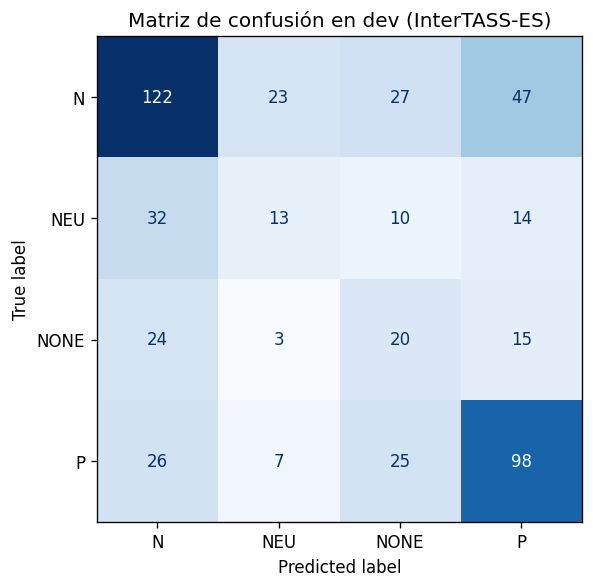

In [26]:
X_dev = dev_df[COL_TEXT].astype(str).to_numpy()
y_dev = dev_df[COL_LABEL].astype(str).to_numpy()
y_pred = chosen.predict(X_dev)  # chosen fue ajustado exclusivamente con train
metrics = {'accuracy': accuracy_score(y_dev, y_pred),
           'precision_macro': precision_score(y_dev, y_pred, average='macro', labels=LABELS, zero_division=0),
           'recall_macro': recall_score(y_dev, y_pred, average='macro', labels=LABELS, zero_division=0),
           'f1_macro': f1_score(y_dev, y_pred, average='macro', labels=LABELS, zero_division=0)}
print('Representación y familia:', winner_rep, winner_family)
print('Métricas en dev (uso único):', {k: round(v, 4) for k, v in metrics.items()})
print('Referencia histórica Word2Vec dev: 0.3022; BoW taller dev: 0.3506')
print('Diferencia descriptiva frente a Word2Vec:', round(metrics['f1_macro'] - 0.3022, 4))

rng = np.random.default_rng(SEED)
boot = []
for _ in range(2000):
    idx = rng.integers(0, len(y_dev), size=len(y_dev))
    boot.append(f1_score(y_dev[idx], y_pred[idx], average='macro', labels=LABELS, zero_division=0))
print('IC percentil 95 % F1 macro, remuestreo de tuits:', np.quantile(boot, [0.025, 0.975]).round(4))
print(classification_report(y_dev, y_pred, labels=LABELS, zero_division=0))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_dev, y_pred, labels=LABELS, ax=ax,
                                       cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión en dev (InterTASS-ES)')
plt.tight_layout(); plt.show()

### Diez errores reales, agrupados por tipo

La agrupación utiliza la combinación real→predicha y una marca superficial de negación/emojis para facilitar revisión cualitativa; **no atribuye automáticamente una causa**. Leer los diez textos completos y comentar si la diferencia se asocia con ironía, polisemia, falta de contexto, negación, registro o límites del léxico. Los grupos `NEU` y `NONE` deben examinarse por separado. Las capturas del dev se usan únicamente aquí, después de la selección.

In [28]:
errors = pd.DataFrame({'tweetid': dev_df['tweetid'].to_numpy() if 'tweetid' in dev_df else np.arange(len(dev_df)),
                       'texto': X_dev, 'real': y_dev, 'predicho': y_pred})
errors = errors.loc[errors.real != errors.predicho].copy()
errors['tipo'] = errors.real + ' → ' + errors.predicho
errors['marca_negacion'] = errors.texto.str.contains(r'\b(?:no|nunca|jamás|sin)\b', case=False, regex=True)
errors['marca_emoji'] = errors.texto.map(lambda t: bool(EMOJI_RE.search(t)))
counts = errors.groupby('tipo').size().sort_values(ascending=False)
display(counts.to_frame('errores'))
selected = []
for _, group in errors.groupby('tipo', sort=False):
    selected.extend(group.head(2).index.tolist())
selected = selected[:10]
if len(selected) < 10:
    selected += [i for i in errors.index if i not in selected][:10 - len(selected)]
error_interpretation = {
    '770976639173951488': 'El elogio hiperbólico 1000/10 y el afecto dirigido a otra persona quedan diluidos.',
    '770725676798410752': 'La preferencia por la tónica se expresa sin adjetivo positivo directo.',
    '771092421866389508': 'No las he leído es negación literal, pero Caerán prontito comunica interés.',
    '770470969085464578': 'La valoración positiva está en enamora y en el contexto cotidiano.',
    '771094192508600320': 'Se sepan a kk es crítica coloquial con ortografía no estándar.',
    '770254726134960129': 'La pregunta retórica y oxímoron expresan crítica política implícita.',
    '771116956518875137': 'El afecto por la mascota requiere interpretar toda la anécdota.',
    '770549862500802560': 'Uno de mis cuadros favoritos expresa preferencia pese al contexto cultural.',
    '771115324884262912': 'La risa y tampoco aparecen en una explicación etiquetada neutral.',
    '769979388825927680': 'No te he visto es negación factual en una pregunta, sin juicio negativo.',
}
selected_errors = errors.loc[selected, ['tweetid','texto','real','predicho','tipo','marca_negacion','marca_emoji']].copy()
selected_errors['hipótesis_del_error'] = (
    selected_errors['tweetid'].astype(str).map(error_interpretation)
    .fillna('Revisar el contexto que motivó la predicción.')
)
with pd.option_context('display.max_colwidth', None, 'display.max_columns', None,
                       'display.width', 220):
    display(selected_errors)

print('Total errores:', len(errors), 'de', len(y_dev))

Total errores: 253 de 506


,errores
tipo,
N → P,47
NEU → N,32
N → NONE,27
P → N,26
P → NONE,25
NONE → N,24
N → NEU,23
NONE → P,15
NEU → P,14


,tweetid,texto,real,predicho,tipo,marca_negacion,marca_emoji,hipótesis_del_error
0,770976639173951488,@noseashetero 1000/10 de verdad a ti que voy a decir petarda que te quiero más que a mí mismo ✨,P,NEU,P → NEU,False,True,El elogio hiperbólico 1000/10 y el afecto dirigido a otra persona quedan diluidos.
135,770725676798410752,@ricki33_ me quedo con la tónic ya sabes que soy un clásico,P,NEU,P → NEU,False,False,La preferencia por la tónica se expresa sin adjetivo positivo directo.
1,771092421866389508,@piscolabisaereo @HistoriaNG @SPosteguillo las tengo pero aún no las he leído. Caerán prontito,P,N,P → N,True,False,"No las he leído es negación literal, pero Caerán prontito comunica interés."
17,770470969085464578,Cosas que enamora las tostadas calentitas a estas horas de la mañana,P,N,P → N,False,False,La valoración positiva está en enamora y en el contexto cotidiano.
4,771094192508600320,@_MissChaotic_ ves ese brillo? es un coso que hace que se sepan a kk,N,NONE,N → NONE,False,False,Se sepan a kk es crítica coloquial con ortografía no estándar.
75,770254726134960129,@KikeMlaga @sanchezcastejon ¿Socialistas honrados? Esto es un oxímoron.,N,NONE,N → NONE,False,False,La pregunta retórica y oxímoron expresan crítica política implícita.
5,771116956518875137,Tengo una perrina adorable... Sabéis que me acompaña hasta la a habitación cuando me voy a dormir?,P,NONE,P → NONE,False,False,El afecto por la mascota requiere interpretar toda la anécdota.
9,770549862500802560,"@agcasti y el caminante ante el mar de niebla, uno de mis cuadros favoritos en portada",P,NONE,P → NONE,False,False,Uno de mis cuadros favoritos expresa preferencia pese al contexto cultural.
6,771115324884262912,"@juankipua Es que en el Ojeando el año pasado tampoco, tiene muchas canciones ya jajajajaja",NEU,N,NEU → N,False,False,La risa y tampoco aparecen en una explicación etiquetada neutral.
21,769979388825927680,@CarlosSadness en ninguna porque no te he visto en directo concierto en madrid pronto pls,NEU,N,NEU → N,True,False,"No te he visto es negación factual en una pregunta, sin juicio negativo."


## Resultados, discusión y límites

**Selección en entrenamiento.** Con cinco folds estratificados, TF-IDF obtuvo F1 macro 0,4058; los 43 rasgos léxicos solos, 0,3820; TF-IDF + rasgos, 0,4285; Word2Vec Skip-gram + rasgos, 0,4373. TF-IDF genera 2.502 dimensiones cuando se ajusta sobre todo entrenamiento; la unión TF-IDF + léxica genera 2.545 y Word2Vec + léxica 193. Los rasgos captan emojis, negación y expresividad; el texto vectorizado aporta vocabulario y contexto.

Se compararon regresión logística multiclase, SVM lineal y Naive Bayes multinomial. El ganador por F1 macro fue **SVM lineal + Word2Vec + léxica, C = 0,1**, con media 0,4428 y desviación entre folds 0,0406. La regresión logística con la misma unión obtuvo 0,4423: la diferencia de 0,0005 no acredita superioridad estable. Naive Bayes se evaluó solo con TF-IDF + rasgos no negativos, compatible con su supuesto de entrada, y no con vectores Word2Vec firmados. No hubo sobremuestreo; las ponderaciones de clases se ajustaron dentro de cada fold.

**Ablación.** La unión completa obtuvo 0,4428 frente a 0,3998 de Word2Vec sin rasgos y 0,4228 con los rasgos históricos. Quitar lex_pol_neg redujo el resultado 0,0089 y quitar question_run_max, 0,0060; quitar exclamation_run_max elevó el resultado 0,0044. La mayoría de las diferencias individuales son pequeñas y exploratorias. Peso léxico 0,5 produjo 0,4357. La ablación usó solo entrenamiento y no cambió la selección previa al conjunto reservado.

**Evaluación única en 506 tuits reservados.** Exactitud 0,5000, precisión macro 0,4219, recall macro 0,4241 y **F1 macro 0,4187**, con intervalo bootstrap percentil aproximado del 95 % [0,3729, 0,4621]. La referencia histórica Word2Vec fue 0,3022: diferencia descriptiva de **+0,1165** (11,65 puntos porcentuales). Cambiaron el protocolo y las características, por lo que no es válido atribuir todo ese aumento a los rasgos nuevos. El BoW archivado obtuvo 0,3506. No se probó otra variante en este conjunto para elegir el modelo.

El F1 de N es 0,58; NEU, 0,23; NONE, 0,28; P, 0,59. Hubo 253 errores de 506. Los tipos más frecuentes fueron N→P (47), NEU→N (32), N→NONE (27) y P→N (26). La tabla anterior incluye diez tuits completos y una hipótesis específica para cada error; destacan negaciones factuales, afecto implícito, grafías informales y preguntas retóricas. Estas hipótesis no demuestran la causa interna de la predicción.

**Comparabilidad y límites.** El CSV de 506 coincide en tamaño con el desarrollo ES descrito en el material del taller; no se certificó su identidad frente a una copia oficial independiente. La prueba oficial publicada tiene otro conjunto, así que no se comparan directamente puntuaciones del ranking. Corpus pequeño y desbalanceado, ironía, variación dialectal y vocabulario infrecuente limitan la generalización. El bootstrap supone observaciones intercambiables y no contempla la incertidumbre de seleccionar el modelo; la desviación entre folds mide sensibilidad a las particiones.

**Reproducibilidad.** Los CSV reales no están incrustados: colocarlos en la ruta configurable DATA_DIR, con 1.008 tuits de entrenamiento y 506 reservados. Semilla 42, cinco folds estratificados, Word2Vec con un trabajador y transformaciones ajustadas dentro de cada fold. La inferencia final usa el mismo pipeline de preprocesamiento. El corpus se obtiene del docente y no debe publicarse en el repositorio. Referencia: [Martínez-Cámara et al. (2018), TASS 2018 overview](https://ceur-ws.org/Vol-2172/p0_overview_tass2018.pdf).
